#Análisis de series financieras: Evaluación de riesgo por medio de la métrica Value at Risk (VaR).

Análisis de series temporales financieras orientado a la modelación y pronóstico de volatilidad condicional, evaluación fuera de muestra y medición dinámica del riesgo mediante Value at Risk (VaR).

Flujo metodológico:

Análisis descriptivo → Rendimientos → Drawdown → Análisis de volatilidad → Correlación de activos → Beta → Autocorrelación → ARIMA → GARCH → Volatilidad condicional → Pronósticos de volatilidad → VaR


Datasets utilizados:
- stocks_data.csv
- sp_data.csv

In [4]:
#Importar liberías necesarias
import pandas as pd #Manipulación y análisis
import numpy as np #Cálculos matemáticos
import matplotlib.pyplot as plt #Gráficos
import seaborn as sns #Gráficos
import math #Operaciones matemáticas
from statsmodels.tsa.stattools import adfuller, kpss #Pruebas de estacionariedad
from statsmodels.tsa.stattools import acf, pacf #Funciones de autocorrelación
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #Gráficos ACF/PACF
import warnings
warnings.filterwarnings('ignore') #Ocultar advertencias de interpolación de KPSS
from statsmodels.tsa.arima.model import ARIMA #Modelo ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox #Prueba de Ljung-Box
from statsmodels.stats.diagnostic import het_arch #Prueba ARCH-LM (Engle)
!pip install arch #Instalación de librería ARCH
from arch import arch_model #Modelo ARCH
from sklearn.metrics import mean_absolute_error, mean_squared_error #Métricas de error y error cuadrático
from scipy.stats import norm #Parámetro de distribución normal
from scipy.stats import chi2 #Variable aleatoria continua de la distribución Chi-cuadrado (χ²)

##Exploración inicial

In [5]:
#Importar dataset
df = pd.read_csv('stocks_data.csv')

df.head()

,Fecha,coin,goog,ppta,soxx,ual
0,2021-04-15,322.75,114.83,6.96,147.92,56.12
1,2021-04-16,342.00,114.89,6.96,147.23,55.87
2,2021-04-19,333.00,115.12,7.12,143.36,54.99
3,2021-04-20,320.82,114.68,7.00,141.31,50.30
4,2021-04-21,311.92,114.66,7.21,145.02,51.86


In [6]:
#Inspección y validación
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fecha   1365 non-null   object 
 1   coin    1365 non-null   float64
 2   goog    1365 non-null   float64
 3   ppta    1365 non-null   float64
 4   soxx    1365 non-null   float64
 5   ual     1365 non-null   float64
dtypes: float64(5), object(1)
memory usage: 64.1+ KB


In [7]:
#Corrección de tipo de dato en la columna Fecha
df['Fecha'] = pd.to_datetime(df['Fecha'])

#Establecer la columna fecha cómo índice de las filas
df = df.sort_values('Fecha')
df = df.set_index('Fecha')

In [8]:
#Conteo de duplicados
df.index.duplicated().sum()

np.int64(0)

**Notas:**
- El conteo de filas es consistente entre columnas.
- No existe presencia de datos nulos en el dataset.
- Se hizo el conteo de duplicados en base al índice del dataset y no se encontraron registros duplicados.

##Descripción de datos

Columnas del dataframe:
- `Fecha`: Fecha de cada sesión de mercado entre el 15/04/2021 y el 21/09/2026 (se ha definido como índice del dataset).
- `coin`: Precio al cierre de cada sesión de las acciones de Coinbase Inc., plataforma de comercio de criptomonedas.
- `goog`: Precio al cierre de cada sesión de las acciones Clase C de Alphabet Inc., empresa matriz del búscador de internet Google.
- `ppta`: Precio al cierre de cada sesión de las acciones de Perpetua Resources Corp., empresa de minería enfocada en la extracción de oro y antimonio (minerales cruciales para la producción de semiconductores).
- `soxx`: Precio al cierre de cada sesión de las acciones del iShares Semiconductor ETF, un ETF de BlackRock indexado al Philadelfia Semiconductors Index.
- `ual`: Precio al cierre de cada sesión de las acciones de United Airlines Holdings, Inc., aerolínea estadounidense.

##Análisis descriptivo de los activos

En esta sección se pretenden detectar las principales características estadísticas de las series financieras de activos con la finalidad de visualizar comportamientos y tendencias que ayuden a conocer más a detalle las acciones que se incluyen en el desarrollo de este proyecto.

###Estadísticas descriptivas

In [9]:
#Estadísticas descriptivas
df.describe()

,coin,goog,ppta,soxx,ual
count,1365.000000,1365.000000,1365.000000,1365.000000,1365.000000
mean,183.706857,175.138022,9.844021,219.280381,64.063941
std,90.893080,77.304328,8.621451,110.029706,26.989682
min,32.530000,83.490000,1.700000,99.560000,31.200000
25%,84.000000,124.350000,3.560000,146.600000,43.540000
50%,190.200000,145.410000,5.460000,183.030000,50.500000
75%,250.380000,187.300000,13.070000,238.700000,90.780000
max,419.780000,399.040000,37.220000,655.010000,136.110000


En primera instancia se pueden vislumbrar ciertas medidas de las series financieras presentadas en niveles que permiten analizar ciertos comportamientos en las distribuciones de cotizaciones.

Algo que se aprecia es que activos la mayoría de los activos presentan diferencias importantes entre su promedio y su mediana, lo cual es señal de sesgo en las distribuciones. En el caso de GOOG, PPTA, SOXX y UAL se muestra un sesgo a la derecha.Esto quiere decir que los valores extremos altos jalan o desplazan la media aritmética hacia la derecha, lo cual es señal de colas largas hacia la derecha.

En el caso de COIN se muestra una diferencia mucho menor (equivalente a cerca del 3% de la mediana) y en este caso sesgado hacia la izquierda, lo cual significa que el activo se ha visto ligeramente jalado por valores más bajos.

Este tipo de comportamientos puede ser consistente con el rendimiento histórico del periódo o la tendencia del precio del activo, cosa que se analizará en la siguiente sección.

Además, se logra apreciar que el valor de la desviación estándar entre series es muy distinta entre sí, pero aún no sirve de comparativa para calificar a un activo como más volátil que otro. Es por ello que posteriormente se transformarán los valores a escala logarítmica para estabilizar la varianza.

###Comportamiento de precios

Para esta sección se realizará un análisis de comportamiento de precios que aportará a detectar tendencias y comportamientos específicos a lo largo del periódo analizado.

Text(0.5, 0, 'Fecha')

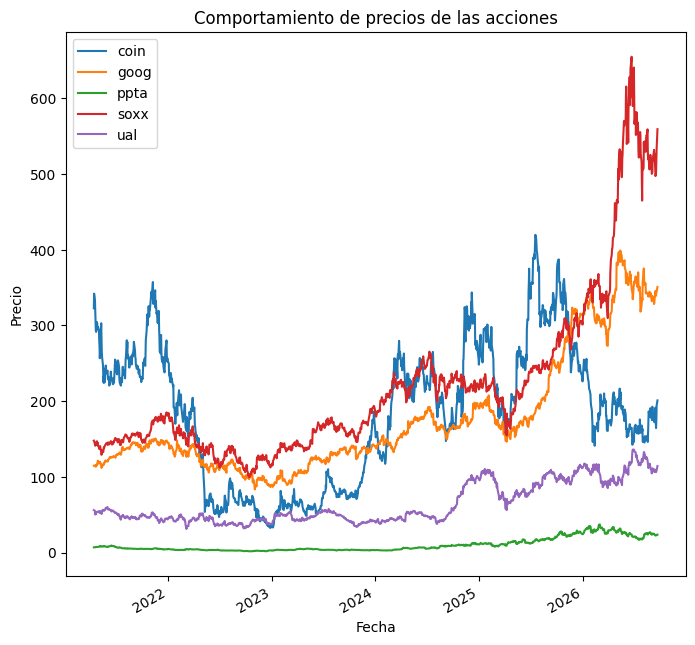

In [10]:
#Visualización de datos en niveles
df.plot(figsize=(8,8))

plt.title('Comportamiento de precios de las acciones')
plt.ylabel('Precio')
plt.xlabel('Fecha')

###Comportamiento en escala logarítmica

Debido a que las cotizaciones de cada activo son bastante distintas entre si en cuanto al valor absoluto (más no real o relativo) de las acciones, la escala logarítmica funciona para ajustar la escala a valores más fáciles de comparar a pesar de las diferencias en niveles.

Además, la escala logarítmica se aplica en los modelos ARIMA Y GARCH como una transformación previa de los datos con el objetivo principal de estabilizar la varianza de la serie temporal.

Text(0.5, 0, 'Fecha')

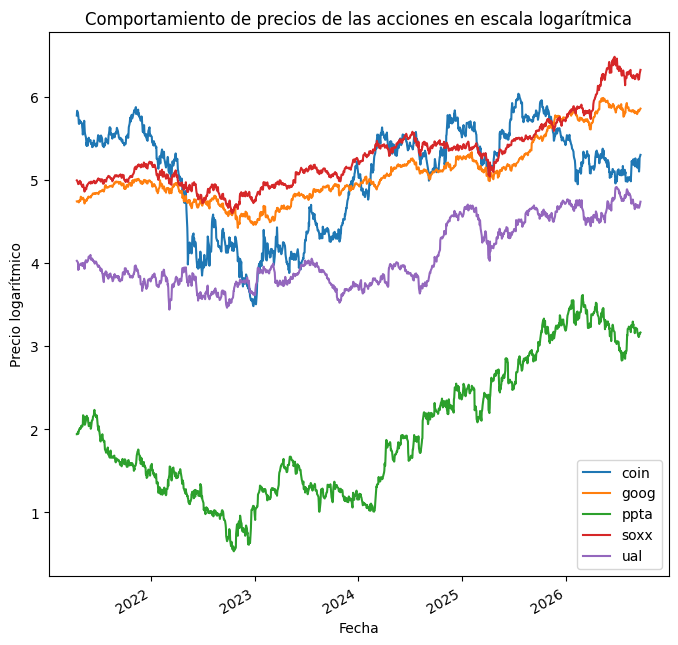

In [11]:
#Visualización de datos en escala logarítmica
df_log = np.log(df)
df_log.plot(figsize=(8,8))

plt.title('Comportamiento de precios de las acciones en escala logarítmica')
plt.ylabel('Precio logarítmico')
plt.xlabel('Fecha')

Este gráfico es más útil que el anterior, ya que ahora es posible analizar el comportamiento de los activos a lo largo del periódo de una manera más igualitaria.

De manera general se observa un comportamiento no lineal en cada una de las series, teniendo múltiples periódos alcistas y bajistas (algunos coincidiendo entre acciones a pesar de la diferencia de sectores).

En cuanto a las tendencias de cada uno, cuatro de los cinco activos presentarpon una tendencia alciista bastante marcada, gracias a la constante formación de nuevos altos locales a pesar de los ciclos de caída.

En el caso de COIN se nota tendencia menos fuerte, ya que después de alcanzar un alto local importante a finales de 2021, no fue hasta mediados de 2025 que logró superarlo (y por muy poco) para generar un nuevo alto histórico que no ha vuelto a visitar desde entonces.

Este tipo de tendencias es más fácil de verlas al totalizar los rendimientos, cosa que se hará en la siguiente sección.

##Rendimientos

Un factor muy importante al analizar activos para incluir y gestionar dentro de una cartera es el rendimiento. Se trata de la ganancia o pérdida porcentual que genera un activo o inversión en un periodo de tiempo.

Debido a que el objetivo del proyecto es generar estimaciones de VaR para gestión de riesgo, los rendimientos serán la métrica que conformará la serie de tiempo utilizada para modelar por ARIMA. En este caso se optará por el uso de rendimientos logratítmicos, debido a que se pueden sumar de manera directa a lo largo del tiempo, lo que simplifica los cálculos en series temporales y la varianza.

Fórmula:

$$r_{t}=ln(P_{t}/P_{t-1})$$

- $r_{t}$: Rendimiento logarítmico en el periodo
- $ln$: Logaritmo natural.
- $P_{t}$: Precio o valor del activo en el periodo actual.
- $P_{t-1}$: Precio o valor del activo en el periodo anterior.

In [12]:
#Cálculo de rendimientos logarítmicos diarios
def calculate_l_returns(df):
  return np.log(df / df.shift(1))

In [13]:
#Historial de rendimientos diarios
retornos_l = calculate_l_returns(df)
retornos_l = retornos_l.dropna()

print(retornos_l)

                coin      goog      ppta      soxx       ual
Fecha                                                       
2021-04-16  0.057933  0.000522  0.000000 -0.004676 -0.004465
2021-04-19 -0.026668  0.002000  0.022728 -0.026637 -0.015876
2021-04-20 -0.037262 -0.003829 -0.016998 -0.014403 -0.089146
2021-04-21 -0.028133 -0.000174  0.029559  0.025916  0.030543
2021-04-22 -0.061039 -0.011050  0.001386 -0.022031 -0.016134
...              ...       ...       ...       ...       ...
2026-09-15 -0.106493 -0.012458  0.006189  0.002911 -0.018900
2026-09-16 -0.045162 -0.006081 -0.007965  0.006414 -0.005816
2026-09-17  0.055912  0.012650  0.037493  0.033377  0.012527
2026-09-18  0.110263  0.002122 -0.005578  0.026556  0.009891
2026-09-21  0.034408  0.018583  0.018756  0.048105  0.050930

[1364 rows x 5 columns]


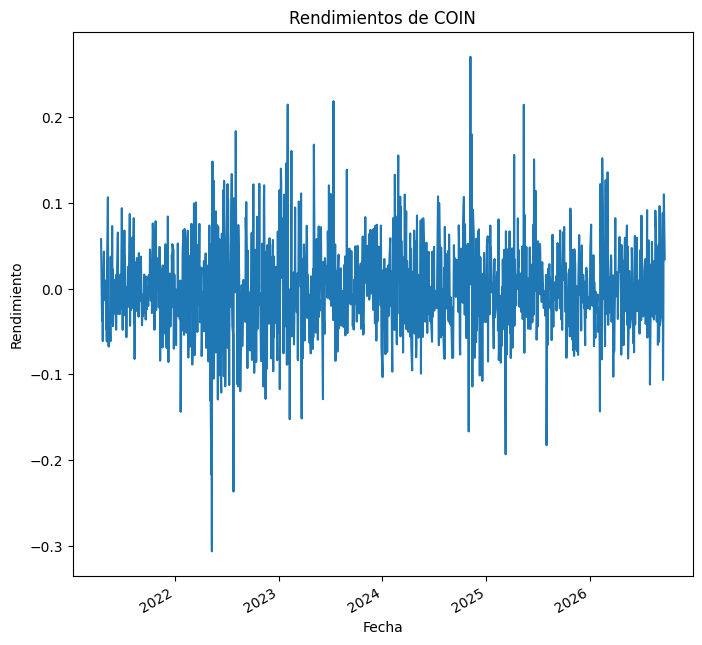

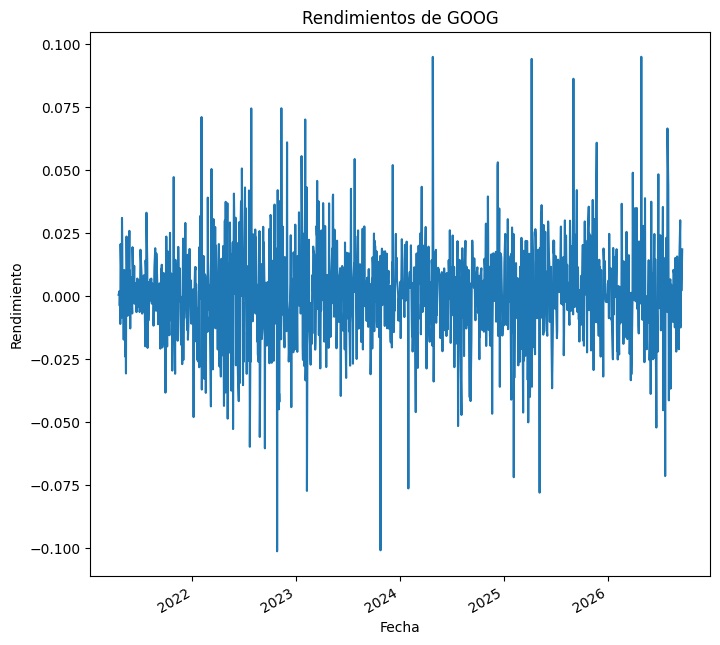

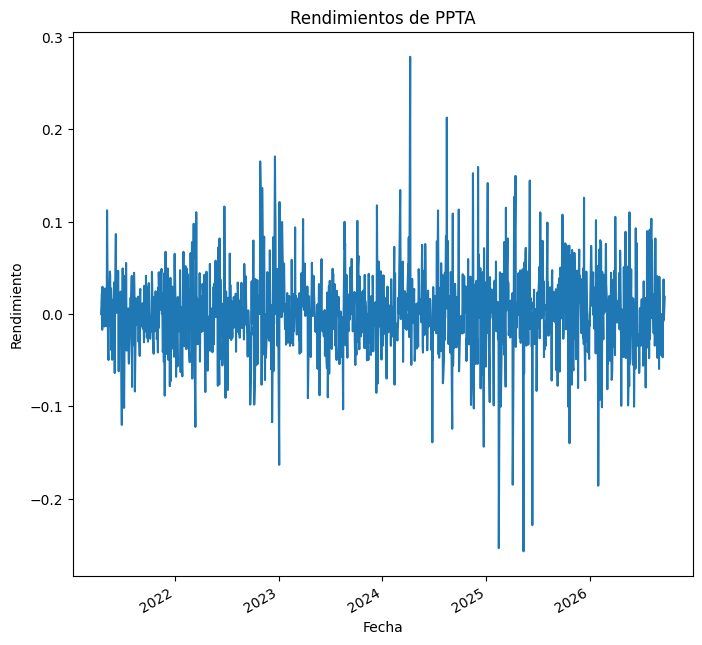

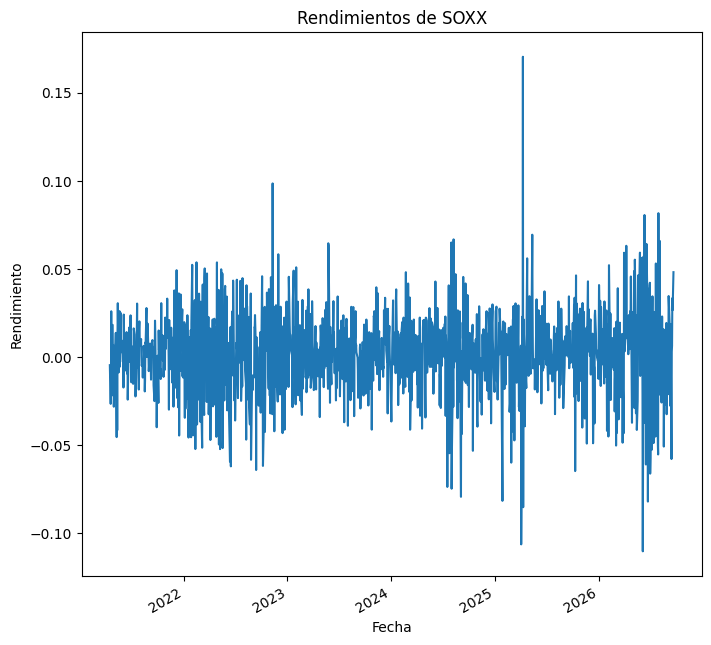

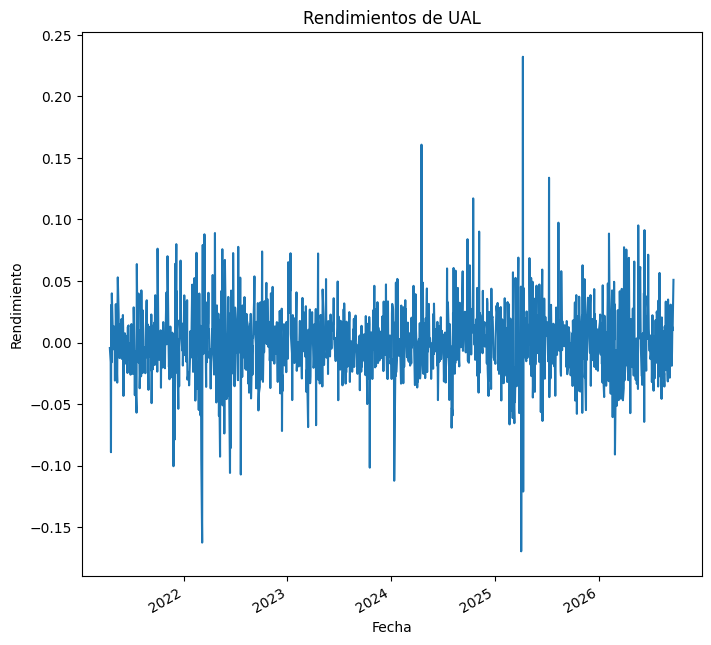

In [14]:
#Visualización de rendimientos logarítmicos
stocks = ['coin','goog','ppta','soxx','ual']

for ticker in stocks:
  retornos_l[ticker].plot(figsize=(8,8))
  plt.title(f'Rendimientos de {ticker.upper()}')
  plt.ylabel('Rendimiento')
  plt.xlabel('Fecha')
  plt.show()

Se ha decidido trabajar con rendimientos logarítmicos debido a que la naturaleza de este análisis es comparar los resultados de rendimientos y volatilidad entre activos. Además posteriormente los modelos y análisis correspondientes requieren que la serie de rendimientos se encuentre en escala logarítmica.

Los gráficos de los cinco activos no muestran una tendencia evidente, pero si periodos donde los rendimientos se concentran alrededor de cero y otros donde aparecen movimientos mucho más grandes.

Eso se conoce como volatility clustering y es uno de los fenómenos que posteriormente se analizará por medio de un modelo GARCH.

In [15]:
#Estadísticos descriptivos de los rendimientos
retornos_l.describe()

,coin,goog,ppta,soxx,ual
count,1364.000000,1364.000000,1364.000000,1364.000000,1364.000000
mean,-0.000347,0.000819,0.000898,0.000975,0.000522
std,0.053122,0.019571,0.044598,0.023723,0.030140
min,-0.306537,-0.101313,-0.256977,-0.110310,-0.169707
25%,-0.031053,-0.009721,-0.022741,-0.011561,-0.015908
50%,-0.003335,0.001240,0.000000,0.001666,0.000000
75%,0.029491,0.011243,0.024098,0.015050,0.016197
max,0.270902,0.095046,0.278713,0.170347,0.232256


Los rendimientos presentan una desviación estándar diaria cercana al rango del 2% para arriba.

Se presentan valores mínimos y máximos extremos, especialmente COIN, PPTA y UAL; lo que apunta a un comportamiento no uniforme y con shocks importantes propio de variables estacionarias.

Posteriormente se realizarán las respectivas pruebas de estacionariedad para confirmar.

###Retorno acumulado

El retorno acumulado es la ganancia o pérdida total que genera una inversión durante un periodo de tiempo determinado, expresada como un porcentaje del capital inicial. En el caso de este proyecto, al ya contar con los rendimiento diarios en escala logarítmica, este se puede calcular por medio de la suma de dichos valores.

In [16]:
#Retorno acumulado del periodo
retornos_l.sum()

,0
coin,-0.473324
goog,1.116963
ppta,1.224451
soxx,1.330086
ual,0.712121


Se logra apreciar que cuatro de las cinco acciones presentaron un rendimiento acumulado positivo a lo largo del periodo analizado de aproximadamente 5 años.

En el caso de `goog`, `ppta` y `soxx` vemos un rendimiento acumulado mayor al 100%, lo que significa que en el caso hipotético de haber invertido en su acción el 15 de abril de 2021, se habría más que duplicado el monto inicial de la inversión al día 21 de septiembre de 2026.

###Retorno anualizado

En el caso del retorno anualizado, es la tasa de ganancia o pérdida promedio que genera una inversión cada año durante un período determinado, considerando el efecto del interés compuesto.

A diferencia de la rentabilidad acumulada total, esta medida muestra cuánto habría crecido el dinero de forma constante cada año.

Para su cálculo basta con multiplicar el valor del rendimiento promedio del periódo por el número de sesiones de operación del mercado. En este y en fases posteriores será de 252 días.

In [18]:
#Rendimiento promedio anualizado
annualized_return = retornos_l.mean() * 252
annualized_return

,0
coin,-0.087447
goog,0.206360
ppta,0.226218
soxx,0.245734
ual,0.131565


De las cinco acciones seleccionadas, solo Coinbase se ha quedado por atrás del promedio del S&P500 durante los últimos 10 años (12.77%), mientras que el resto de empresas lograron superarlo con su promedio anualizado.

###Distribución de los rendimientos

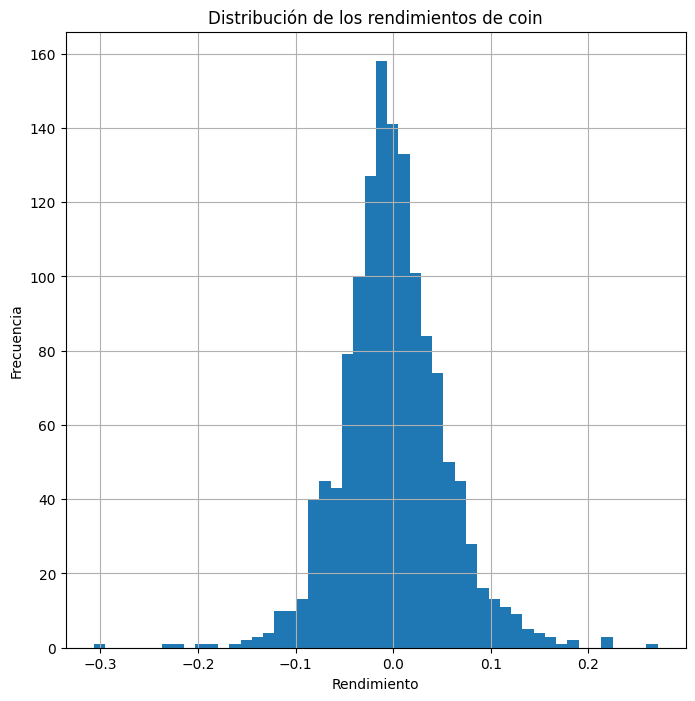

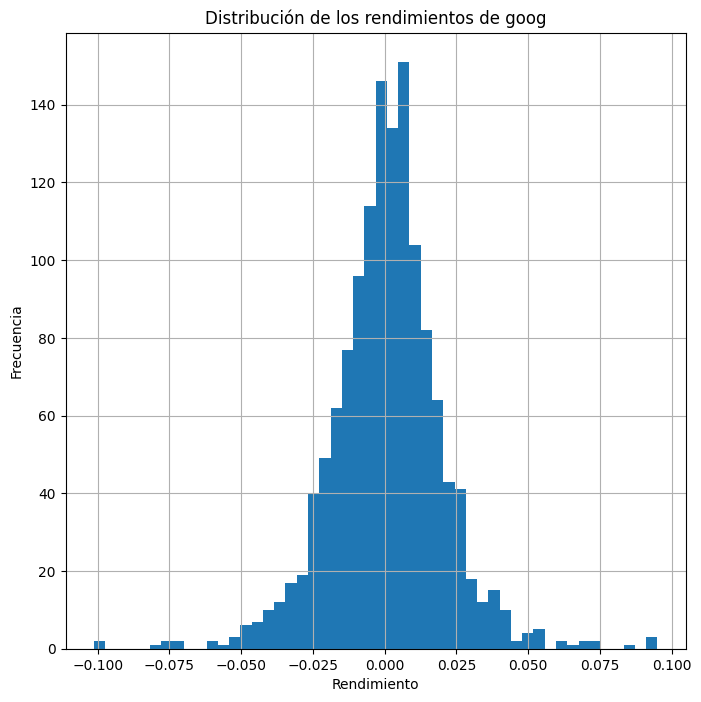

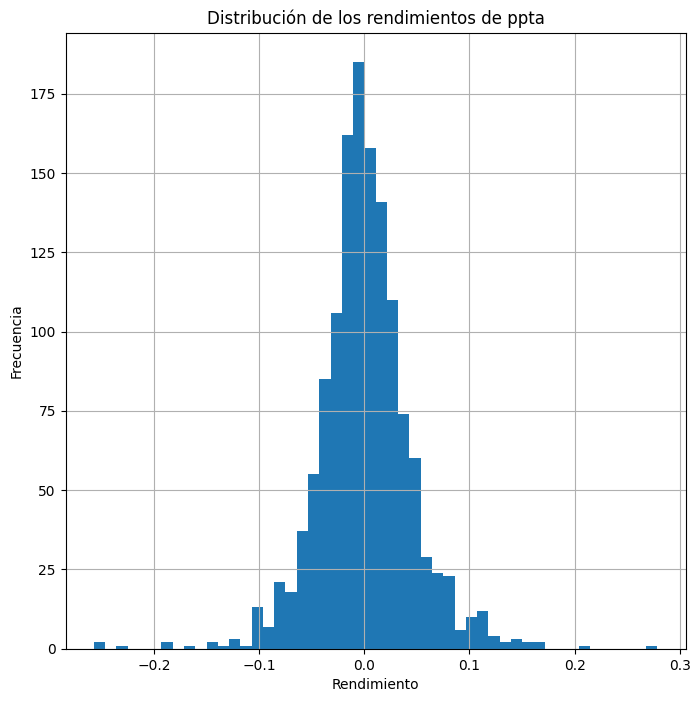

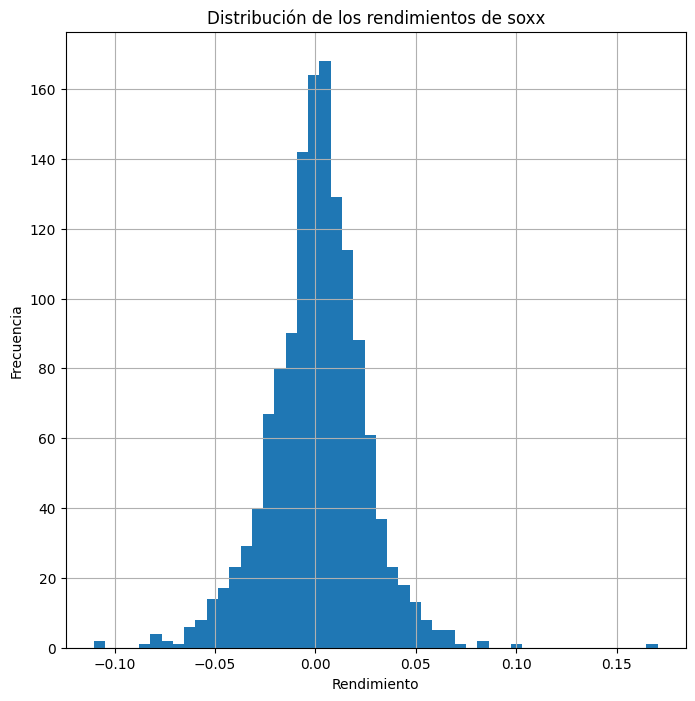

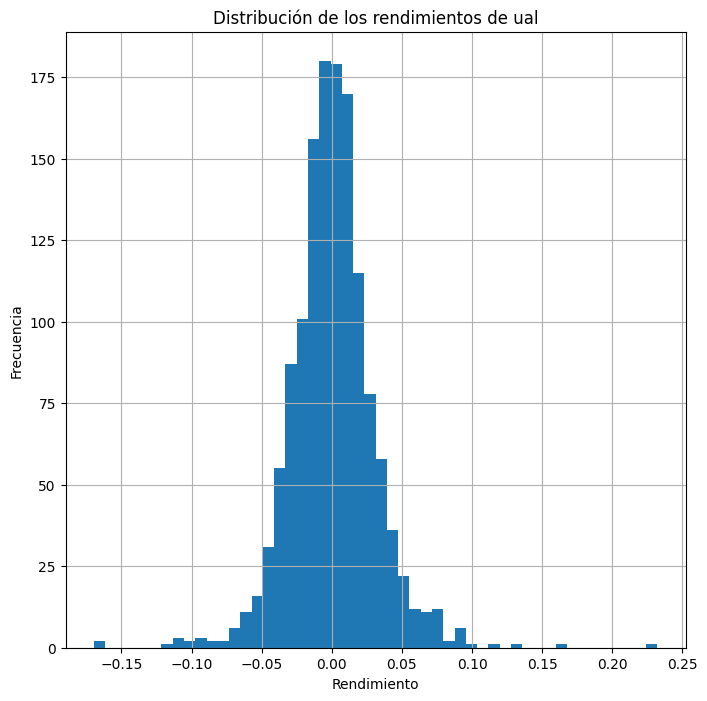

In [19]:
#Distribución de los rendimientos
for ticker in stocks:
  retornos_l[ticker].hist(bins=50,figsize=(8,8))

  plt.title(f'Distribución de los rendimientos de {ticker}')
  plt.ylabel('Frecuencia')
  plt.xlabel('Rendimiento')
  plt.show()

En los histogramas de distribución se aprecia un comportamiento no normal, ya que destacan características como colas pesadas y sesgos hacia la derecha. Esto se corrobora por medio de pruebas de Skewness y Kurtosis.

In [20]:
#Skewness
retornos_l.skew()

,0
coin,0.142461
goog,-0.011986
ppta,0.008360
soxx,-0.023441
ual,0.261780


Según la prueba de Skewness, se aprecia que la distribución de los rendimientos de las acciones de Google, Perpetua Resources y el ETF iShares Semiconductors se acercan más a un forma simétrica, mientras que en el caso de Coinbase y United Airlines se muestra un sesgo hacia la derecha.

In [21]:
#Kurtosis
retornos_l.kurt()

,0
coin,2.458774
goog,3.354783
ppta,4.427058
soxx,3.146219
ual,5.336986


Se observan colas pesadas en la distribución de los rendimientos en los cinco activos según la prueba de exceso de curtósis, lo que se aleja de una distribución normal.

En resumen, las series de tiempo financieras no tienen una distribución normal en la realidad, aunque muchos modelos clásicos asuman lo contrario por conveniencia matemática.

 Los periodos de alta volatilidad tienden a agruparse (un día de gran movimiento suele ir seguido de otro día turbulento), lo que rompe el supuesto de independencia de los datos. Aunque para el caso de estudio actual, el que se rompa el supuesto de independencia da lugar a que modelos que captan la autocorrelación (como ARIMA y GARCH) tengan utilidad en la captura de comportamientos y pronóstico de variables condicionales.

##Drawdown

El drawdown es la caída porcentual o absoluta que sufre una inversión desde su punto máximo (peak) hasta su punto más bajo (trough) antes de volver a recuperarse.

Esta métrica no es definitiva, pero aporta una capa más de análisis a la evaluación de riesgo de una activo.

###Precios máximos y mínimos

In [22]:
#Mínimos y máximos de cotizaciones
max_price = {}
fecha_max = {}
min_price = {}
fecha_min = {}

#Cálculo de valores
for ticker in stocks:
  max_price[ticker] = df[ticker].max()
  fecha_max[ticker] = df[df[ticker] == df[ticker].max()].index.values[0]
  min_price[ticker] = df[ticker].min()
  fecha_min[ticker] = df[df[ticker] == df[ticker].min()].index.values[0]

max_price = pd.Series(max_price)
max_price.name = 'Precio máximo'
fecha_max = pd.Series(fecha_max)
fecha_max.name = 'Fecha de máximo'
min_price = pd.Series(min_price)
min_price.name = 'Precio mínimo'
fecha_min = pd.Series(fecha_min)
fecha_min.name = 'Fecha de mínimo'

#Tabla completa
summary = pd.concat([max_price, fecha_max, min_price, fecha_min], axis=1)
summary

,Precio máximo,Fecha de máximo,Precio mínimo,Fecha de mínimo
coin,419.78,2025-07-18,32.53,2022-12-28
goog,399.04,2026-05-13,83.49,2022-11-03
ppta,37.22,2026-03-02,1.70,2022-10-20
soxx,655.01,2026-06-22,99.56,2022-10-14
ual,136.11,2026-06-26,31.20,2022-03-07


###Drawdown máximo

In [23]:
#Drawdown máximo
drawdown = {}

for ticker in stocks:
  drawdown[ticker] = ((df[ticker] - df[ticker].cummax())/df[ticker].cummax()).min()

max_drawdown = pd.Series(drawdown)
max_drawdown.name = 'Drawdown máximo'

#Fecha de drawdown máximo
drawdown_time = {}

for ticker in stocks:
  daily_drawdown_series = (df[ticker] - df[ticker].cummax()) / df[ticker].cummax()
  drawdown_trough_date = daily_drawdown_series.idxmin()
  drawdown_time[ticker] = drawdown_trough_date

drawdown_trough_dates_series = pd.Series(drawdown_time)
drawdown_trough_dates_series.name = 'Fecha de drawdown máximo'

#Tabla completa
drawdown_table = pd.concat([max_drawdown, drawdown_trough_dates_series], axis=1)
drawdown_table

,Drawdown máximo,Fecha de drawdown máximo
coin,-0.908979,2022-12-28
goog,-0.446022,2022-11-03
ppta,-0.817792,2022-10-20
soxx,-0.462448,2022-10-14
ual,-0.491947,2025-04-08


En los cinco activos se muestra un drawdown máximo bastante alto, ya que el en el caso de Google que tiene el valor más bajo más bajo, requeriría aproximadamente un 80% de crecimiento para recuperarse de una caída de la magnitud mostrada. Esto indica una volatilidad alta, y por ende los descarta como activos para conformar una cartera con riesgo conservador.

##Análisis de volatilidad

La volatilidad es una medida estadística que describe la frecuencia y la intensidad con la que cambian los precios de un activo financiero en un periodo determinado.

Un nivel alto de volatilidad significa cambios bruscos y mayor incertidumbre, lo que eleva el riesgo de la inversión. Un nivel bajo refleja movimientos estables y graduales.

Además, esta métrica es el tema central del proyecto, por lo que este análisis preliminar servirá para visualizar comportamientos generales y obtener un proxy de referencia para comparar las estimaciones posteriores.


###Volatilidad histórica diaria

La volatilidad histórica es una medida estadística que indica cuánto ha variado el precio de un activo financiero a lo largo de un periodo de tiempo pasado (en este caso el periódo entre el 15/04/2021 y el 21/09/2026).

En este caso, se presenta la volatilidad de los rendimientos logarítmicos diarios calculada por desviación estándar.

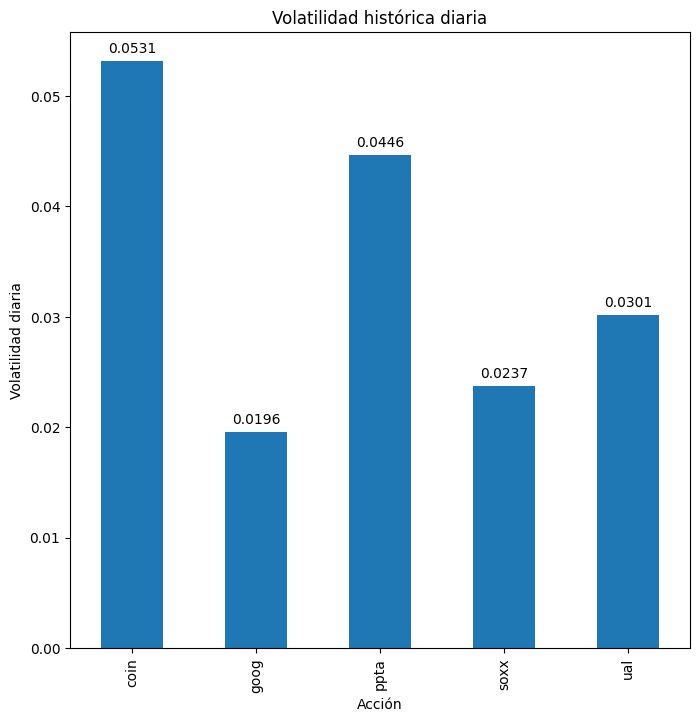

In [24]:
#Desviación estándar de los rendimientos
volatilidad_diaria = retornos_l.std()
fig, ax = plt.subplots(figsize=(8,8))
barras = volatilidad_diaria.plot(kind='bar', ax=ax)

for barra in barras.patches:
    yval = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2, # Posición X (centrada)
        yval + 0.0005,                            # Posición Y (luego de la barra)
        f'{yval:.4f}',                             # Texto del valor, formateado a 4 decimales
        ha='center',                           # Alineación horizontal
        va='bottom'
    )

plt.title('Volatilidad histórica diaria')
plt.ylabel('Volatilidad diaria')
plt.xlabel('Acción')
plt.show()

Al comparar la volatilidad entre activos se logra observar que:

- GOOG tiene la menor desviación estándar: 1.96%.
- SOXX: 2.37%.
- UAL: 3.01%.
- PPTA: 4.46%.
- COIN: 5.31%, claramente el activo más volátil de los cinco.

###Volatilidad histórica anualizada

La volatilidad anualizada es una medida estadística que indica cuánto puede fluctuar el precio de un activo financiero (como una acción, una divisa o una criptomoneda) a lo largo de un año.

Para el caso de la volatilidad, el procedimiento para anualizar la dispersión se hace multiplicando el valor diario promedio del periódo por la raíz del número de días de operación, que en este caso es de 252.

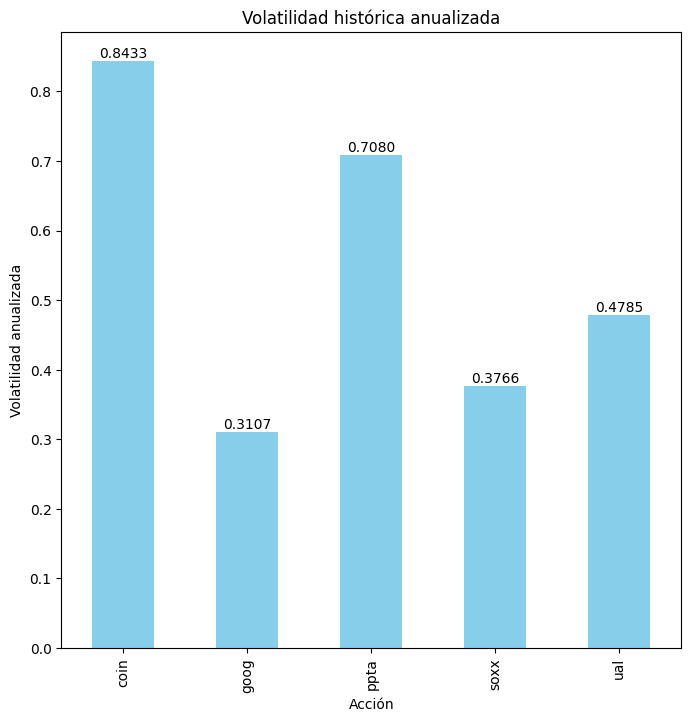

In [25]:
#Volatilidad histórica anualizada
annualized_vol = volatilidad_diaria * math.sqrt(252)

fig, ax = plt.subplots(figsize=(8,8))
barras = annualized_vol.plot(kind='bar', ax=ax, color='skyblue')

for barra in barras.patches:
  yval = barra.get_height()
  ax.text(
        barra.get_x() + barra.get_width() / 2, # Posición X (centrada)
        yval + 0.0005,                            # Posición Y (luego de la barra)
        f'{yval:.4f}',                             # Texto del valor, formateado a 4 decimales
        ha='center',                           # Alineación horizontal
        va='bottom'
    )

plt.title('Volatilidad histórica anualizada')
plt.ylabel('Volatilidad anualizada')
plt.xlabel('Acción')
plt.show()

La volatilidad anualizada que se muestra en los cinco activos entra dentro del rango usualmente aceptado como alto, frecuente en activos como criptomonedas o mercados con alto estrés financiero como el sector tecnológico o *"penny stocks"*.

Los datos anualizados son consistentes con la volatilidad diaria histórica. Esta vez los dos más altos (Coinbase y Perpetua Resoruces) tienen valores de 84.33% y 70.80%.

###Volatilidad móvil

La volatilidad móvil es una medida estadística que calcula cómo cambia la variabilidad de los rendimientos de un activo o mercado a lo largo del tiempo, en lugar de ofrecer un único número fijo para toda la historia del activo.

Por medio de esta metodología se puede obtener un proxy más comparable con las estimaciones de volatilidad diaria que se planean generar con el modelo GARCH, y se puede ir visualizando el comportaminto de la volatilidad a lo largo del periódo analizado y en distintas ventanas de tiempo.

Volatilidad móvil de 20 días
                coin      goog      ppta      soxx       ual
Fecha                                                       
2021-04-16       NaN       NaN       NaN       NaN       NaN
2021-04-19       NaN       NaN       NaN       NaN       NaN
2021-04-20       NaN       NaN       NaN       NaN       NaN
2021-04-21       NaN       NaN       NaN       NaN       NaN
2021-04-22       NaN       NaN       NaN       NaN       NaN
...              ...       ...       ...       ...       ...
2026-09-15  0.060466  0.013505  0.036164  0.024440  0.023068
2026-09-16  0.061070  0.013573  0.035836  0.022114  0.022442
2026-09-17  0.058945  0.013877  0.031419  0.023021  0.022293
2026-09-18  0.061753  0.013654  0.030853  0.023762  0.021137
2026-09-21  0.059760  0.014069  0.030546  0.025933  0.024001

[1364 rows x 5 columns]


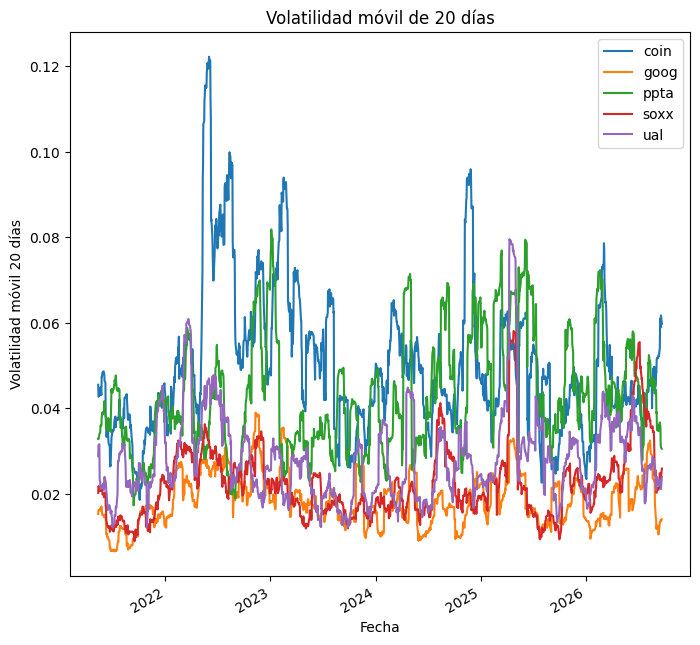


Volatilidad móvil máxima de 20 días
coin    0.122230
goog    0.039014
ppta    0.081862
soxx    0.058092
ual     0.079555
dtype: float64


In [26]:
#Volatilidad móvil a 20 días
volatilidad_20 = retornos_l.rolling(window=20).std()
print(f'Volatilidad móvil de 20 días')
print(volatilidad_20)

volatilidad_20.plot(figsize=(8,8))
plt.title('Volatilidad móvil de 20 días')
plt.ylabel('Volatilidad móvil 20 días')
plt.xlabel('Fecha')
plt.show()

print('')
print(f'Volatilidad móvil máxima de 20 días')
print(volatilidad_20.max())

En la ventana de 20 días se muestra como la volatilidad es muy responsiva ante cambios repentinos en las expectitivas y la incertidumbre respecto a los mercados. Los movimientos de COIN y PPTA muestran un comportamiento más errático con una mayor dispersión y magnituud en sus movimientos.

En el caso de la acción de Alphabet Inc. (Google) se aprecian movimientos, si bien no suavizados, de menor magnitud respecto a su tendencia histórica, lo cual es consistente con los resultados numéricos de su volatilidad histórica.

Volatilidad móvil de 60 días
                coin      goog      ppta      soxx       ual
Fecha                                                       
2021-04-16       NaN       NaN       NaN       NaN       NaN
2021-04-19       NaN       NaN       NaN       NaN       NaN
2021-04-20       NaN       NaN       NaN       NaN       NaN
2021-04-21       NaN       NaN       NaN       NaN       NaN
2021-04-22       NaN       NaN       NaN       NaN       NaN
...              ...       ...       ...       ...       ...
2026-09-15  0.048086  0.022869  0.040938  0.034313  0.024886
2026-09-16  0.048436  0.021881  0.040861  0.034142  0.024884
2026-09-17  0.048658  0.021925  0.040309  0.032923  0.024727
2026-09-18  0.050110  0.021923  0.039633  0.033136  0.022837
2026-09-21  0.049707  0.022026  0.039694  0.033355  0.023486

[1364 rows x 5 columns]


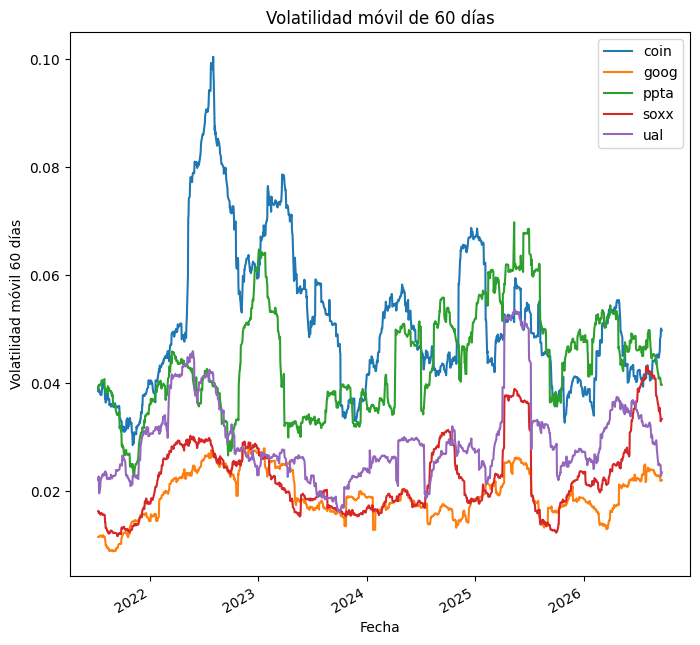


Volatilidad móvil máxima de 60 días
coin    0.100373
goog    0.028122
ppta    0.069754
soxx    0.043044
ual     0.053556
dtype: float64


In [27]:
#Volatilidad móvil a 60 días
volatilidad_60 = retornos_l.rolling(window=60).std()
print(f'Volatilidad móvil de 60 días')
print(volatilidad_60)

volatilidad_60.plot(figsize=(8,8))
plt.title('Volatilidad móvil de 60 días')
plt.ylabel('Volatilidad móvil 60 días')
plt.xlabel('Fecha')
plt.show()

print('')
print(f'Volatilidad móvil máxima de 60 días')
print(volatilidad_60.max())

Los datos de volatilidad móvil de 60 días pueden servir como contexto al suavizar los resultados y mostrar qué tan persistentes son los periódos de alta volatilidad al capturar la memoria de la volatilidad de mejor manera con la expansión la ventana de tiempo.


Volatilidad móvil de 120 días
                coin      goog      ppta      soxx       ual
Fecha                                                       
2021-04-16       NaN       NaN       NaN       NaN       NaN
2021-04-19       NaN       NaN       NaN       NaN       NaN
2021-04-20       NaN       NaN       NaN       NaN       NaN
2021-04-21       NaN       NaN       NaN       NaN       NaN
2021-04-22       NaN       NaN       NaN       NaN       NaN
...              ...       ...       ...       ...       ...
2026-09-15  0.044629  0.022462  0.044653  0.035376  0.031066
2026-09-16  0.044815  0.022472  0.044516  0.035367  0.031064
2026-09-17  0.044937  0.022297  0.044545  0.035150  0.031079
2026-09-18  0.045542  0.022159  0.044333  0.035161  0.030770
2026-09-21  0.045639  0.022208  0.044188  0.035115  0.030885

[1364 rows x 5 columns]


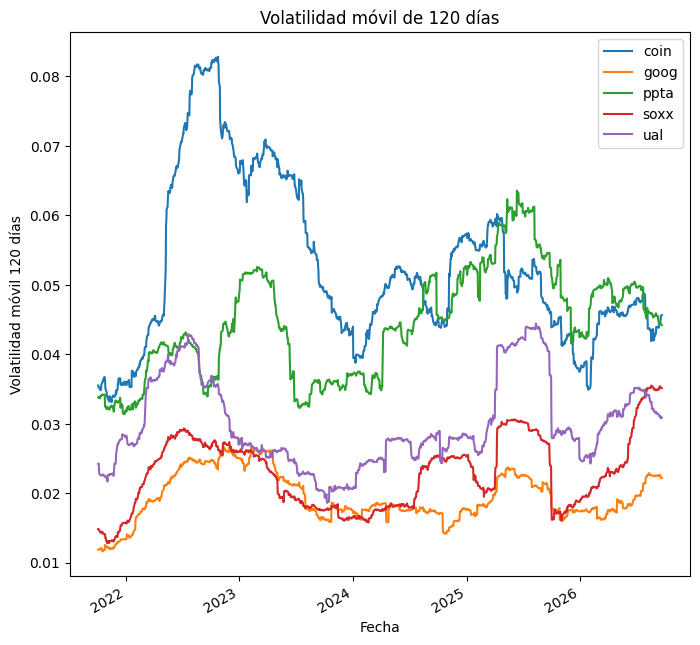


Volatilidad móvil máxima de 120 días
coin    0.082824
goog    0.026780
ppta    0.063553
soxx    0.035490
ual     0.044429
dtype: float64


In [28]:
#Volatilidad móvil a 120 días
volatilidad_120 = retornos_l.rolling(window=120).std()
print(f'Volatilidad móvil de 120 días')
print(volatilidad_120)

volatilidad_120.plot(figsize=(8,8))
plt.title('Volatilidad móvil de 120 días')
plt.ylabel('Volatilidad móvil 120 días')
plt.xlabel('Fecha')
plt.show()


print('')
print(f'Volatilidad móvil máxima de 120 días')
print(volatilidad_120.max())

Al observar laa ventana de 120 días, se observa de mejor forma que cambios verdaderamente fueron estructurales y que variaciones fueron simples shocks de volatilidad derivados de incertidumbre que afectan las expectativas en momentos puntuales y en mercados específicos.

Al suavizar los resultados y capturar la memoria de la volatilidad en un rango de 120 días, se pueden observar qué movimientos se trataron supusieron un cambio estructural importante al punto de afectar a todas las acciones; esto a pesar de perteneceer a un distinto sector.

Destacan momentos de alta incertidumbre como el mercado bajista de 2022 producto de la política monetaria restrictiva de la Reserva Federal, y el episodio arancelario drante la primera mitad de 2025.

###Eventos de alta volatilidad

Para identificar los periodos de alta volatilidad causados por eventos relevantes que afectan la economía y los mercados financieros se tomará como referencia la volatilidad móvil a 20 días, ya que al capturar un plazo más corto, ayuda a identificar la afección espontánea que caracteriza a los eventos volátiles.

El umbral a considerar como volatilidad alta serán los periodos en los que la volatilidad superó el percentil número 90, por lo que los datos de desviación estándar de los rendimientos que se encuentren dentro del 10% más alto, serán considerados como eventos de alta volatilidad.

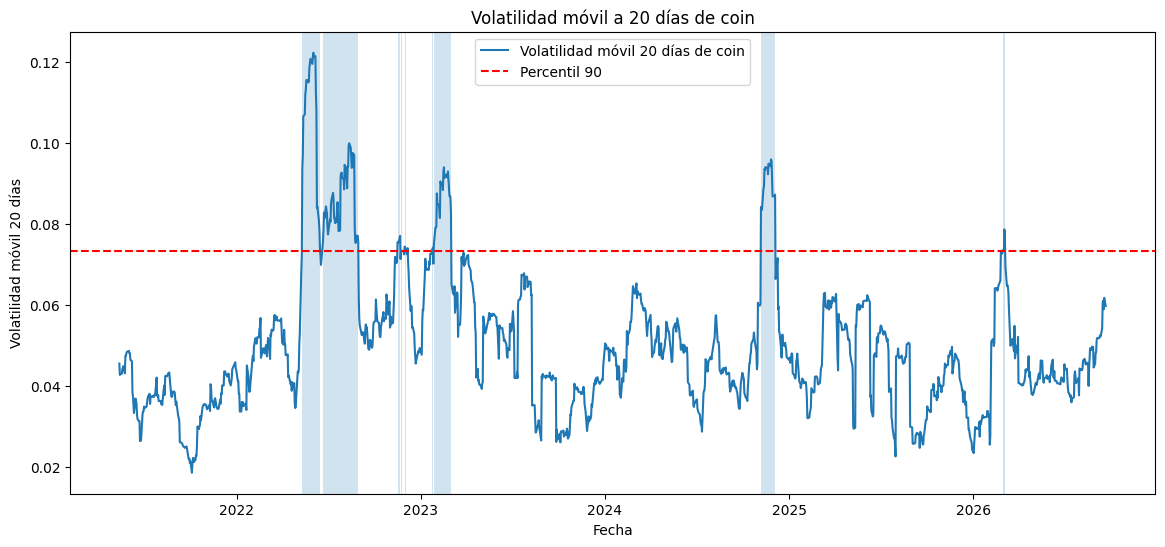


Periodos de alta volatilidad - coin
      Inicio        Fin
0 2022-05-11 2022-06-15
1 2022-06-21 2022-08-30
2 2022-11-16 2022-11-21
3 2022-11-23 2022-11-25
4 2022-11-30 2022-12-02
5 2022-12-06 2022-12-06
6 2023-01-24 2023-01-25
7 2023-01-27 2023-03-02
8 2024-11-06 2024-12-04
9 2026-03-02 2026-03-05


In [29]:
#Umbral de alta volatilidad
umbral = volatilidad_20['coin'].quantile(0.90)

#Identificar días por encima del umbral
periodos_hv = volatilidad_20['coin'] > umbral

#Identificar el inicio de cada nuevo periodo
inicio_periodo = periodos_hv & ~periodos_hv.shift(1, fill_value=False)

#Identificar el final de cada periodo
fin_periodo = periodos_hv & ~periodos_hv.shift(-1, fill_value=False)

#Obtener fechas
fechas_inicio = volatilidad_20.index[inicio_periodo]
fechas_fin = volatilidad_20.index[fin_periodo]

#Crear tabla de periodos
eventos = pd.DataFrame({
    "Inicio": fechas_inicio,
    "Fin": fechas_fin
})

#Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    volatilidad_20.index,
    volatilidad_20['coin'],
    label=f"Volatilidad móvil 20 días de coin"
)

plt.axhline(
    umbral,
    color='red',
    linestyle="--",
    label="Percentil 90"
  )

for inicio, fin in zip(fechas_inicio, fechas_fin):

    plt.axvspan(
        inicio,
        fin,
        alpha=0.20
    )

plt.title(f"Volatilidad móvil a 20 días de coin")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad móvil 20 días")
plt.legend()

plt.show()

#Tabla periodos
print(f"\nPeriodos de alta volatilidad - coin")
print(eventos)

- **11/05/2022 - 30/08/2022 (Bajista):** La Reserva Federal anuncia subida de tipos de interés; tendencia que se sostendría hasta la primera mitad de 2023.

- **16/11/2022 - 06/12/2022 (Bajista):** Caída del ecosistema Terra/Luna y la quiebra de FTX. Crece la presión política a favor de la legislación de criptoactivos.

- **24/01/2023 - 02/03/2023 (Bajista):** El periodo conocido como "Operación Choke Point 2.0" se caracterizó por la emisión de multas e investigaciones sobre Binance y Kraken, esto como resultado del aumento de presión legal que se aceleró con el desfalco de FTX.

- **06/11/2024 - 04/12/2024 (Alcista):** El entorno cripto se ve impulsado por la victoria de Donald Trump cuya postura generó optimismo regulatorio por el sector cripto.

- **02/03/2026 - 05/03/2026 (Alcista):** Choque institucional por los rendimientos de Stablecoins. Los bancos más grandes de Estados Unidos se opusieron a la idea de ofrecer rendimientos a sus clientes por la pocesión de monedas estables.

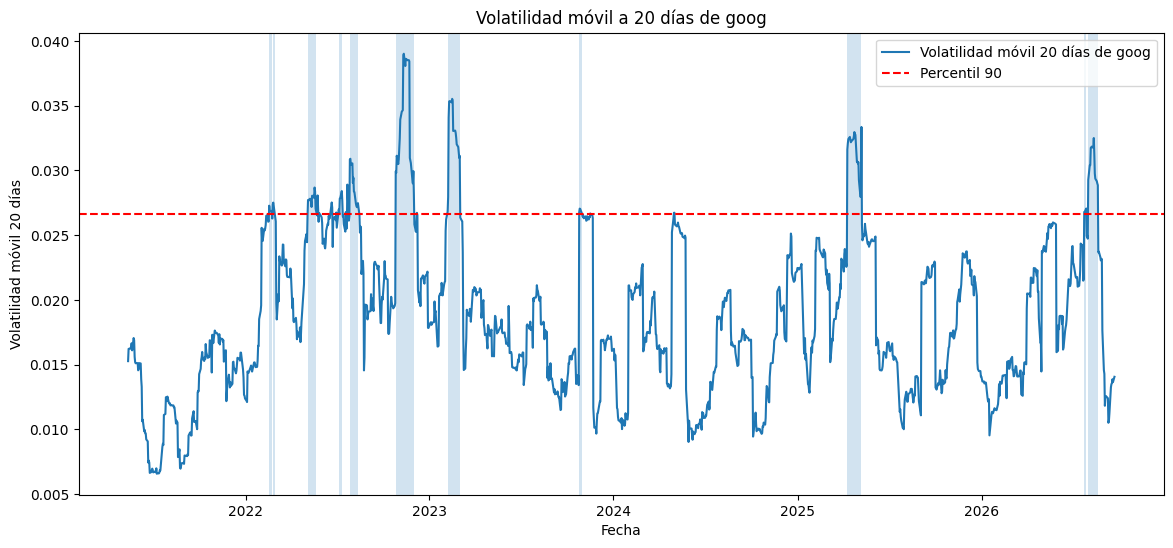


Periodos de alta volatilidad - goog
       Inicio        Fin
0  2022-02-17 2022-02-22
1  2022-02-24 2022-02-28
2  2022-05-05 2022-05-20
3  2022-05-24 2022-05-25
4  2022-05-27 2022-05-27
5  2022-06-21 2022-06-22
6  2022-06-30 2022-06-30
7  2022-07-05 2022-07-12
8  2022-07-19 2022-07-19
9  2022-07-22 2022-07-22
10 2022-07-27 2022-08-12
11 2022-10-26 2022-12-01
12 2022-12-07 2022-12-07
13 2023-02-06 2023-03-02
14 2023-10-25 2023-10-31
15 2023-11-16 2023-11-16
16 2024-04-30 2024-05-01
17 2025-04-09 2025-05-07
18 2026-07-23 2026-07-27
19 2026-07-31 2026-08-19


In [30]:
#Umbral de alta volatilidad
umbral = volatilidad_20['goog'].quantile(0.90)

#Identificar días por encima del umbral
periodos_hv = volatilidad_20['goog'] > umbral

#Identificar el inicio de cada nuevo periodo
inicio_periodo = periodos_hv & ~periodos_hv.shift(1, fill_value=False)

#Identificar el final de cada periodo
fin_periodo = periodos_hv & ~periodos_hv.shift(-1, fill_value=False)

#Obtener fechas
fechas_inicio = volatilidad_20.index[inicio_periodo]
fechas_fin = volatilidad_20.index[fin_periodo]

#Crear tabla de periodos
eventos = pd.DataFrame({
    "Inicio": fechas_inicio,
    "Fin": fechas_fin
})

#Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    volatilidad_20.index,
    volatilidad_20['goog'],
    label=f"Volatilidad móvil 20 días de goog"
)

plt.axhline(
    umbral,
    color='red',
    linestyle="--",
    label="Percentil 90"
  )

for inicio, fin in zip(fechas_inicio, fechas_fin):

    plt.axvspan(
        inicio,
        fin,
        alpha=0.20
    )

plt.title(f"Volatilidad móvil a 20 días de goog")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad móvil 20 días")
plt.legend()

plt.show()

#Tabla periodos
print(f"\nPeriodos de alta volatilidad - goog")
print(eventos)

- **17/02/2022 - 28/02/2022 (Bajista):** Invasión de Rusia a Ucrania (24 de febrero). El estallido del conflicto geopolítico generó pánico en los mercados globales, disparando la volatilidad (VIX) y provocando una fuerte caída generalizada en el sector tecnológico.   

- **05/05/2022 - 27/05/2022 (Bajista):** Venta masiva (sell-off) tecnológica. Periodo marcado por temores macroeconómicos debido a los reportes de alta inflación en EE. UU. y las agresivas subidas a las tasas de interés por parte de la Reserva Federal, lo que castigó fuertemente las valoraciones de empresas de crecimiento como Alphabet.

- **21/06/2022 - 12/08/2022 (Alcista):** Split de acciones y reporte del Q2. El 15 de julio de 2022, Alphabet ejecutó de forma oficial una división de sus acciones (stock split) histórica de 20 por 1. Días después, a finales de julio, presentaron sus resultados del segundo trimestre.

- **26/10/2022 - 07/12/2022 (Bajista):** Decepción en el Q3 2022 y freno publicitario. A finales de octubre, Alphabet reportó ingresos y ganancias por debajo de las expectativas de Wall Street. La noticia que más afectó el precio fue una caída inédita en los ingresos publicitarios de YouTube, reflejando el recorte de presupuesto de los anunciantes ante una posible recesión.

- **06/02/2023 - 02/03/2023 (Bajista):** El error del chatbot "Bard" (IA). El 8 de febrero de 2023, en el primer video promocional de su nueva inteligencia artificial, Bard dio un dato incorrecto. El mercado entró en pánico por temor a que Google perdiera la guerra de la IA contra Microsoft y OpenAI, borrando $100,000 millones de dólares de valor de mercado en un solo día.   

- **25/10/2023 - 16/11/2023 (Bajista):** Desaceleración en Google Cloud (Q3 2023). Aunque el reporte general de ganancias fue sólido, la división de la nube creció a su ritmo más lento en años y por debajo de las estimaciones. La acción cayó drásticamente casi un 10% en un día por miedo a ceder terreno frente a Azure y AWS.   

- **30/04/2024 - 01/05/2024 (Alcista):** Primer dividendo y recompra masiva (Q1 2024). La acción se disparó luego de un reporte financiero excepcional donde Alphabet anunció el primer dividendo de toda su historia (20 centavos por acción) y un gigantesco programa de recompra de acciones por $70,000 millones de dólares.

- **09/04/2025 - 07/05/2025 (Bajista):** Ganancias del Q1 2025 y presión legal. Volatilidad impulsada por la entrega de resultados financieros combinada con las noticias derivadas del juicio antimonopolio liderado por el Departamento de Justicia de EE. UU. (DOJ), periodo en el que se generó temor por posibles regulaciones estructurales contra su motor de búsqueda.

- **23/07/2026 - 19/08/2026  (Bajista):** Pánico por el costo de la Inteligencia Artificial (Q2 2026). A pesar de aplastar las estimaciones de ingresos (crecimiento del 82% en la nube), Alphabet anunció el 22 de julio que sus gastos de capital (capex) para infraestructura de IA escalarían hasta los $205,000 millones en el año. Este gasto masivo volvió negativo su flujo de caja libre (-5,900 millones de dólares) por primera vez en la era de la IA, desencadenando una venta masiva.

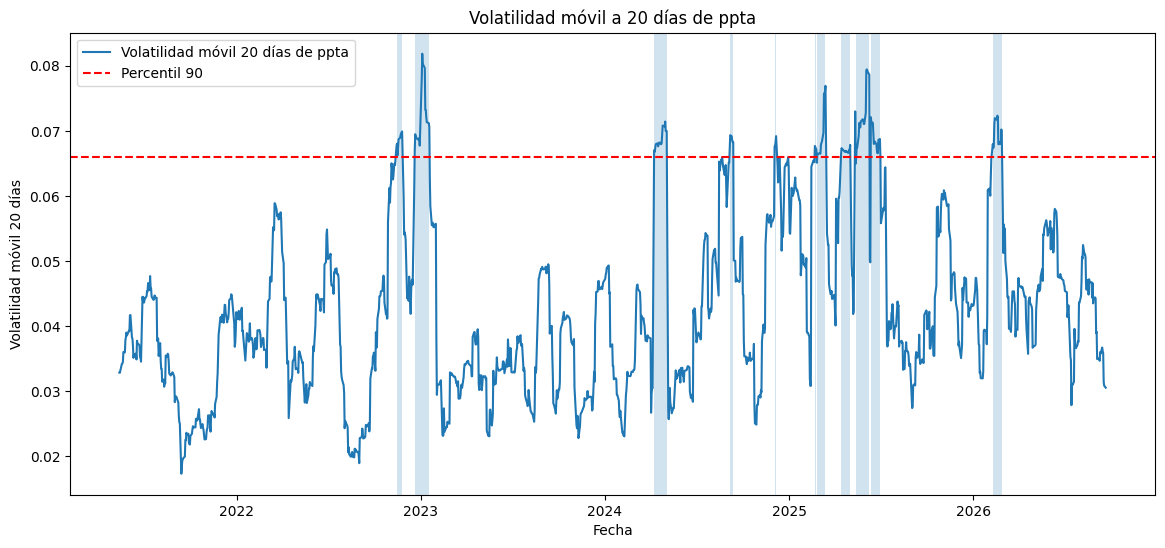


Periodos de alta volatilidad - ppta
       Inicio        Fin
0  2022-11-14 2022-11-25
1  2022-12-20 2023-01-18
2  2024-04-08 2024-05-03
3  2024-09-05 2024-09-12
4  2024-12-03 2024-12-06
5  2024-12-12 2024-12-12
6  2024-12-30 2024-12-30
7  2025-02-21 2025-02-24
8  2025-02-26 2025-03-14
9  2025-04-14 2025-05-02
10 2025-05-12 2025-05-12
11 2025-05-14 2025-06-09
12 2025-06-12 2025-07-01
13 2026-02-09 2026-02-27


In [31]:
#Umbral de alta volatilidad
umbral = volatilidad_20['ppta'].quantile(0.90)

#Identificar días por encima del umbral
periodos_hv = volatilidad_20['ppta'] > umbral

#Identificar el inicio de cada nuevo periodo
inicio_periodo = periodos_hv & ~periodos_hv.shift(1, fill_value=False)

#Identificar el final de cada periodo
fin_periodo = periodos_hv & ~periodos_hv.shift(-1, fill_value=False)

#Obtener fechas
fechas_inicio = volatilidad_20.index[inicio_periodo]
fechas_fin = volatilidad_20.index[fin_periodo]

#Crear tabla de periodos
eventos = pd.DataFrame({
    "Inicio": fechas_inicio,
    "Fin": fechas_fin
})

#Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    volatilidad_20.index,
    volatilidad_20['ppta'],
    label=f"Volatilidad móvil 20 días de ppta"
)

plt.axhline(
    umbral,
    color='red',
    linestyle="--",
    label="Percentil 90"
  )

for inicio, fin in zip(fechas_inicio, fechas_fin):

    plt.axvspan(
        inicio,
        fin,
        alpha=0.20
    )

plt.title(f"Volatilidad móvil a 20 días de ppta")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad móvil 20 días")
plt.legend()

plt.show()

#Tabla periodos
print(f"\nPeriodos de alta volatilidad - ppta")
print(eventos)

- **14/11/2022 - 25/11/2022 (Bajista)**: El mercado se recuperaba de la caída de 2022 ante expectativas de una Fed menos agresiva, favoreciendo al oro y a las mineras. En Perpetua, el avance regulatorio del proyecto Stibnite también apoyaba la acción.
- **20/12/2022 - 18/01/2023 (Alcista):** El principal catalizador fue el respaldo del gobierno estadounidense a los minerales críticos. Las expectativas de una Fed menos agresiva también favorecieron al oro.
- **08/04/2024 - 03/05/2024 (Bajista):** El anuncio de una carta de interés de EXIM Bank por hasta $1.8 mil millones impulsó inicialmente la acción, junto con el alto precio del oro y la importancia estratégica del antimonio. Sin embargo, Idaho revocó posteriormente el permiso de calidad del aire, aumentando la incertidumbre regulatoria.
- **05/09/2024 - 12/09/2024 (Alcista):** China anunció restricciones a las exportaciones de antimonio, aumentando la importancia estratégica de Stibnite. Al mismo tiempo, Perpetua avanzó hacia la publicación del Final Environmental Impact Statement, generando expectativas positivas sobre el proyecto.
- **03/12/2024 - 12/12/2024 (Alcista):** Las restricciones chinas al antimonio mantuvieron elevada la importancia estratégica de Stibnite. El mercado también esperaba la decisión final sobre el proyecto, mientras el elevado precio del oro favorecía sus perspectivas económicas.
- **21/02/2025 - 14/03/2025 (Bajista):** La actualización financiera de Perpetua, con nuevas estimaciones de costos de construcción y operación, generó presión sobre la acción. Posteriormente, investigaciones legales relacionadas con posibles reclamaciones de accionistas aumentaron la incertidumbre.
- **14/04/2025 - 01/07/2025 (Bajista):** La guerra comercial y los nuevos aranceles estadounidenses generaron elevada volatilidad en los mercados. Aunque la política de minerales críticos favorecía estratégicamente a Perpetua, el 20 de mayo el proyecto Stibnite completó el proceso federal de permisos, eliminando uno de sus principales riesgos regulatorios.
- **09/02/2026 - 27/02/2026 (Bajista):** Las tensiones entre EE. UU. y China mantuvieron la relevancia estratégica del antimonio. Sin embargo, grupos ambientalistas presentaron una petición contra el permiso de Stibnite, reintroduciendo incertidumbre regulatoria sobre el proyecto.

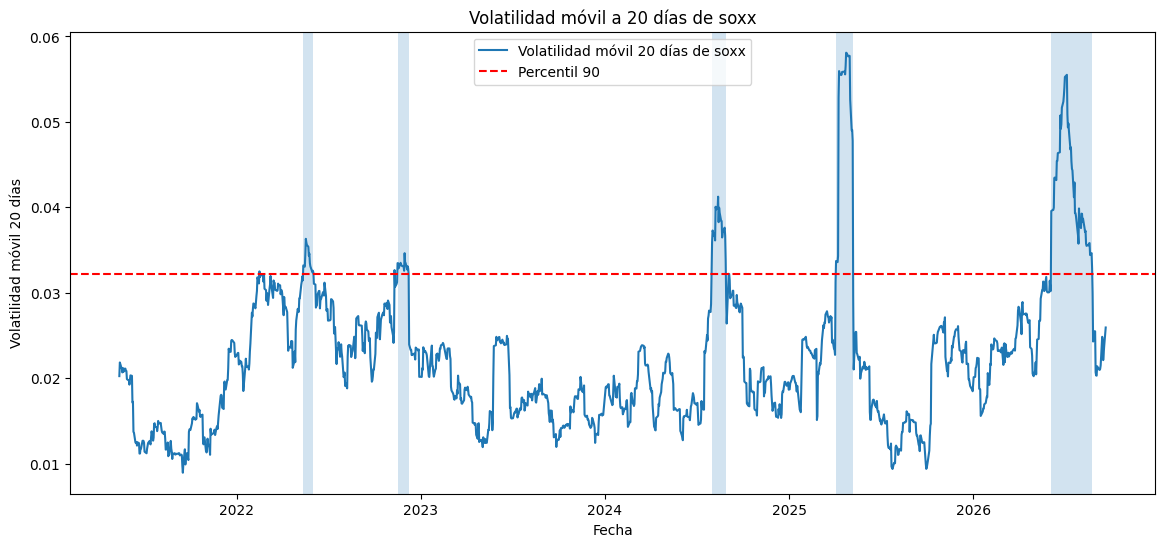


Periodos de alta volatilidad - soxx
      Inicio        Fin
0 2022-02-15 2022-02-15
1 2022-02-17 2022-02-17
2 2022-05-13 2022-06-02
3 2022-11-10 2022-11-10
4 2022-11-16 2022-12-08
5 2024-07-31 2024-08-28
6 2024-09-03 2024-09-04
7 2025-04-04 2025-05-07
8 2026-06-05 2026-08-25


In [32]:
#Umbral de alta volatilidad
umbral = volatilidad_20['soxx'].quantile(0.90)

#Identificar días por encima del umbral
periodos_hv = volatilidad_20['soxx'] > umbral

#Identificar el inicio de cada nuevo periodo
inicio_periodo = periodos_hv & ~periodos_hv.shift(1, fill_value=False)

#Identificar el final de cada periodo
fin_periodo = periodos_hv & ~periodos_hv.shift(-1, fill_value=False)

#Obtener fechas
fechas_inicio = volatilidad_20.index[inicio_periodo]
fechas_fin = volatilidad_20.index[fin_periodo]

#Crear tabla de periodos
eventos = pd.DataFrame({
    "Inicio": fechas_inicio,
    "Fin": fechas_fin
})

#Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    volatilidad_20.index,
    volatilidad_20['soxx'],
    label=f"Volatilidad móvil 20 días de soxx"
)

plt.axhline(
    umbral,
    color='red',
    linestyle="--",
    label="Percentil 90"
  )

for inicio, fin in zip(fechas_inicio, fechas_fin):

    plt.axvspan(
        inicio,
        fin,
        alpha=0.20
    )

plt.title(f"Volatilidad móvil a 20 días de soxx")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad móvil 20 días")
plt.legend()

plt.show()

#Tabla periodos
print(f"\nPeriodos de alta volatilidad - soxx")
print(eventos)

- **15/02/2022 - 17/02/2022 (Bajista):** Expectativas de una posible desescalada entre Rusia y Ucrania impulsaron al mercado tecnológico y a los semiconductores, aunque persistían las preocupaciones por inflación y futuras alzas de tasas de la Fed.

- **13/05/2022 - 02/06/2022 (Bajista):** Los semiconductores fueron afectados por inflación, aumentos de tasas, confinamientos en China y problemas de cadenas de suministro. El sector presentó fuertes rebotes dentro de una tendencia general bajista.

- **10/11/2022 - 08/12/2022 (Alcista):** Un dato de inflación estadounidense menor al esperado provocó un fuerte rally tecnológico al aumentar las expectativas de una Fed menos agresiva. Posteriormente, los problemas de exceso de inventarios y menor demanda de chips limitaron la recuperación.

- **31/07/2024 - 28/08/2024 (Bajista):** La expectativa de recortes de tasas impulsó inicialmente al sector, pero la elevada volatilidad de las acciones vinculadas a IA y la incertidumbre sobre las valuaciones del sector provocaron fuertes movimientos alrededor de los resultados de Nvidia.

- **03/09/2024 - 04/09/2024 (Bajista):** Fuerte corrección de las acciones tecnológicas y de semiconductores por toma de ganancias, dudas sobre las elevadas valuaciones relacionadas con IA y señales de debilidad económica en EE. UU.

- **04/04/2025 - 07/05/2025 (Bajista):** Los nuevos aranceles de EE. UU. provocaron una fuerte caída global de las acciones. La posibilidad de aranceles sobre semiconductores y las restricciones estadounidenses a la exportación de chips de IA hacia China aumentaron considerablemente la incertidumbre del sector.

- **05/06/2026 - 25/08/2026 (Bajista):** La volatilidad estuvo dominada por dudas sobre la sostenibilidad del boom de IA, las elevadas valuaciones del sector y las expectativas de tasas. Los resultados de empresas como Broadcom, Micron y Nvidia fueron especialmente relevantes para las perspectivas de demanda de semiconductores.

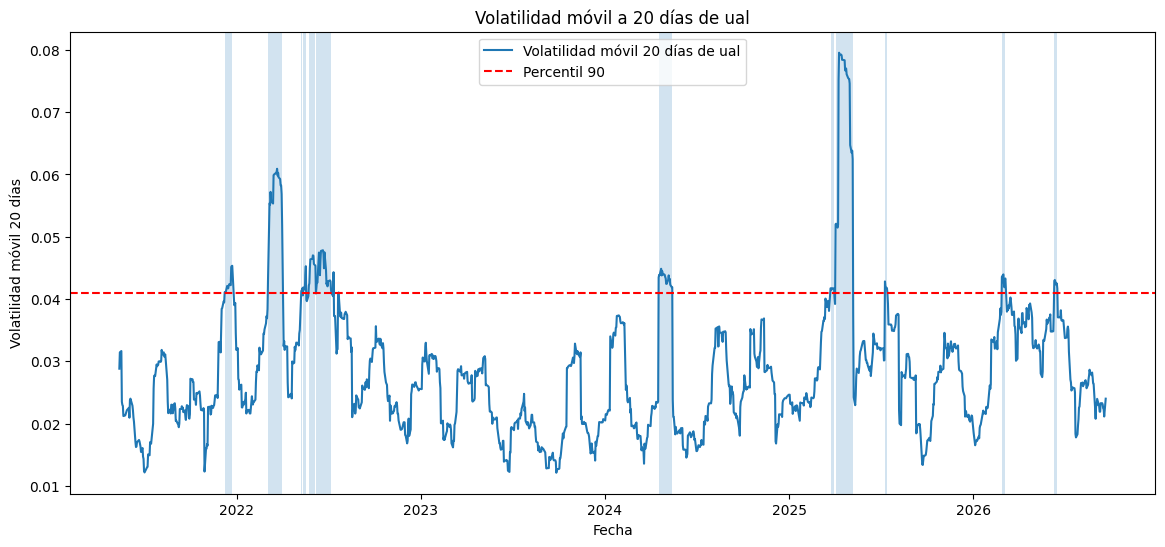


Periodos de alta volatilidad - ual
       Inicio        Fin
0  2021-12-08 2021-12-23
1  2022-03-04 2022-04-01
2  2022-05-09 2022-05-11
3  2022-05-13 2022-05-18
4  2022-05-24 2022-06-06
5  2022-06-08 2022-07-07
6  2022-07-12 2022-07-12
7  2022-07-22 2022-07-22
8  2024-04-17 2024-05-14
9  2025-03-24 2025-03-31
10 2025-04-03 2025-05-07
11 2025-07-10 2025-07-14
12 2026-02-27 2026-03-06
13 2026-06-11 2026-06-17


In [33]:
#Umbral de alta volatilidad
umbral = volatilidad_20['ual'].quantile(0.90)

#Identificar días por encima del umbral
periodos_hv = volatilidad_20['ual'] > umbral

#Identificar el inicio de cada nuevo periodo
inicio_periodo = periodos_hv & ~periodos_hv.shift(1, fill_value=False)

#Identificar el final de cada periodo
fin_periodo = periodos_hv & ~periodos_hv.shift(-1, fill_value=False)

#Obtener fechas
fechas_inicio = volatilidad_20.index[inicio_periodo]
fechas_fin = volatilidad_20.index[fin_periodo]

#Crear tabla de periodos
eventos = pd.DataFrame({
    "Inicio": fechas_inicio,
    "Fin": fechas_fin
})

#Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    volatilidad_20.index,
    volatilidad_20['ual'],
    label=f"Volatilidad móvil 20 días de ual"
)

plt.axhline(
    umbral,
    color='red',
    linestyle="--",
    label="Percentil 90"
  )

for inicio, fin in zip(fechas_inicio, fechas_fin):

    plt.axvspan(
        inicio,
        fin,
        alpha=0.20
    )

plt.title(f"Volatilidad móvil a 20 días de ual")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad móvil 20 días")
plt.legend()

plt.show()

#Tabla periodos
print(f"\nPeriodos de alta volatilidad - ual")
print(eventos)

- **08/12/2021 - 23/12/2021 (Bajista):** La aparición de Ómicron provocó nuevas restricciones y temor a una recuperación más lenta del tráfico aéreo, presionando nuevamente a las aerolíneas.

- **04/03/2022 - 22/07/2022 (Bajista):** La temporada alta de viajes estuvo marcada por problemas operativos, falta de personal y elevados costos de combustible. Los resultados del sector mostraban una demanda de viajes sólida, pero con presión sobre los márgenes de las aerolíneas.

- **17/04/2024 - 14/05/2024 (Bajista):** United reportó resultados mejores de lo esperado y mejoró sus perspectivas, impulsando la acción. Sin embargo, los problemas de Boeing y las dificultades de entrega del 737 MAX continuaban generando incertidumbre para la capacidad futura de la aerolínea.

- **24/03/2025 - 07/05/2025 (Bajista):** Los anuncios arancelarios de Trump incrementaron los temores de una recesión y de menor demanda de viajes. United señaló que una desaceleración económica podría afectar significativamente sus ganancias, aumentando la volatilidad de la acción.

- **10/07/2025 - 14/07/2025 (Alcista):** Las expectativas de recuperación de la demanda y de mejores resultados del sector impulsaron las acciones de aerolíneas. United posteriormente reportó una sólida demanda y mejoró su perspectiva de ganancias.

- **27/02/2026 - 06/03/2026 (Bajista):** Las preocupaciones macroeconómicas y el comportamiento del petróleo volvieron a ser relevantes para las aerolíneas, debido al impacto directo del combustible sobre sus costos y márgenes.

- **11/06/2026 - 17/06/2026 (Bajista):** El aumento del precio del combustible generó presión sobre las perspectivas de rentabilidad de las aerolíneas, aunque la fortaleza de la demanda de viajes y de los ingresos premium ayudaba a compensarla.

###Relación entre volatilidad y rendimiento

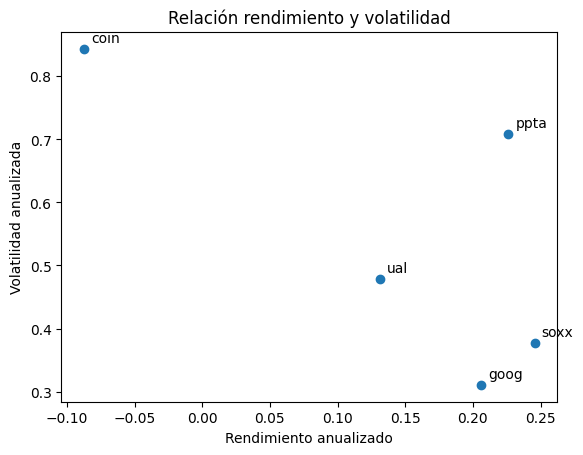

In [34]:
#Ratio rendimiento/volatilidad
plt.scatter(x=annualized_return,y=annualized_vol)
for ticker, x, y in zip(stocks, annualized_return, annualized_vol):
    plt.annotate(ticker, (x, y), xytext=(5, 5), textcoords='offset points')
plt.title(f'Relación rendimiento y volatilidad')
plt.xlabel('Rendimiento anualizado')
plt.ylabel('Volatilidad anualizada')
plt.show()

In [35]:
annualized_return.name = 'Annualized Return'
annualized_vol.name = 'Annualized Volatility'

rate_table = pd.merge(annualized_return, annualized_vol, left_index=True, right_index=True, how='inner')
rate_table['R/σ'] = rate_table['Annualized Return']/rate_table['Annualized Volatility']
rate_table

,Annualized Return,Annualized Volatility,R/σ
coin,-0.087447,0.843280,-0.103699
goog,0.206360,0.310682,0.664216
ppta,0.226218,0.707973,0.319530
soxx,0.245734,0.376598,0.652511
ual,0.131565,0.478464,0.274974


Por bastante diferencia, los activos que mejor recompensan cada unidad de riesgo asumida son la acción goog y el ETF soxx, con ratios muy similares de 0.6642 y 0.6525 respectivamente.

La acción coin muestra un ratio negativo debido a que su rendimiento diario anualizado durante el periodo analizado fue una pérdida, por lo que para nada recompensa el riesgo asumido (el más alto entre los cinco activos).

##Correlación entre activos

El análisis de correlación de series de tiempo financieras mide el grado y la dirección en que dos o más variables financieras (como precios de acciones, tasas de interés o índices de mercado) se mueven juntas a lo largo del tiempo.

En este caso se utilizará por simplicidad metodológica el método de Pearson.

Interpretación de valores:

⬆️ +0.8 → Relación fuerte positiva (ambos suben juntos) ⚠️posible colinealidad

⬆️ +0.5 a +0.8 → relación moderada positiva

↗️ +0.1 a +0.5 → relación débil positiva

⚪ ≈ 0 → Sin relación

↘️ −0.1 a −0.5 → relación débil negativa

⬇️ -0.5 a -0.8 → relación moderada negativa

⬇️ -0.8 → Relación fuerte negativa (uno sube, el otro baja)


###Matriz de correlación

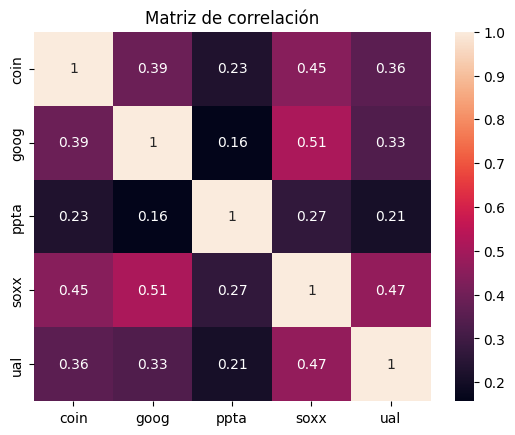

In [36]:
#Matriz de correlación
corr_matrix = retornos_l.corr()
sns.heatmap(corr_matrix,annot=True)

plt.title('Matriz de correlación')
plt.show()

Según los coeficientes de correlación de Pearson se observa una correlación (más no causalidad) positiva débil entre todos los pares de activos, excepto entre goog y soxx, cuyo coeficiente de 0.51 representa una relación positiva moderada, lo cual se explica conociendo que ambos activos representan acciones del sector tecnológico.

Debido a que ninguno de los pares muestra una correlación fuerte se puede asumir que, de forma general, no hay señales de riesgo por colinealidad.

###Gráfico de pares

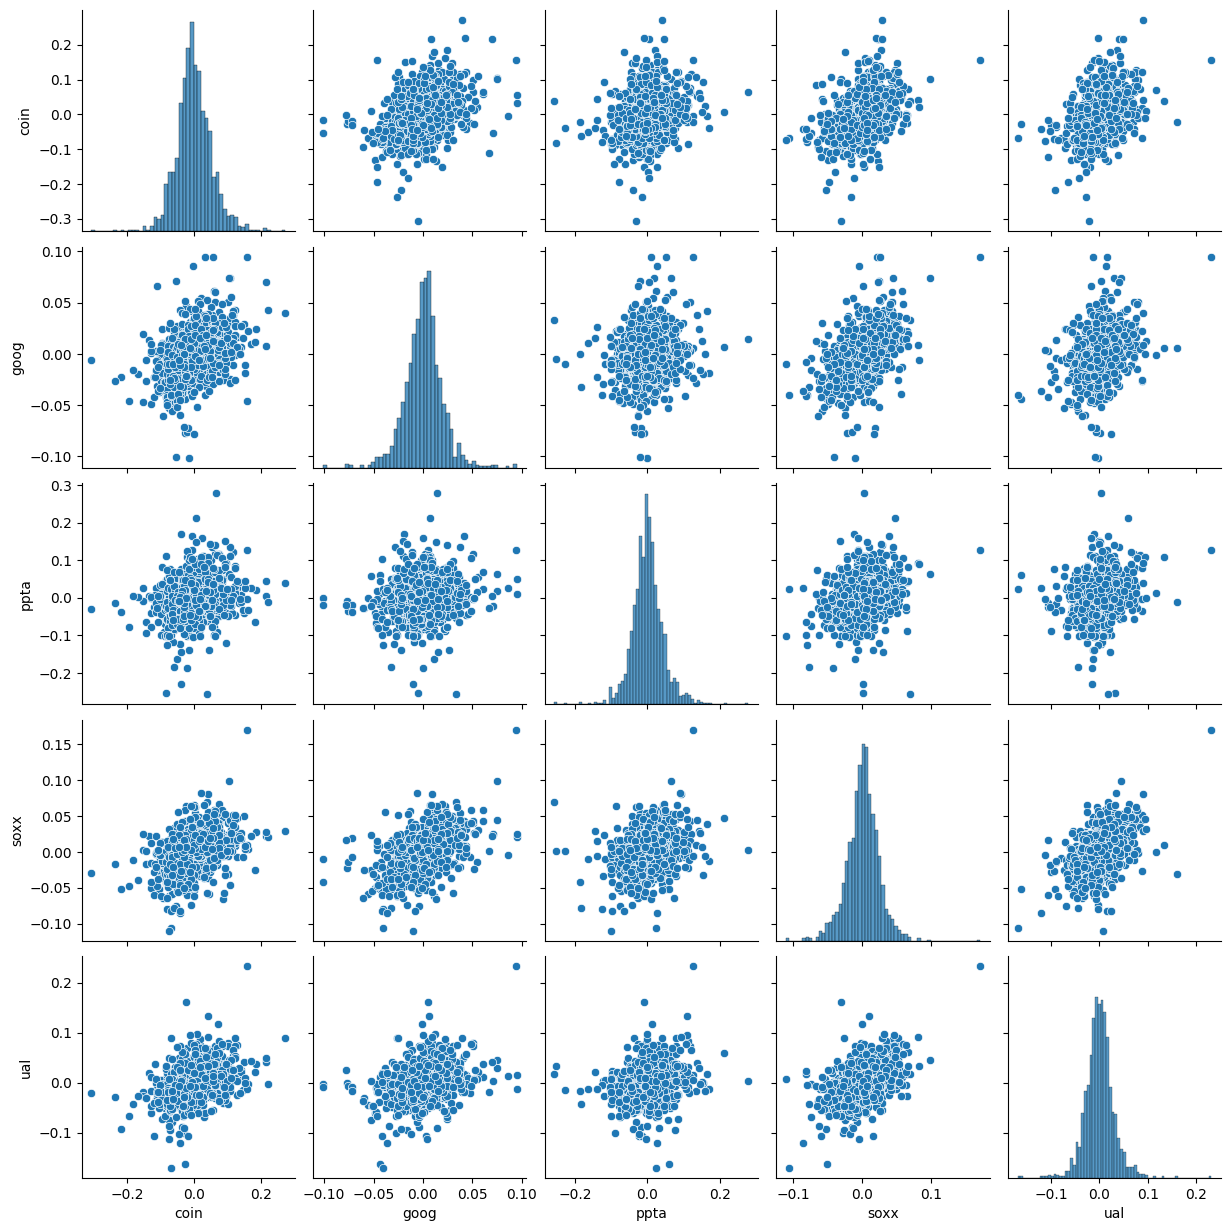

In [37]:
#Gráfico de pares
sns.pairplot(retornos_l)

Los gráficos de cada par muestran una dispersión significativa, lo cual acompaña a la idea de una correlación entre baja y moderada entre los rendimientos de los activos.

Así mismo, se vuelve clara la imagen de una correlación positiva al observar una tendencia a la alza en el gráfico.

##Beta y sensibilidad de activos

El coeficiente beta (β) de una acción es una medida estadística que indica cuán volátil es el precio de un título en comparación con el mercado en general (como el S&P 500 o el IPC de la Bolsa Mexicana de Valores). Mide el riesgo sistemático que no se puede eliminar mediante la diversificación.

Dicha métrica es de suma importancia al evaluar la exposición de una acción a la dinámica general de la bolsa de valores, además de ser importante al momento de estimar la tasa de rendimiento que se debería exigir a una inversión al momento de valuar un proyecto de inversión en bolsa.

###Preparación de datos del índice

Para poder calcular la relación de los activos con el mercado en general se suele utilizar como estándar el índice S&P 500, el cual mide el rendimiento de las 500 empresas más grandes de Estados Unidos y sirve como el principal barómetro de sus mercados bursátiles.

Para ello se contruirá un nuevo dataframe que incluya los cinco activos a analizar junto con la serie de tiempo del puntaje del S&P 500 durante el mismo periódo de tiempo analizado.

In [38]:
#Cargar datos diarios del S&P 500
sp = pd.read_csv('sp_data.csv')

sp.head()

,Fecha,sp500
0,2021-04-15,4170.4
1,2021-04-16,4185.5
2,2021-04-19,4163.3
3,2021-04-20,4134.9
4,2021-04-21,4173.4


In [39]:
#Inspección y validación
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fecha   1365 non-null   object 
 1   sp500   1365 non-null   float64
dtypes: float64(1), object(1)
memory usage: 21.5+ KB



- `Fecha`: Fecha de cada sesión de mercado entre el 15/04/2021 y el 21/09/2026 (se ha definido como índice del dataset).
- `sp500`: Valor al cierre de cada sesión del índice S&P 500, índice benchmark que sigue el movimiento ponderado de las 500 acciones más representativas de la bolsa estadounidense.

In [40]:
#Corrección de tipo de dato en la columna Fecha
sp['Fecha'] = pd.to_datetime(sp['Fecha'])

#Establecer la columna fecha cómo índice de las filas
sp = sp.sort_values('Fecha')
sp = sp.set_index('Fecha')

In [41]:
#Revisión
sp.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1365 entries, 2021-04-15 to 2026-09-21
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sp500   1365 non-null   float64
dtypes: float64(1)
memory usage: 21.3 KB


- El conteo de filas es consistente con el dataset de 'stocks_data.csv'.
- No existe presencia de datos nulos en el dataset.

In [42]:
#Cálculo de retornos diarios del S&P 500
retornos_l_sp = calculate_l_returns(sp)
retornos_l_sp = retornos_l_sp.dropna()

#Creación de tabla conjunta
l_return_summary = pd.merge(retornos_l, retornos_l_sp, left_index=True, right_index=True, how='inner')
l_return_summary.head()

,coin,goog,ppta,soxx,ual,sp500
Fecha,,,,,,
2021-04-16,0.057933,0.000522,0.000000,-0.004676,-0.004465,0.003614
2021-04-19,-0.026668,0.002000,0.022728,-0.026637,-0.015876,-0.005318
2021-04-20,-0.037262,-0.003829,-0.016998,-0.014403,-0.089146,-0.006845
2021-04-21,-0.028133,-0.000174,0.029559,0.025916,0.030543,0.009268
2021-04-22,-0.061039,-0.011050,0.001386,-0.022031,-0.016134,-0.009244


###Beta

In [43]:
#Cálculo de la beta
betas =  {}

for ticker in stocks:
    cov = retornos_l[ticker].cov(retornos_l_sp['sp500'])
    var_mercado = retornos_l_sp['sp500'].var()
    betas[ticker] = cov / var_mercado

betas = pd.Series(betas)
betas.name = 'Beta'
betas

,Beta
coin,2.686609
goog,1.260170
ppta,1.194463
soxx,1.805023
ual,1.636185


Las betas de los cinco activos muestran que sus rendimientos son muy sensibles a los rendimientos del S&P 500 con una relación positiva.

La acción con la beta más baja es la de Perpetua Resources con 1.19, mientras que la más alta por mucha diferencia en la acción de Coinbase, con una beta de 2.69 (activo extremadamente sensible al mercado en general).

###Beta móvil

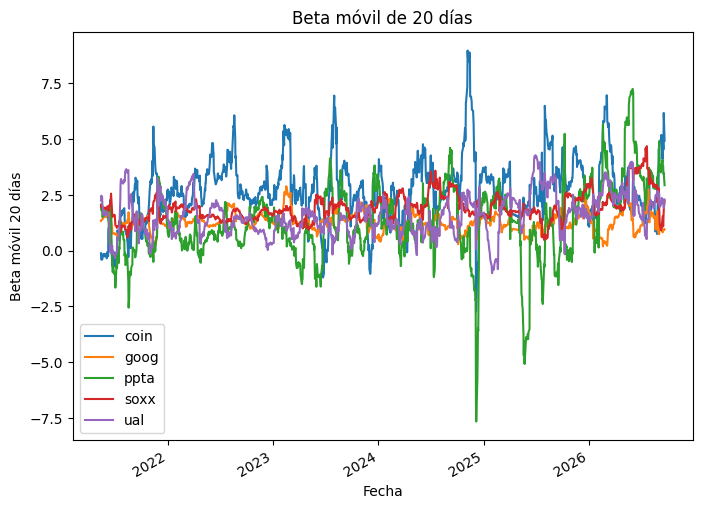


Máxima y mínima beta móvil 20 días


,Max Beta,Min Beta
coin,8.961378,-2.733307
goog,2.884500,0.132079
ppta,7.245918,-7.655256
soxx,4.680758,0.476210
ual,4.273071,-1.010192


In [44]:
#Beta móvil de 20 días
beta_movil_20 = pd.DataFrame(index=l_return_summary.index)

for ticker in stocks:
    beta_movil_20[ticker] = (
        l_return_summary[ticker].rolling(20).cov(
            l_return_summary['sp500']
        )
        /
        l_return_summary['sp500'].rolling(20).var()
    )

beta_movil_20.plot(figsize=(8,6))
plt.title('Beta móvil de 20 días')
plt.xlabel('Fecha')
plt.ylabel('Beta móvil 20 días')
plt.show()

print('')
print('Máxima y mínima beta móvil 20 días')
max_betas = beta_movil_20.max()
min_betas = beta_movil_20.min()
max_betas.name = 'Max Beta'
min_betas.name = 'Min Beta'
pd.merge(max_betas, min_betas, left_index=True, right_index=True, how='inner')

La beta móvil de 20 días es bastante volátil, mostrando una dispersión muy importante en los cambios de sensibilidad a los rendimientos del mercado.

Esto no solo se puede observar en el gráfico, sino que al analizar los valores máximos y mínimos de la beta a lo largo del periódo, se aprecia una diferencia enorme entre los extremos, destacando el caso de ppta, la cual oscila entre 7.24 y -7.65, mostrandose muy innestable y reaccionaria a los movimeintos del mercado en el corto plazo.

Tanto Coinbase como Perpetua Resources parecen haber sido los más reaccionarios ante los movimientos del mercado ocurridos a finales de 2024, momento en el cual los resultados de las elecciones de Estados Unidos jugaron un papel muy crucial en el sentimiento del mercado, siendo muy favorable para el entorno cripto y muy incierto para el sector de minerales raros.

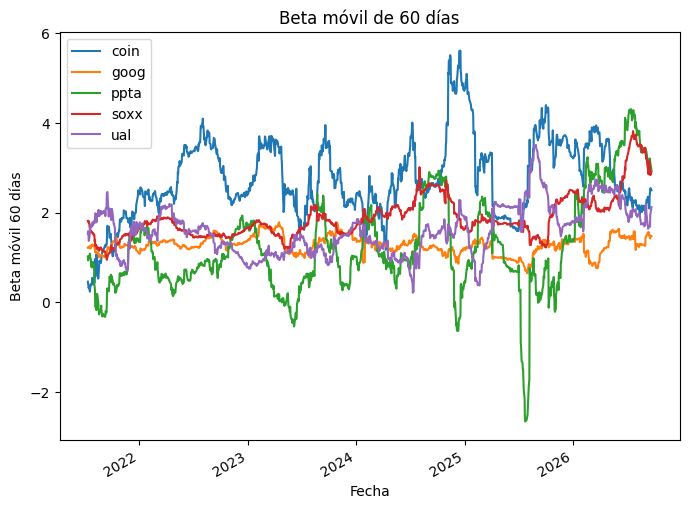


Máxima y mínima beta móvil 60 días


,Max Beta,Min Beta
coin,5.612590,0.238036
goog,1.784229,0.646497
ppta,4.309603,-2.655499
soxx,3.818402,0.949196
ual,3.509665,0.213340


In [45]:
#Beta móvil de 60 días
beta_movil_60 = pd.DataFrame(index=l_return_summary.index)

for ticker in stocks:
    beta_movil_60[ticker] = (
        l_return_summary[ticker].rolling(60).cov(
            l_return_summary['sp500']
        )
        /
        l_return_summary['sp500'].rolling(60).var()
    )

beta_movil_60.plot(figsize=(8,6))
plt.title('Beta móvil de 60 días')
plt.xlabel('Fecha')
plt.ylabel('Beta móvil 60 días')
plt.show()

print('')
print('Máxima y mínima beta móvil 60 días')
max_betas = beta_movil_60.max()
min_betas = beta_movil_60.min()
max_betas.name = 'Max Beta'
min_betas.name = 'Min Beta'
pd.merge(max_betas, min_betas, left_index=True, right_index=True, how='inner')

En la temporalidad de 60 días se puede ver un comportamiento más estable sin perder de vista los cambios continuos en la sensibilidad de los rendimientos a lo largo del periodo de 5 años, por lo que los comportamientos y tendencias observables son de gran importancia para el análisis.

Google destaca nuevamente por tener una sensibilidad más estable, oscilando entre su mínimo de 0.65 y su máximo de 1.78.

El resto de activos tienen una sensibilidad con mayor variación, con máximos por encima de una betaa de 3. Los casos más destacados serían Coinbase y Perpetua Resources, ya que su máximo es de 5.61 y 4.31 respectivamente, y con la peculiariada de que ppta es la única variable con valores por debajo de 0, lo que significa que hubo episodios en los que su relación fue inversa a los rendimientos del mercado en general, con un valor mínimo de -2.65.

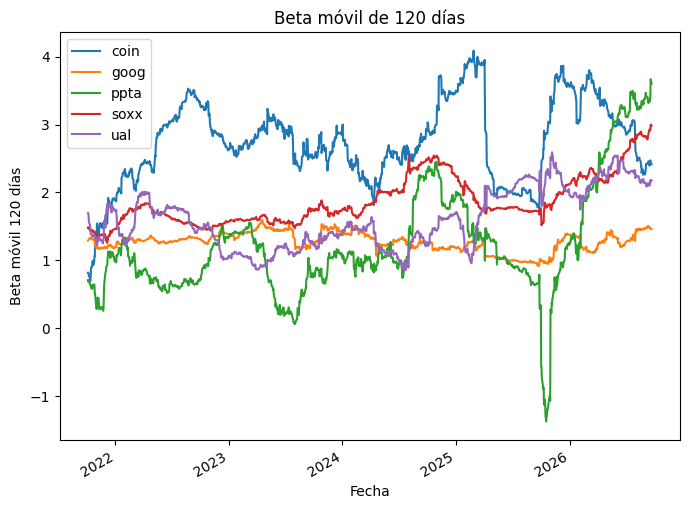


Máxima y mínima beta móvil 120 días


,Max Beta,Min Beta
coin,4.089383,0.690752
goog,1.592781,0.918084
ppta,3.667452,-1.373788
soxx,2.997880,1.257528
ual,2.591375,0.851276


In [46]:
#Beta móvil de 120 días
beta_movil_120 = pd.DataFrame(index=l_return_summary.index)

for ticker in stocks:
    beta_movil_120[ticker] = (
        l_return_summary[ticker].rolling(120).cov(
            l_return_summary['sp500']
        )
        /
        l_return_summary['sp500'].rolling(120).var()
    )

beta_movil_120.plot(figsize=(8,6))
plt.title('Beta móvil de 120 días')
plt.xlabel('Fecha')
plt.ylabel('Beta móvil 120 días')
plt.show()

print('')
print('Máxima y mínima beta móvil 120 días')
max_betas = beta_movil_120.max()
min_betas = beta_movil_120.min()
max_betas.name = 'Max Beta'
min_betas.name = 'Min Beta'
pd.merge(max_betas, min_betas, left_index=True, right_index=True, how='inner')

Está última temporalidad se puede visualizar una representación más estable del comportamiento a mediano plazo.

Los comportamientos y tendencias siguen siendo los mismos, pero en este análisis se detaca la detección de los momentos en que la relación entre los rendimientos de las acciones y el índice se han amplificado intensamente.

Peridos como el mercado bajista de 2022 a 2023, la recuperación en 2024, el episodio arancelario de 2025 y las tensiónes en Medio Oriente en 2026 se muestran con efectos consistentes entre variables.

La acción con la beta más estable es la de Alphabet Inc., lo cual hace sentido teniendo en cuenta que el peso de sus acciones Clase C (GOOG) en el índice es de 2.86%, y de 5.93% si sumamos sus acciones Clase A (GOOGL).

##Autocorrelación

La autocorrelación es la medida de la relación lineal entre los valores de una misma variable en diferentes momentos del tiempo o espacios.

En el caso de las series de tiempo financieras coloquialmente se dice que *"el rendimiento de hoy, influye en el precio de mañana"*. Esta afirmación es muy simplista, pero lo cierto es que al analizar las distribuciones previamente, una característica que se presentó fue la presencia de sesgos y una distribución no normal. Estos factores indican que no existe independencia total entre los precios o los rendimientos diarios de un activo.

Esto es un problema cuando se desea representar el comportamiento de estos activos por medio de regresiones lineales simples además de que infla los resultados de un modelo haciendolo parecer mejor de lo que en realidad es fuera de muestra, pero lo cierto es que esta característica es sumamente útil cuando se usa en modelos de estimación que capturan este factor a su favor.

Los modelos ARIMA y los modelos GARCH utilizan parámetros que miden la relación entre el valor actual y los valores pasados (rezagos). Utiliza la historia reciente para predecir el futuro, cosa que se logra por medio de la relación entre dichos valores.

###Pruebas de estacionariedad

Las pruebas de estacionariedad sirven para verificar si las propiedades estadísticas de una serie de tiempo (como su media, varianza y covarianza) cambian o se mantienen constantes a lo largo del tiempo.
En términos sencillos, determinan si una serie tiene un comportamiento estable o si tiene tendencias y ciclos que cambian constantemente.

La mayoría de los modelos de pronóstico (como ARIMA) asumen que las series son estacionarias. Si no lo son, los pronósticos futuros fallarán fácilmente, ya que si se intenta relacionar dos variables no estacionarias, los modelos estadísticos pueden mostrar una relación matemática fuerte que en la realidad no existe.

Es por ello que previo a la formulación de los modelos, es necesario comprobar esta propiedad en las series de tiempo de rendimientos que se desean utilizar.

In [47]:
#Diagnótico de estacionariedad
for ticker in stocks:
  p_adf = adfuller(retornos_l[ticker])[1]
  p_kpss = kpss(retornos_l[ticker], regression = 'c')[1] #regression='c' para evaluar estacionariedad alrededor de una constante

  if p_adf <= 0.05 and p_kpss > 0.05:
      print(f"=> {ticker}: La serie es estrictamente estacionaria")
  elif p_adf > 0.05 and p_kpss <= 0.05:
      print(f"=> {ticker}: La serie no es estacionaria. Requiere diferenciación")
  elif p_adf > 0.05 and p_kpss > 0.05:
      print(f"=> {ticker}: Caso ambiguo (Muestra insuficiente o estructura débil). Se sugiere diferenciar.")
  else:
      print(f"=> {ticker}: Estacionaria en tendencia (debes remover la tendencia antes del análisis).")

=> coin: La serie es estrictamente estacionaria
=> goog: La serie es estrictamente estacionaria
=> ppta: La serie es estrictamente estacionaria
=> soxx: La serie es estrictamente estacionaria
=> ual: La serie es estrictamente estacionaria


**Nota**:
- Prueba ADF (H0: La serie no es estacionaria)
- Prueba KPSS (H0: La serie es estacionaria)

Los resultados de ambas pruebas llegan al consenso de que las cinco series de rendimientos son estacionarias (no poseen raíz unitaria), por lo que su media y su varianza son constantes en el tiempo.

Dicho resultado significa que es viable la construcción de un modelo ARIMA sin necesidad de aplicar diferenciación, y por ende se aplicarán las respectivas pruebas de autocorrelación para identificar rezagos que demuestren dependencia temporal.


###ACF/PACF de los rendimientos

Según  la regla del Logaritmo 10 * ln10(n) para una serie de tiempo de 1,364 datos se sugieren 31 rezagos para las funciones de autocorrelación. Es el valor ideal para no saturar el gráfico y evaluar los efectos de corto plazo.

COIN


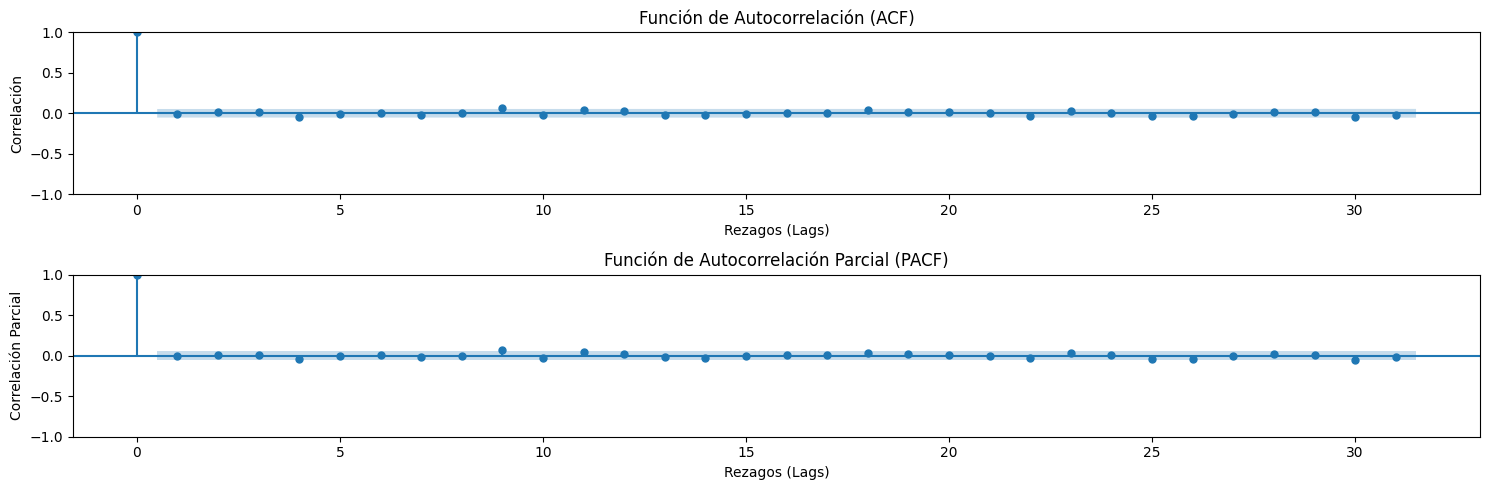


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 9]
Rezagos significativos en PACF: [0, 9, 30]

GOOG


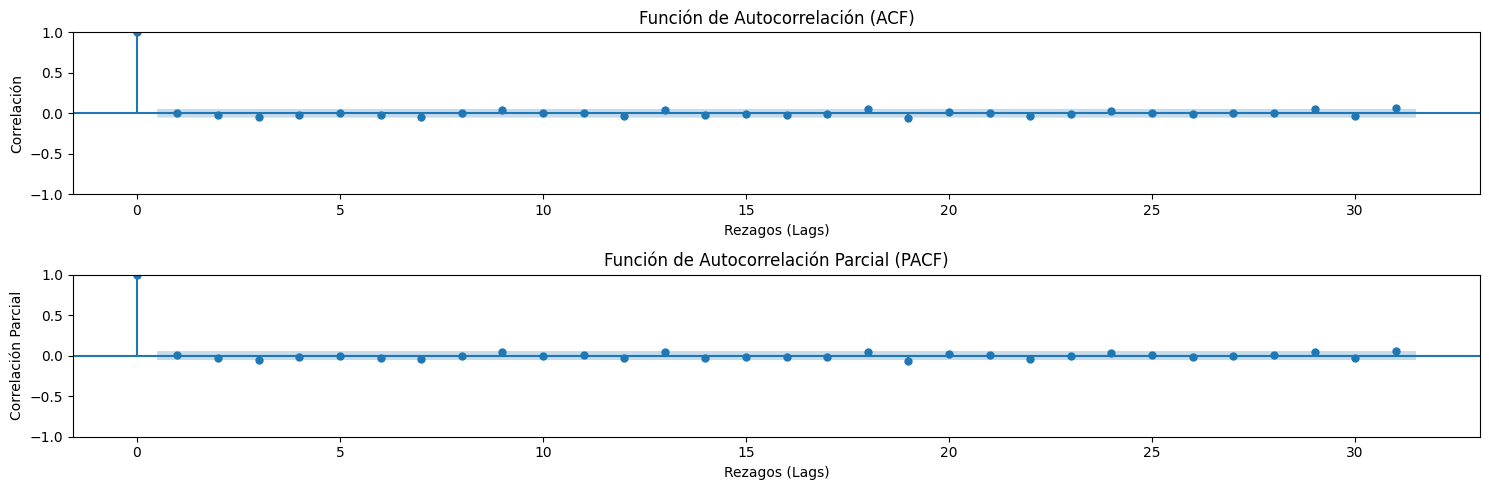


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 18, 19, 31]
Rezagos significativos en PACF: [0, 19, 31]

PPTA


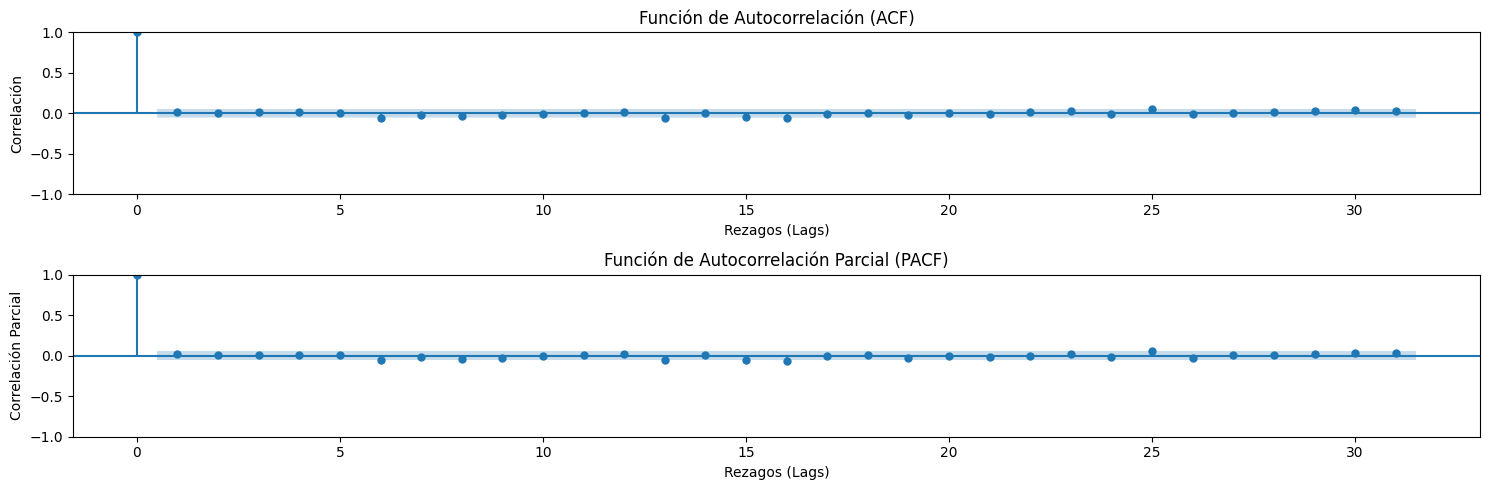


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 6, 13, 16, 25]
Rezagos significativos en PACF: [0, 6, 13, 16, 25]

SOXX


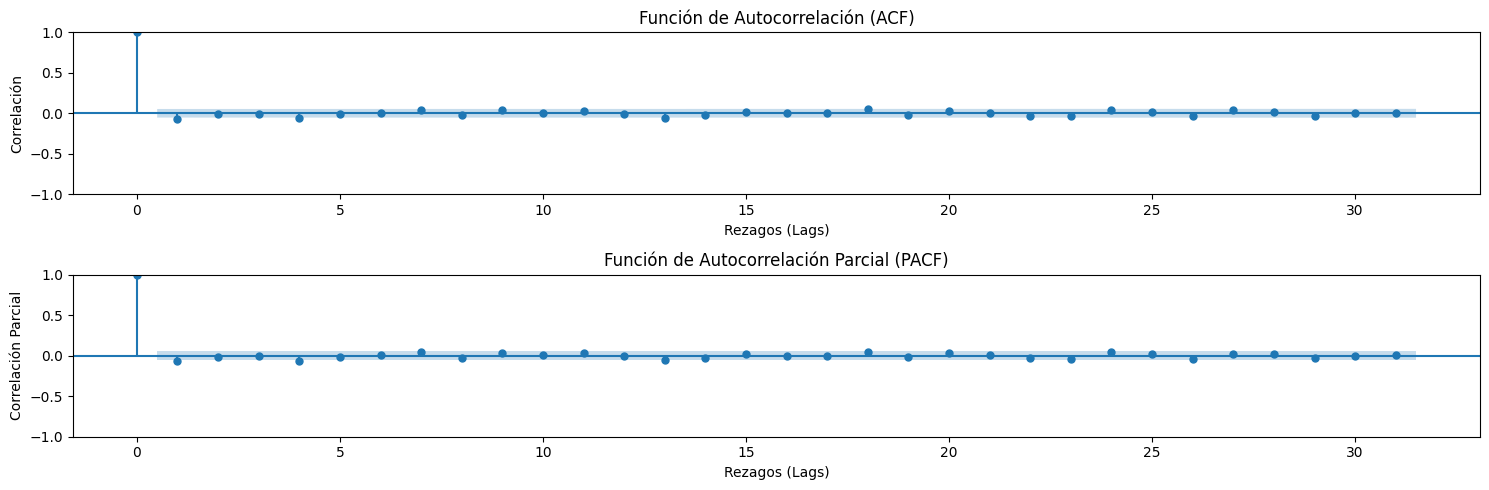


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 1, 4, 13]
Rezagos significativos en PACF: [0, 1, 4, 13]

UAL


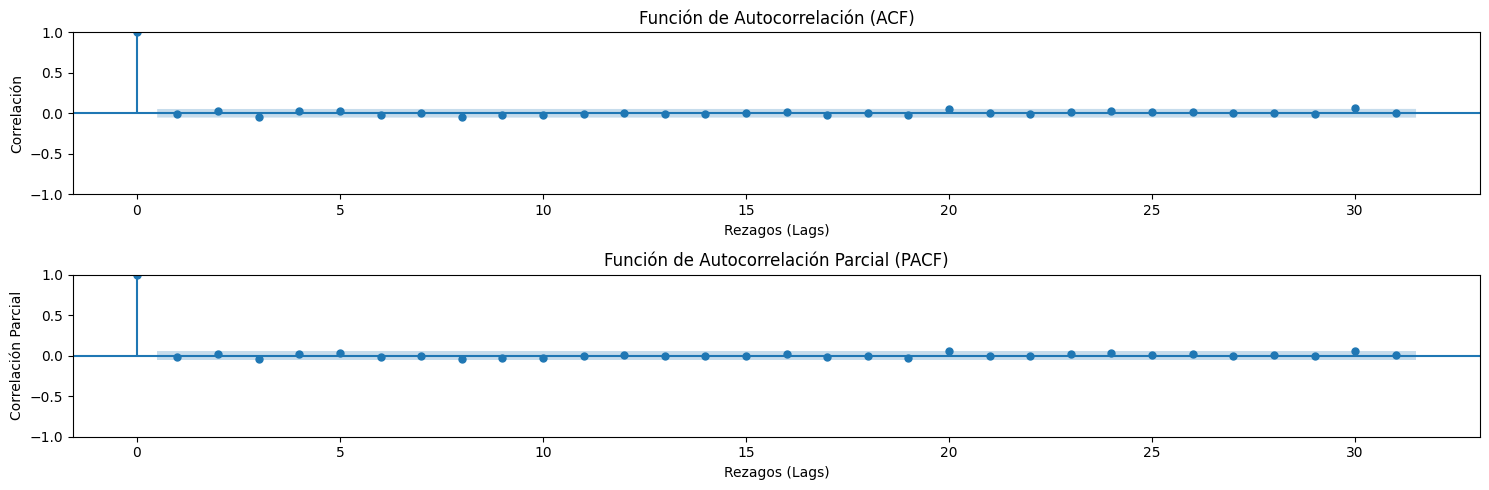


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 20, 30]
Rezagos significativos en PACF: [0, 20, 30]



In [48]:
for ticker in stocks:
  fig, axes = plt.subplots(2, 1, figsize=(15, 5))

  #Gráfico de Autocorrelación (ACF)
  plot_acf(retornos_l[ticker], lags=31, ax=axes[0], title="Función de Autocorrelación (ACF)")
  axes[0].set_xlabel("Rezagos (Lags)")
  axes[0].set_ylabel("Correlación")

  #Gráfico de Autocorrelación Parcial (PACF)
  plot_pacf(retornos_l[ticker], lags=31, ax=axes[1], title="Función de Autocorrelación Parcial (PACF)", method='ywm') # Usando 'ywm' (Yule-Walker modificado) para evitar advertencias en muestras pequeñas
  axes[1].set_xlabel("Rezagos (Lags)")
  axes[1].set_ylabel("Correlación Parcial")

  plt.tight_layout()
  print(f'{ticker.upper()}')
  plt.show()
  print('')

  #Número de rezagos (lags) a calcular
  n_lags = 31

  #Calcular ACF
  valores_acf = acf(retornos_l[ticker], nlags=n_lags, fft=True)

  #Calcular PACF
  valores_pacf = pacf(retornos_l[ticker], nlags=n_lags, method='ywm')# Usamos 'ywm' (Yule-Walker modificado) para consistencia con los gráficos estándar

  #Organizar los resultados en una tabla
  df_correlograma = pd.DataFrame({
      'Rezago (Lag)': range(0, n_lags + 1),
      'ACF': valores_acf,
      'PACF': valores_pacf
  })

  #Configurar el rezago como el índice del DataFrame
  df_correlograma.set_index('Rezago (Lag)', inplace=True)

  #Identificar límite crítico
  N = len(retornos_l[ticker])
  limite_critico = 1.96 / np.sqrt(N)
  print(f"Límite crítico de significancia (95%): +/- {limite_critico:.4f}")

  #Filtrar rezagos que superan el límite (ignorando el rezago 0)
  rezagos_sig_acf = df_correlograma[df_correlograma['ACF'].abs() > limite_critico].index.tolist()
  print(f"Rezagos significativos en ACF: {rezagos_sig_acf}")
  rezagos_sig_pacf = df_correlograma[df_correlograma['PACF'].abs() > limite_critico].index.tolist()
  print(f"Rezagos significativos en PACF: {rezagos_sig_pacf}")
  print('')

- Los rendimientos de las acciones presentan propiedades estadísticas compatibles con una serie estacionaria y existe evidencia de dependencia temporal en algunos rezagos.

- ACF y PACF no presentan una estructura extremadamente clara de bajo orden, ya que la mayoría de las series muestran rezagos co correlación bastante altos, lo cual puede señalar características como estructura temporal débil, efectos de mercado o incluso ruido estadístico.

##Modelo ARIMA

Por medio de un modelo ARIMA se intentará capturar la dependencia en la media que presentan los rendimientos y así poder generar pronósticos de rendimientos en base a la memoria guardada en la serie de tiempo.

El modelo se define mediante tres parámetros básicos:
- p (Autorregresivo - AR): Mide la relación entre el valor actual y los valores pasados (rezagos). Utiliza la historia reciente para predecir el futuro.
- d (Integrado - I): Representa el número de veces que se deben restar los datos (diferenciación) para que la serie sea estacionaria (es decir, que su promedio y su variación no cambien con el tiempo).
- q (Media Móvil - MA): Mide la relación entre el valor actual y los errores de pronóstico cometidos en los periodos anteriores.

Debido a que las cinco series de tiempo obtuvieron resultados estadísticos consistentes en las pruebas de estacionariead, los parámetros de los modelos a construir se serán de la forma: ARIMA(p,0,q)


###Estimación de modelos

Debido a que los gráficos ACF/PACF no presentan el patrón *"de libro"* de un ARIMA sencillo, ya que hay varios rezagos alejados del 1, no conviene convertir mecánicamente cada rezago significativo en p o q, debido a que esta metodología produciría modelos innecesariamente complejos. Es por ello que se optará con probar con un rango de rezagos moderados desde el 0 hasta el 4, tanto para el parámetro p como para el parámetro q, lo cual nos aportará 25 combinaciones de modelos para comparar entre sí.

Los modelos se evaluarán en base a los estadísticos Log-Likelihod, AIC, BIC y HQIC.

**Nota:** El criterio para cada uno de los estadísticos es el siguiente:
- Log-Likelihood → mayor es mejor
- AIC → menor es mejor
- BIC → menor es mejor
- HQIC → menor es mejor

Cabe aclarar que para atender casos de inconsistencias entre criterios, la jerarquía de los estadísticos define a AIC como el de mayor importancia, seguido por Log-Likelihood.

In [49]:
#Estimación de modelos ARIMA
resultados_arima = []

for ticker in stocks:

    serie = retornos_l[ticker]

    for p in range(5):
        for q in range(5):

            try:

                modelo = ARIMA(
                    serie,
                    order=(p, 0, q)
                )

                resultado = modelo.fit()

                resultados_arima.append({
                    "Ticker": ticker,
                    "p": p,
                    "d": 0,
                    "q": q,
                    "Log-Likelihood": resultado.llf,
                    "AIC": resultado.aic,
                    "BIC": resultado.bic,
                    "HQIC": resultado.hqic
                })

            except Exception as e:
                print(f"Error en {ticker} ARIMA({p},0,{q}): {e}")

comparacion_arima = pd.DataFrame(resultados_arima)
comparacion_arima.sort_values(["Ticker", "AIC"]).groupby("Ticker").head(5)

,Ticker,p,d,q,Log-Likelihood,AIC,BIC,HQIC
0,coin,0,0,0,2068.641097,-4133.282195,-4122.845841,-4129.375785
5,coin,1,0,0,2068.648113,-4131.296225,-4115.641695,-4125.436611
1,coin,0,0,1,2068.647920,-4131.295840,-4115.641309,-4125.436225
2,coin,0,0,2,2068.797288,-4129.594576,-4108.721868,-4121.781757
10,coin,2,0,0,2068.783371,-4129.566742,-4108.694034,-4121.753922
25,goog,0,0,0,3430.636264,-6857.272529,-6846.836175,-6853.366119
26,goog,0,0,1,3430.695119,-6855.390239,-6839.735708,-6849.530624
30,goog,1,0,0,3430.693561,-6855.387123,-6839.732592,-6849.527508
28,goog,0,0,3,3432.660394,-6855.320789,-6829.229904,-6845.554765
40,goog,3,0,0,3432.599233,-6855.198466,-6829.107582,-6845.432442


En el caso de COIN, GOOG, PPTA y UAL, el modelo (0,0,0) tiene el mejor AIC, BIC y HQIC dentro de los candidatos mostrados, lo cual puede arrojar la conclusión de que el modelo ARIMA parece aportar muy poca estructura a la media. Esto es bastante razonable para rendimientos financieros, debido a que los rendimientos diarios suelen presentar poca autocorrelación lineal en su media.



El caso de SOXX es diferente, ya que el mejor modelo resulta ser (0,0,4) mientras que el modelo sin rezagos específicos ni siquiera figura entre los mejores cinco, por lo cual parece contener algo más de estructura temporal en la media.

###ACF/PACF de los residuos

A pesar de contar con los cinco modelos con los mejores valores en Log-Likelihood, AIC, BIC y HQIC, antes de seleccionar un modelo ideal para pronosticar, hay que filtrar cuales de los modelos presentan *"Ruido Blanco"* en la corelación de sus residuos.

A continuación, se realizará dicha evaluación de los residuos por medio de ACF/PACF.

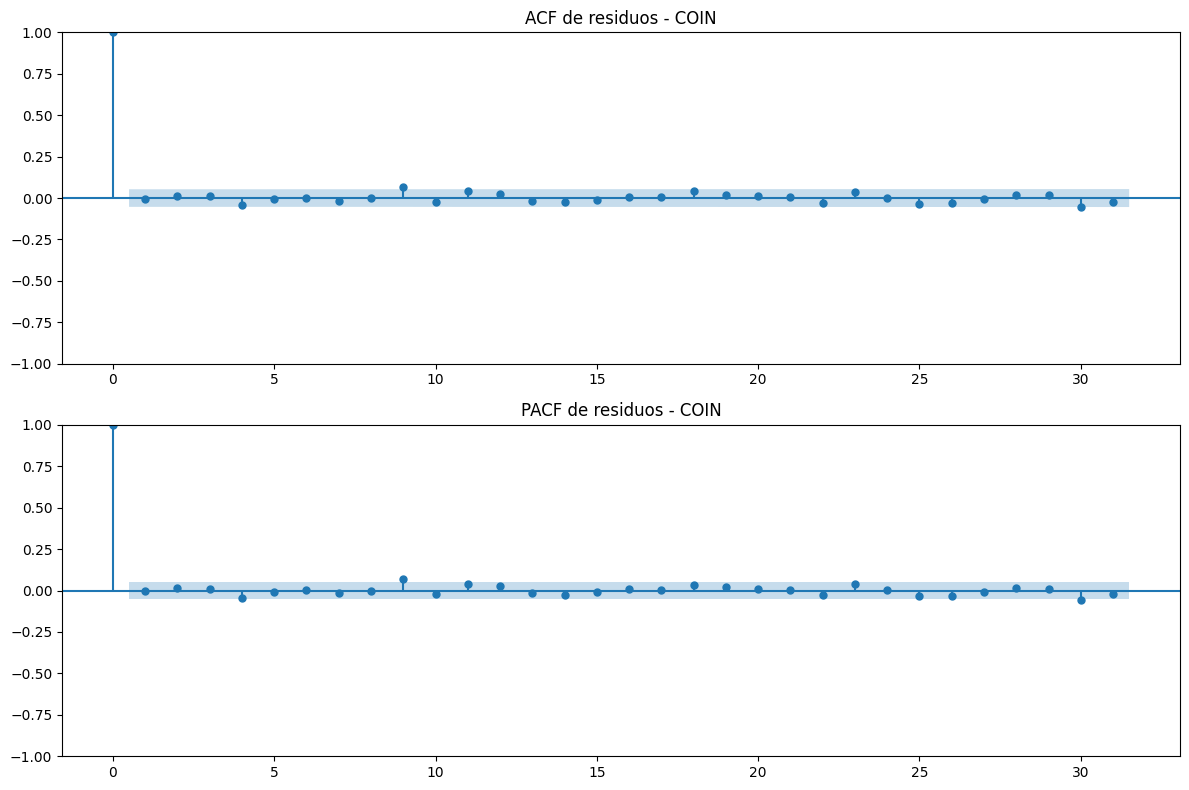


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 9]
Rezagos significativos en PACF: [0, 9, 30]



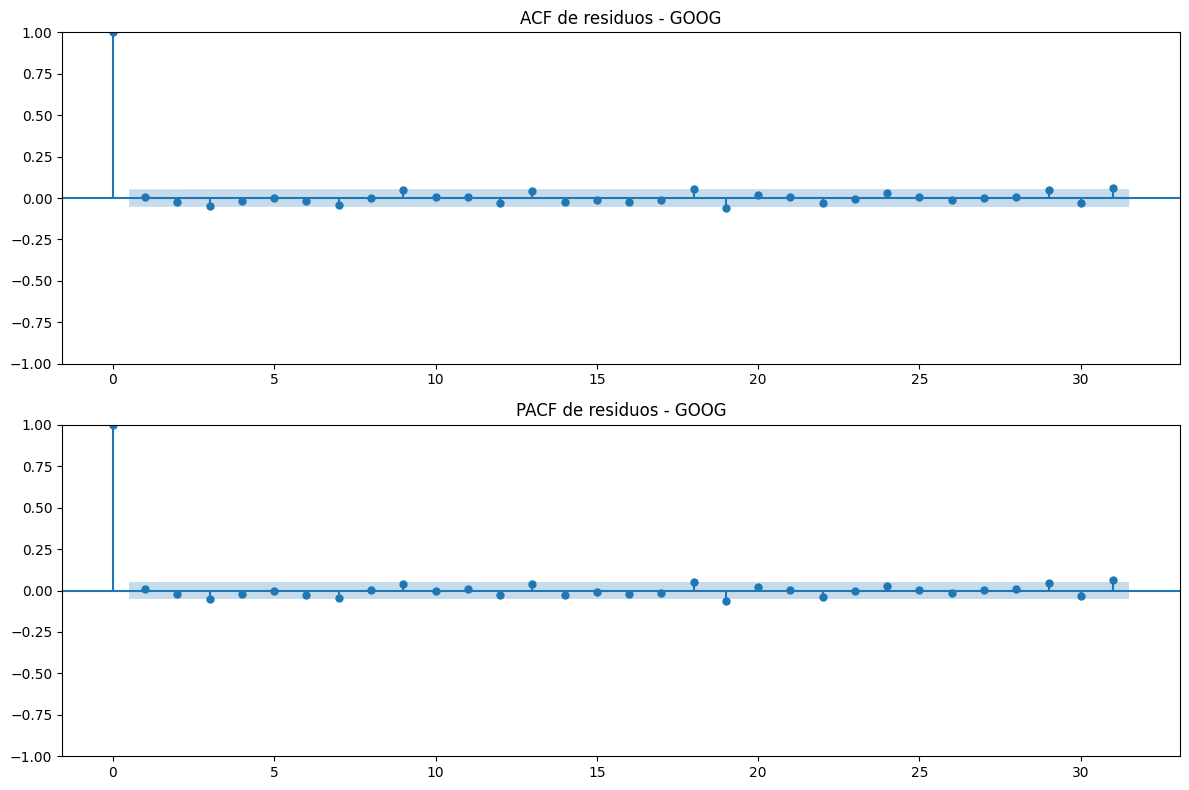


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 18, 19, 31]
Rezagos significativos en PACF: [0, 19, 31]



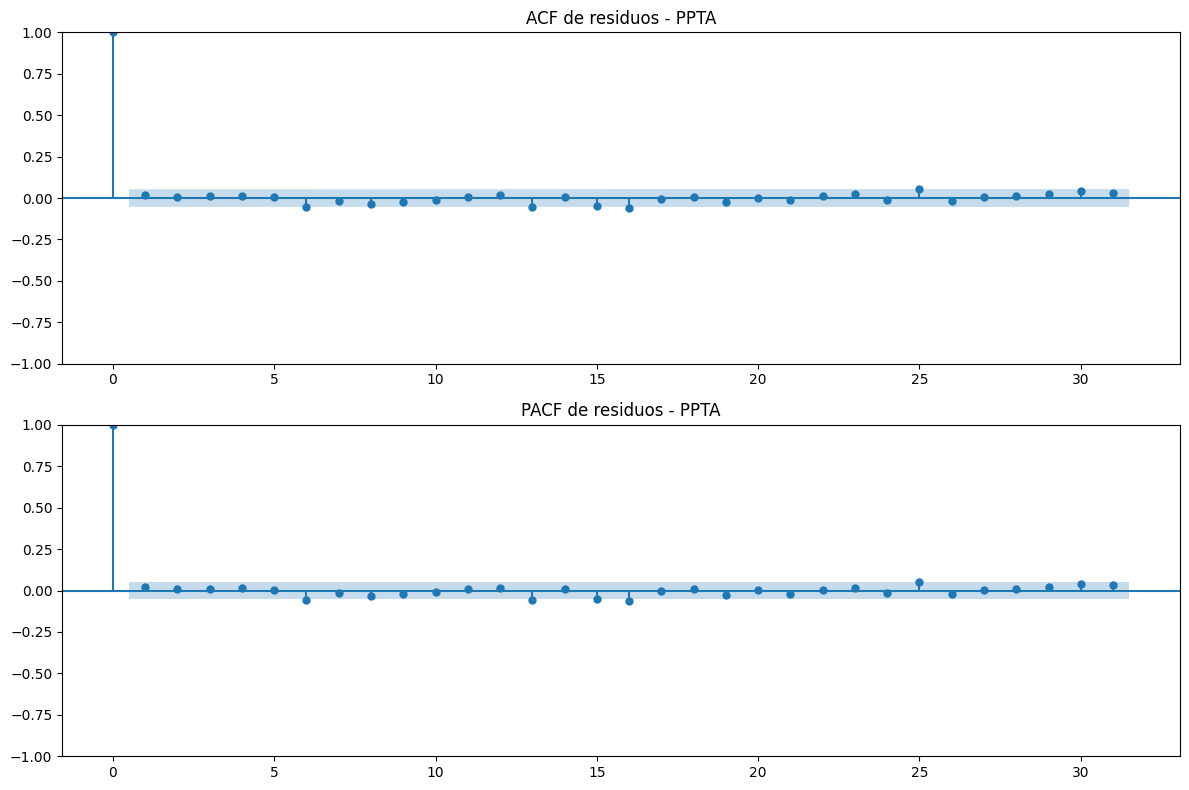


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 6, 13, 16, 25]
Rezagos significativos en PACF: [0, 6, 13, 16, 25]



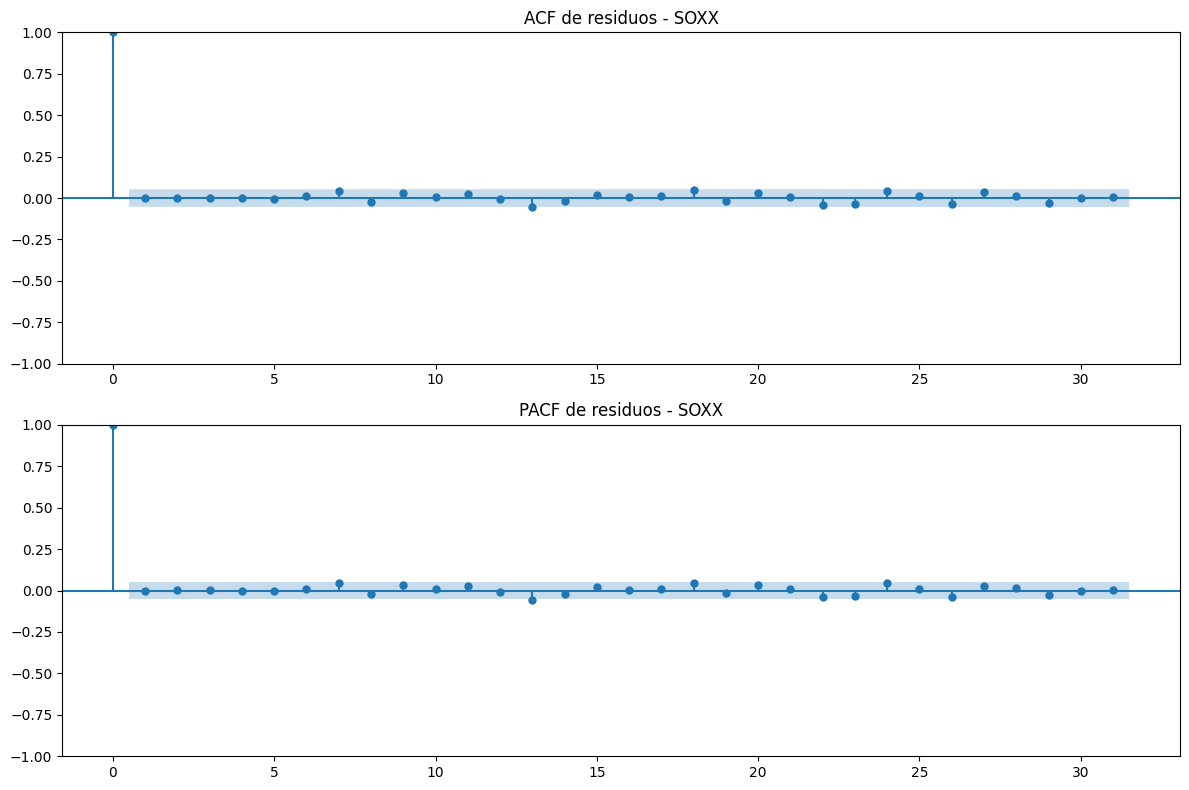


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 13]
Rezagos significativos en PACF: [0, 13]



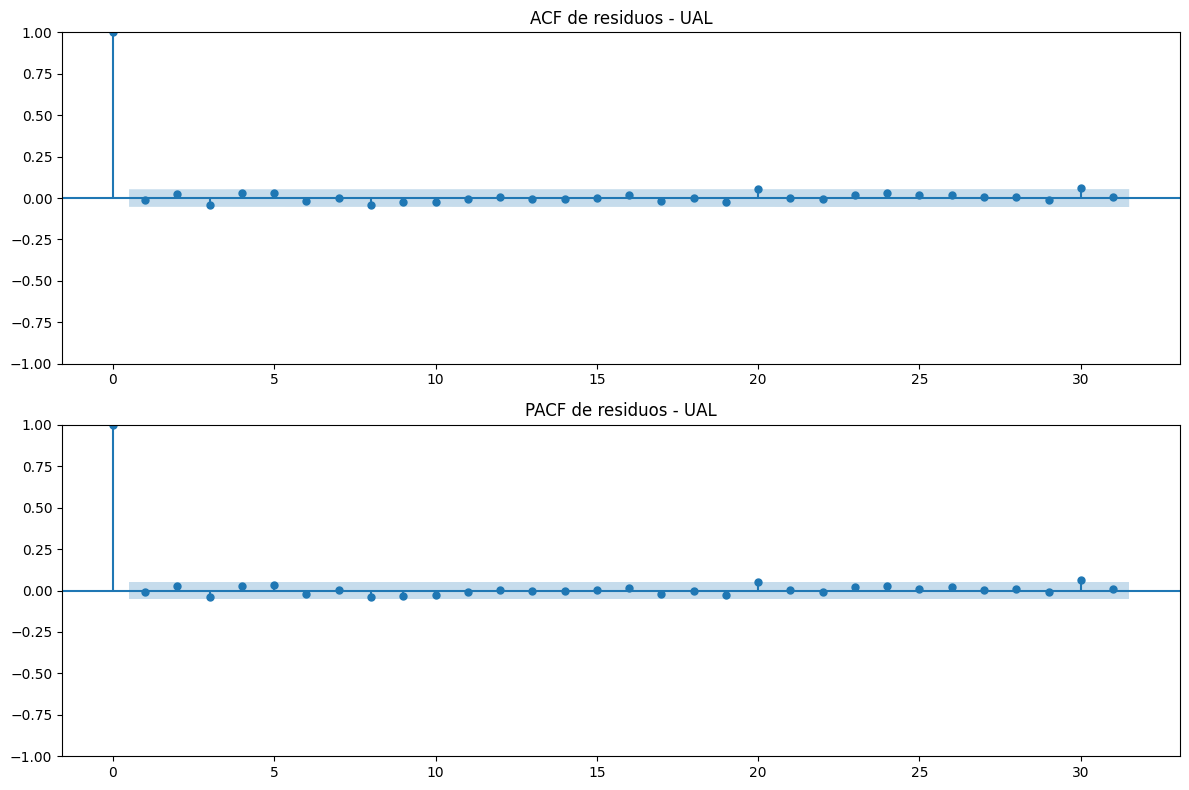


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 20, 30]
Rezagos significativos en PACF: [0, 20, 30]



In [50]:
#Lista de modelos con mejor valor AIC
modelos_seleccionados = {
    "coin": (0, 0, 0),
    "goog": (0, 0, 0),
    "ppta": (0, 0, 0),
    "soxx": (0, 0, 4),
    "ual": (0, 0, 0)
}

resultados_modelos = {}

#Generación de los modelos seleccionados
for ticker, orden in modelos_seleccionados.items():

    modelo = ARIMA(retornos_l[ticker],order=orden)

    resultado = modelo.fit()

    resultados_modelos[ticker] = resultado

#ACF/PACF de los residuos de cada modelo
for ticker, resultado in resultados_modelos.items():

    residuos = resultado.resid

    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    # ACF de los residuos
    plot_acf(
        residuos,
        lags=31,
        ax=ax[0]
    )

    ax[0].set_title(f"ACF de residuos - {ticker.upper()}")

    # PACF de los residuos
    plot_pacf(
        residuos,
        lags=31,
        ax=ax[1],
        method="ywm"
    )

    ax[1].set_title(f"PACF de residuos - {ticker.upper()}")

    plt.tight_layout()
    plt.show()
    print('')

    #Número de rezagos (lags) a calcular
    n_lags = 31

    # Calcular ACF
    valores_acf = acf(residuos, nlags=n_lags, fft=True)

    # Calcular PACF
    valores_pacf = pacf(residuos, nlags=n_lags, method='ywm')

    #Organizar los resultados en una tabla
    df_correlograma = pd.DataFrame({
        'Rezago (Lag)': range(0, n_lags + 1),
        'ACF': valores_acf,
        'PACF': valores_pacf
    })

    #Configurar el rezago como el índice del DataFrame
    df_correlograma.set_index('Rezago (Lag)', inplace=True)

    #Identificar límite crítico
    N = len(residuos)
    limite_critico = 1.96 / np.sqrt(N)
    print(f"Límite crítico de significancia (95%): +/- {limite_critico:.4f}")

    #Filtrar rezagos que superan el límite (ignorando el rezago 0)
    rezagos_sig_acf = df_correlograma[df_correlograma['ACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en ACF: {rezagos_sig_acf}")
    rezagos_sig_pacf = df_correlograma[df_correlograma['PACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en PACF: {rezagos_sig_pacf}")
    print('')

Nuevamente ACF/PACF muestra correlación por encima del nivel de confianza en los mismos rezagos que se mostraron al evaluar las series de rendimientos utilizadas para construir el modelo ARIMA.

Al ser nuevamente rezagos muy alejados del primero, se debe de corroborar la presencia de autocorrelación no capturada en el modelo por medio de una prueba Ljung-Box aplicada a los residuos.

###Prueba Ljung-Box de los residuos

Con la prueba estadística de Ljung-Box se pretende evaluar los rezagos de los residuos del modelo, y evaluar la captura de autocorrelación de modelo por medio del valor p de la prueba para cada rezago.

H0: los residuos no presentan autocorrelación conjunta

H1: existe autocorrelación

Nivel de significancia: 0.05

**Nota:** se ha optado por tomar los horizontes de 10, 20 y 31 rezagos como puntos de control para cubrir corto, medio y relativamente largo plazo. Esto es con la finalidad de identificar si el modelo elimina la autocorrelación residual en el corto plazo, pero conservando dependencia sin capturar en el largo plazo.

In [51]:
for ticker, resultado in resultados_modelos.items():

    residuos = resultado.resid

    prueba = acorr_ljungbox(
        residuos,
        lags=[10, 20, 31],
        return_df=True
    )

    print(f"\n{ticker.upper()}")
    print(prueba)


COIN
      lb_stat  lb_pvalue
10  10.461925   0.400943
20  19.057341   0.518102
31  30.817459   0.475438

GOOG
      lb_stat  lb_pvalue
10  10.241641   0.419555
20  24.941125   0.203693
31  37.620513   0.191920

PPTA
      lb_stat  lb_pvalue
10   8.294240   0.600120
20  21.579264   0.363770
31  32.660245   0.385286

SOXX
      lb_stat  lb_pvalue
10   5.197140   0.877626
20  16.919724   0.658180
31  29.095245   0.564273

UAL
      lb_stat  lb_pvalue
10  10.581387   0.391047
20  17.165686   0.642190
31  25.074802   0.764361


Los resultados de la prueba concluyen que no encontramos evidencia suficiente de autocorrelación conjunta en los horizontes evaluados. En rezagos del 1-10, 1-20 y 1-31 el valor p muestra un valor por encima del nivel de significancia de 0.05, por lo cual no se rechaza la hipótesis nula.

Dado que los modelos han demostrado representar la media de los rendimientos correctamente, han capturado la autocorrelación en las series de tiempo, y además muestran valores de AIC y Log-Likelihood menores al resto de modelos generados, se ha decidido proceder con estos modelos para la realización de pronósticos en fases posteriores.

##Modelo GARCH

Después de comprobar que la media está correctamente modelada, ahora se deben de evaluar los residuos cuadrados por medio de modelos de la familia ARCH/GARCH.

El modelo GARCH (Heteroscedasticidad Condicional Autorregresiva Generalizada) es un método estadístico que sirve para predecir y modelar la volatilidad cambiante en series de tiempo financieras y económicas.

Parámetros:
- ω (Omega): El término constante o sesgo base de la varianza a largo plazo.
- α (Alfa - componente ARCH): Mide la reacción de la volatilidad actual ante los shocks o sorpresas del mercado del período anterior (los errores al cuadrado rezagados, q).
- β (Beta - componente GARCH): Mide la persistencia de la volatilidad, es decir, cuánto influye la volatilidad del período pasado (p) en la volatilidad actual.

Para identificar los parámetros utilizados en cada modelo candidato tómese como referencia la forma GARCH(p,q).

Aunque previamente se identificó visualmente que existe clustering de volatilidad en la serie de rendimientos, lo correcto es corroborar formalmente si la varianza depende del pasado, es decir, si existe efecto ARCH.




###ACF/PACF de los residuos al cuadrado

Si los residuos originales no presentan autocorrelación (cosa que se confirmó con la prueba anterior), pero sus cuadrados sí, tendremos evidencia de que los shocks de volatilidad tienden a agruparse en el tiempo. Eso sería justamente lo que buscamos antes de estimar GARCH.

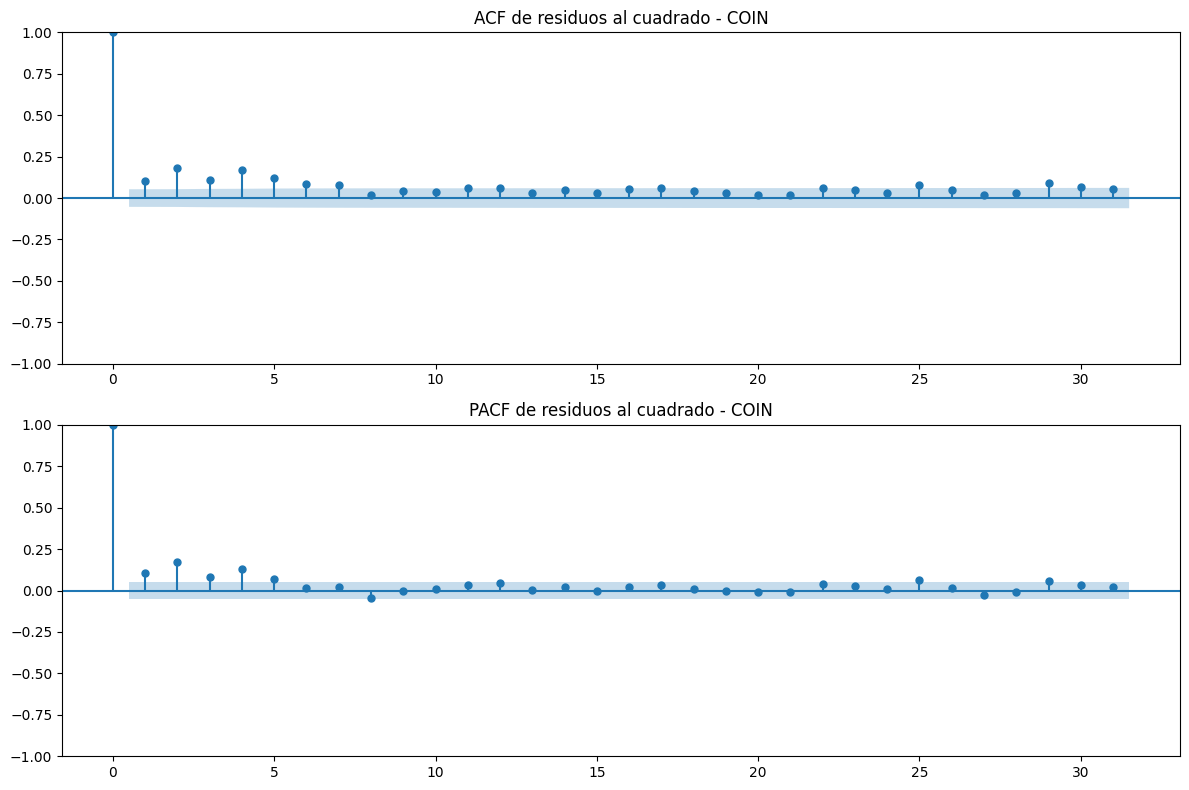


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 1, 2, 3, 4, 5, 6, 7, 11, 12, 16, 17, 22, 25, 29, 30]
Rezagos significativos en PACF: [0, 1, 2, 3, 4, 5, 25, 29]



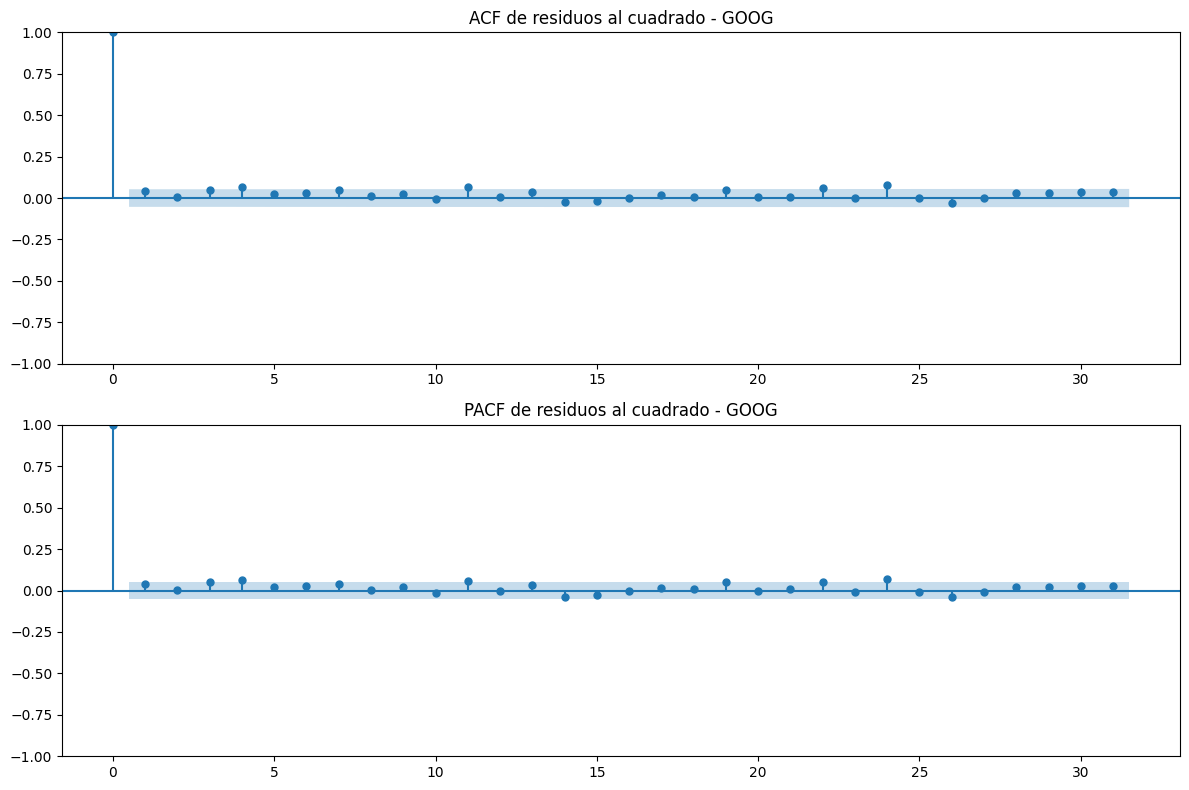


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 4, 11, 22, 24]
Rezagos significativos en PACF: [0, 4, 11, 24]



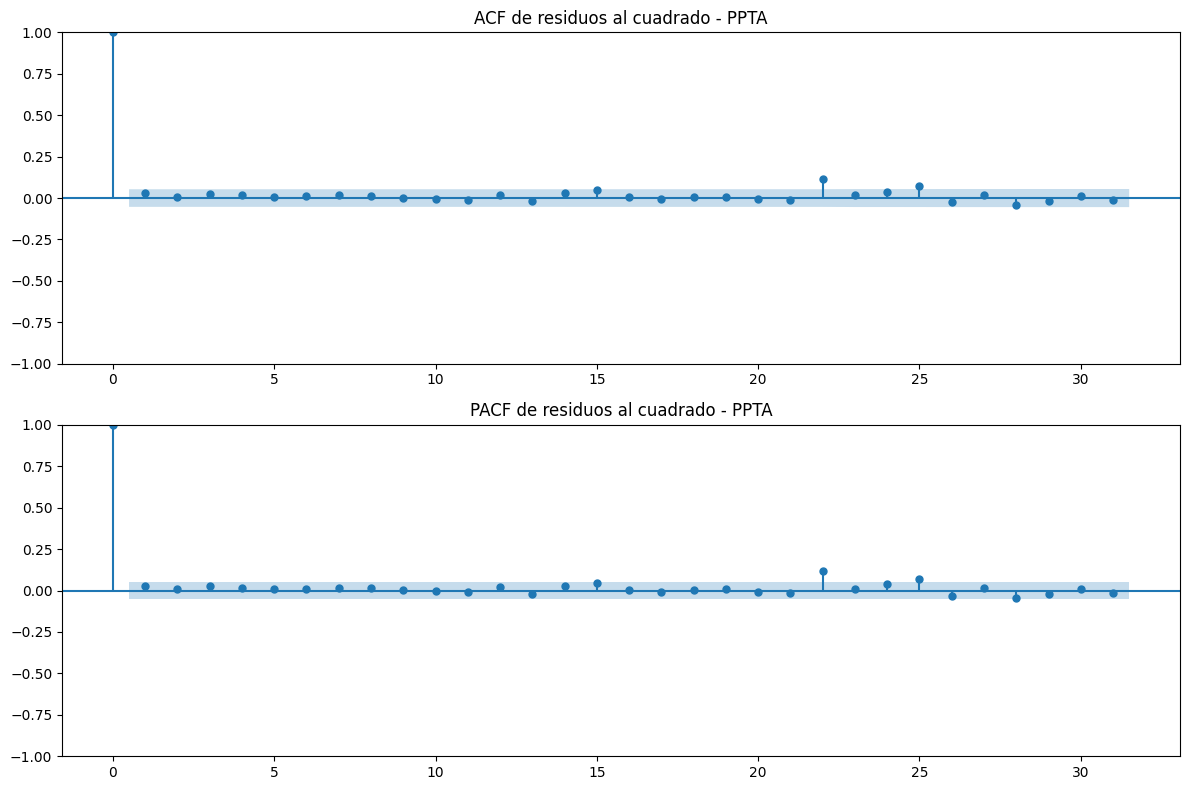


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 22, 25]
Rezagos significativos en PACF: [0, 22, 25]



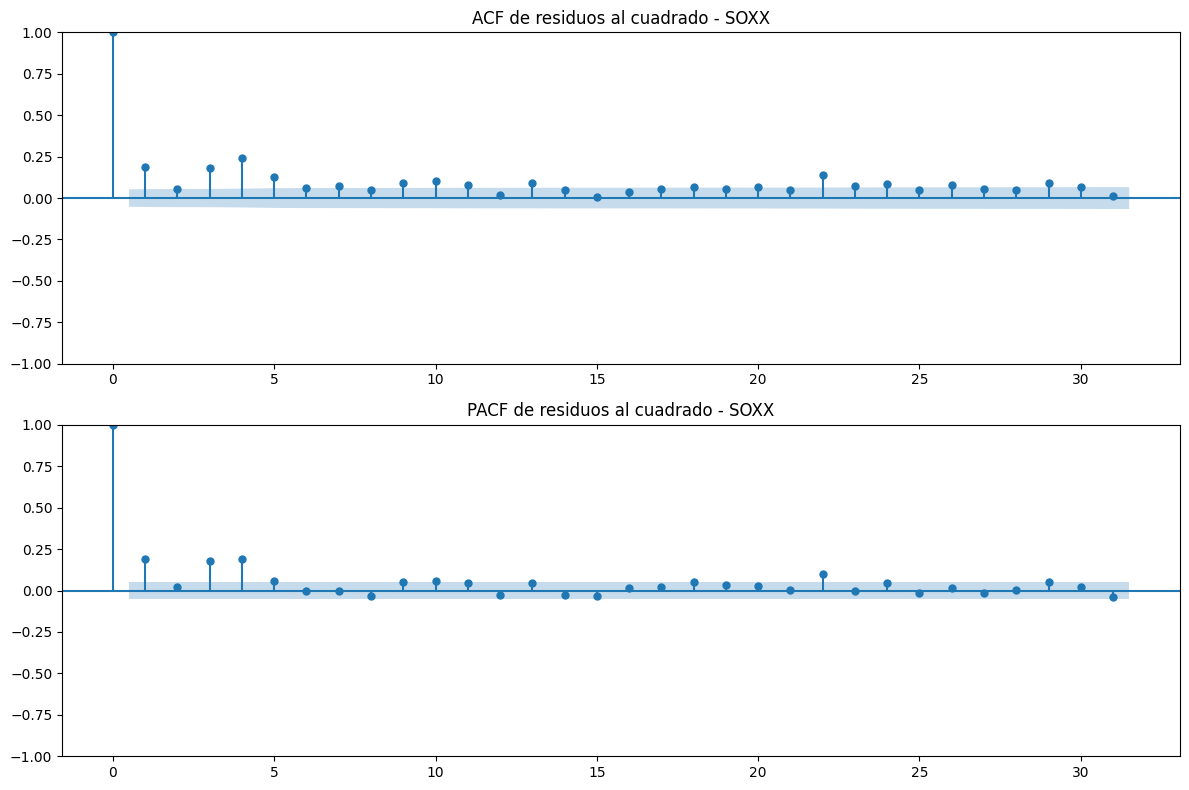


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 17, 18, 20, 22, 23, 24, 26, 27, 29, 30]
Rezagos significativos en PACF: [0, 1, 3, 4, 5, 10, 22]



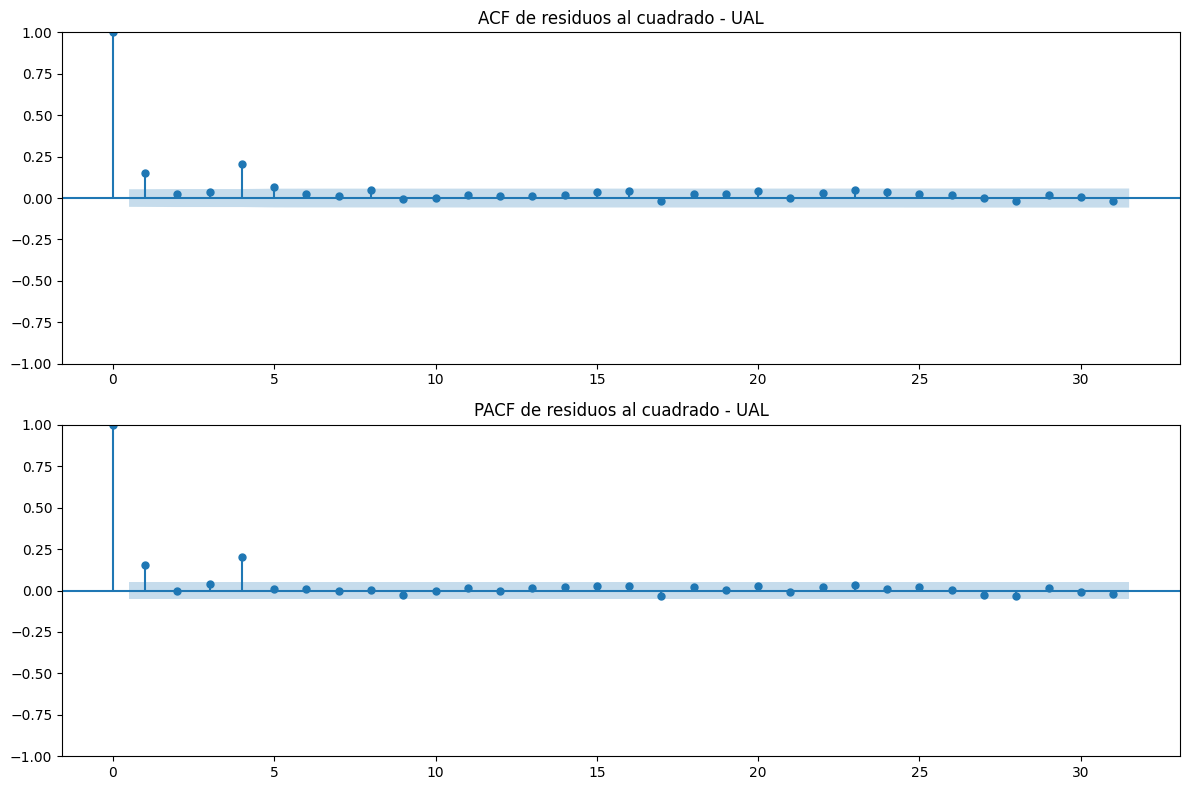


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 1, 4, 5]
Rezagos significativos en PACF: [0, 1, 4]



In [52]:
#Cálculo de residuos al cuadrado
residuos_cuadrados = {}

for ticker, resultado in resultados_modelos.items():
    residuos = resultado.resid.dropna()
    residuos_cuadrados[ticker] = residuos ** 2

for ticker, residuos_sq in residuos_cuadrados.items():

    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    #ACF de residuos al cuadrado
    plot_acf(
        residuos_sq,
        lags=31,
        ax=ax[0]
    )

    ax[0].set_title(
        f"ACF de residuos al cuadrado - {ticker.upper()}"
    )

    #PACF de residuos al cuadrado
    plot_pacf(
        residuos_sq,
        lags=31,
        ax=ax[1],
        method="ywm"
    )

    ax[1].set_title(
        f"PACF de residuos al cuadrado - {ticker.upper()}"
    )

    plt.tight_layout()
    plt.show()
    print('')

    #Rezagos por encima del nivel de confianza

    #Número de rezagos (lags) a calcular
    n_lags = 31

    #Calcular ACF
    valores_acf = acf(residuos_sq, nlags=n_lags, fft=True)

    #Calcular PACF
    valores_pacf = pacf(residuos_sq, nlags=n_lags, method='ywm')

    #Organizar los resultados en una tabla
    df_correlograma = pd.DataFrame({
        'Rezago (Lag)': range(0, n_lags + 1),
        'ACF': valores_acf,
        'PACF': valores_pacf
    })

    #Configurar el rezago como el índice del DataFrame
    df_correlograma.set_index('Rezago (Lag)', inplace=True)

    #Identificar límite crítico
    N = len(residuos_sq)
    limite_critico = 1.96 / np.sqrt(N)
    print(f"Límite crítico de significancia (95%): +/- {limite_critico:.4f}")

    #Filtrar rezagos que superan el límite (ignorando el rezago 0)
    rezagos_sig_acf = df_correlograma[df_correlograma['ACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en ACF: {rezagos_sig_acf}")
    rezagos_sig_pacf = df_correlograma[df_correlograma['PACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en PACF: {rezagos_sig_pacf}")
    print('')

Los gráficos muestran autocorrelación en múltiples rezagos de todas las series de residuos al cuadrado, lo que significa que la magnitud de los shocks pasados contiene información sobre la magnitud de los shocks futuros.

Este resultado indica dependencia en la volatilidad, lo cual es consistente con la naturaleza de este fenómeno.

###Prueba Ljung-Box de los residuos al cuadrado

H0: los residuos no presentan autocorrelación conjunta

H1: existe autocorrelación

Nivel de significancia: 0.05

In [53]:
#Prueba Ljung-Box
ljung_box_arch = {}

for ticker, residuos_sq in residuos_cuadrados.items():

    prueba = acorr_ljungbox(
        residuos_sq,
        lags=[10, 20, 31],
        return_df=True
    )

    ljung_box_arch[ticker] = prueba

    print(f"\n{ticker.upper()}")
    print(prueba)


COIN
       lb_stat     lb_pvalue
10  160.360031  2.730541e-29
20  190.419865  8.746641e-30
31  234.532229  4.044634e-33

GOOG
      lb_stat  lb_pvalue
10  18.318593   0.049821
20  31.028187   0.054819
31  52.158656   0.010079

PPTA
      lb_stat  lb_pvalue
10   3.670341   0.960996
20   9.450495   0.977078
31  42.573291   0.080593

SOXX
       lb_stat     lb_pvalue
10  244.366409  8.292336e-47
20  290.382729  7.404222e-50
31  374.266687  1.531778e-60

UAL
       lb_stat     lb_pvalue
10  104.470782  6.918157e-18
20  114.218519  3.320693e-15
31  123.367070  5.721392e-13


En el caso de COIN, SOXX y UAL los residuos al cuadrado muestran autocorrelación en los tres horizontes, lo que indica una alta dependencia de la volatilidad pasada sobre la volatilidad presente.

Para GOOG la prueba confirma autocorrelación en los rezagos 1-10 y 1-31, pero no rechaza la hipótesis nula de la prueba en el rango de 1-20.

Los resultados de PPTA son los más destacados, ya que no rechaza la hipótesis nula en ninguno de los horizontes al nivel de significancia del 0.05, lo que significa que no queda autocorrelación por capturar hacia la media.

###Prueba ARCH-LM (Engle)

A pesar de ser uno de los activos que mejor mostraba clustering de volatilidad en el gráfico de rendimientos, los resultados para la acción PPTA sonfirman que el observar clustering de volatilidad en una gráfica no necesariamente implica que exista heterocedasticidad condicional estadísticamente significativa.

Puede haber episodios visualmente muy volátiles sin que exista suficiente dependencia temporal sistemática en la varianza como para que un GARCH sea claramente necesario.

Antes de decidir si PPTA necesita GARCH, se hará una prueba formal de efectos ARCH.

La prueba ARCH-LM (Engle) contrasta si la varianza de los residuos depende de sus propios valores pasados.

H0: No existe efecto ARCH.

H1: Existe heterocedasticidad condicional.

In [54]:
#Cálculo de la prueba ARCH-LM (Engle)
resultados_arch = []

for ticker, resultado in resultados_modelos.items():

    residuos = resultado.resid.dropna()

    for lag in [10, 20, 31]:

        lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
            residuos,
            nlags=lag
        )

        resultados_arch.append({
            "Ticker": ticker.upper(),
            "Lag": lag,
            "LM Statistic": lm_stat,
            "LM p-value": lm_pvalue,
            "F Statistic": f_stat,
            "F p-value": f_pvalue
        })

tabla_arch = pd.DataFrame(resultados_arch)

tabla_arch

,Ticker,Lag,LM Statistic,LM p-value,F Statistic,F p-value
0,COIN,10,95.153880,5.061050e-16,10.151492,1.276995e-16
1,COIN,20,101.910528,5.723387e-13,5.427452,1.568880e-13
2,COIN,31,116.448754,8.015666e-12,4.017168,1.897658e-12
3,GOOG,10,15.272197,1.224487e-01,1.532093,1.221992e-01
4,GOOG,20,27.343441,1.258751e-01,1.373759,1.249552e-01
5,GOOG,31,42.760186,7.776067e-02,1.390864,7.586909e-02
6,PPTA,10,3.168246,9.771827e-01,0.314988,9.775226e-01
7,PPTA,20,8.690837,9.862193e-01,0.430536,9.867037e-01
8,PPTA,31,40.124493,1.262568e-01,1.302472,1.245068e-01
9,SOXX,10,147.466757,1.236866e-26,16.414621,2.991010e-28


**Nota:** La función het_arch se encarga de transformar los residuos a cuadrados internamente, por lo cual no es necesario elevaarlos al cuadrado.

Los resultados de la prueba confirman hetecedasticidad condicional en los residuos de los cinco activos, por lo cual si existe un efecto ARCH que es necesario modelar.

###Estimación de modelos (base)

El modelo ARIMA captura adecuadamente la dinámica lineal de la media de los rendimientos en las cinco series financieras, mientras que la presencia de autocorrelación en los residuos al cuadrado en cuatro de las series sugiere heterocedasticidad condicional, justificando la incorporación de un modelo GARCH para modelar la volatilidad en los casos correspondientes.

Los valores a considerar para evaluar de primera vista un modelo son α1+β1, ya que ambos coeficientes representan en conjunto:
- α1: reacción de la volatilidad ante nuevos shocks.
- β1: persistencia de la volatilidad.

El valor de su suma es mejor entre más cercano a 1 se encuentre, ya que implica que la memoria de la volatilidad persiste más tiempo ante un shock.

Como ya modelamos la media mediante ARIMA y estamos utilizando sus residuos, podemos comenzar el GARCH con media cero y con un rezago tanto para

In [56]:
#Generación de modelos GARCH base
modelos_garch = {}

for ticker, resultado in resultados_modelos.items():

    residuos = resultado.resid.dropna()

    # Escalamos a porcentaje para mejorar la estabilidad numérica
    residuos_pct = residuos * 100

    modelo = arch_model(
        residuos_pct,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )

    resultado_garch = modelo.fit(disp="off")

    modelos_garch[ticker] = resultado_garch

    print(f"\n{'='*60}")
    print(f"GARCH(1,1) - {ticker.upper()}")
    print(f"{'='*60}")
    print(resultado_garch.summary())


GARCH(1,1) - COIN
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -4153.93
Distribution:                  Normal   AIC:                           8313.87
Method:            Maximum Likelihood   BIC:                           8329.52
                                        No. Observations:                 1364
Date:                Fri, Oct 02 2026   Df Residuals:                     1364
Time:                        01:03:54   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.7898      0.860      0.91

**Nota:**
- H0: El parámetro no es estadísticamente significativo.
- H1: El parámetro es estadísticamente significativo.

- α1: reacción de la volatilidad ante nuevos shocks.
- β1: persistencia de la volatilidad.



Para estos primeros modelos base se consideraron los siguientes parámetros:
- Media cero (ya que los residuos provienen de un modelo ARIMA que ya ha logrado capturar la media de la serie).
- Distribución normal de los errores (posteriormente se comparará con modelos de distribución t-student).
- p = 1 (en el término GARCH se tomó en cuenta 1 período anterior de la varianza).
- q = 1 (en el término ARCH se tomó en cuenta 1 periódo anterior del error al cuadrado).

Para las cinco series el coeficiente beta es mucho mayor al coeficiente alpha, lo cual indica que la volatilidad está dominada principalmente por persistencia de la volatilidad pasada, más que por la reacción inmediata a nuevos shocks.

En GOOG y PPTA vemos un valor conjunto de α y β muy cercano a 1, indicando una volatilidad que puede mantenerse durante bastante tiempo.

El caso de PPTA es particularmente interesante porque anteriormente no encontramos evidencia significativa de autocorrelación en los residuos cuadrados mediante Ljung-Box. Eso si, un β elevado no demuestra por sí mismo que GARCH sea necesario.

SOXX y UAL muestran valores p para alpha y beta por debajo del nivel de significancia, lo que significa que ambos componentes son estadísticamente significativos. Sin embargo, en el caso de COIN, GOOG y PPTA, se observa que unicamente beta es relevante, mientras que alpha no es estadísticamente relevante.

Al hacer este análisis preeliminar se puede ir observando qué series han funcionado de forma correcta con una cantidad mínima de rezagos sin necesidad de sobreestimar el modelo, y otras que aún no logran capturar el impacto de los shocks de volatilidad.

Es por ello que el siguiente paso será estimar múltiples candidatos con distintas combinaciones de parámetros, y se compararán nuevamente con los criterios:
- Log-Likelihood → mayor es mejor
- AIC → menor es mejor
- BIC → menor es mejor

(En este caso no se cuenta con HQIC debido a que la función arch_model de la librería arch no incluye este criterio)

Idealmente queremos que después de GARCH:
- Los residuos estandarizados no presenten autocorrelación.
- Los residuos al cuadrado tampoco presenten autocorrelación.
- No quede evidencia de efectos ARCH.



###Estimación de modelos (primera ronda)

In [57]:
#Modelos GARCH con nuevas configuraciones de rezagos
ordenes_garch = [(1, 1),(1, 2),(2, 1),(2, 2)]

resultados_comparacion_garch = []

for ticker, resultado_arima in resultados_modelos.items():

    residuos = resultado_arima.resid.dropna() * 100

    for p, q in ordenes_garch:

        modelo = arch_model(residuos,mean="Zero",vol="GARCH",p=p,q=q,dist="normal")

        resultado = modelo.fit(disp="off")

        resultados_comparacion_garch.append({
            "Ticker": ticker.upper(),
            "p": p,
            "q": q,
            "Log-Likelihood": resultado.loglikelihood,
            "AIC": resultado.aic,
            "BIC": resultado.bic
        })

#Tabla de comparación de modelos
comparacion_garch = pd.DataFrame(resultados_comparacion_garch)
comparacion_garch.sort_values(["Ticker", "AIC"])

,Ticker,p,q,Log-Likelihood,AIC,BIC
2,COIN,2,1,-4152.612318,8313.224636,8334.097344
3,COIN,2,2,-4151.691755,8313.383510,8339.474394
0,COIN,1,1,-4153.933953,8313.867905,8329.522436
1,COIN,1,2,-4153.933952,8315.867904,8336.740612
5,GOOG,1,2,-2822.991119,5653.982238,5674.854945
7,GOOG,2,2,-2822.991119,5655.982237,5682.073122
4,GOOG,1,1,-2824.994232,5655.988464,5671.642995
6,GOOG,2,1,-2824.994232,5657.988464,5678.861172
8,PPTA,1,1,-3958.920679,7923.841357,7939.495888
9,PPTA,1,2,-3958.084676,7924.169353,7945.042060


Los resultados para los modelos en SOXX y UAL son bastante positivos, ya que para ambos el modelo base GARCH(1,1) se muestra como el mejor entre el conjunto de modelos en base al valor de AIC, además de que previamente habían sido las únicas series en las que los valores de α y β son estadísticamente significativos con un modelo base.

En el caso de COIN y GOOG vemos que un modelo distinto al base resultó como el mejor en base a los criterios. Se debe de realizar una revisión de la relevancia de los componentes α y β antes de pasar a posteriores evaluaciones. Cabe destacar que en COIN, a pesar de que el modelo (2,1) posee el mejor valor AIC, este no saca mucha diferencia respecto al AIC de (2,2); además BIC lo penaliza sobre el resto debido a que agrega complejidad.

Para PPTA hará falta una estimación de modelos más robusta, ya que el mejor modelo entre el conjunto reultó ser modelo base, el cual ya se ha confirmado en el análisis anterior que α resulta no ser estadísticamente significativa. Esto no significa automáticamente que debamos descartar GARCH(1,1), pero sí que debemos investigar si una especificación GARCH simétrica es realmente apropiada.


In [58]:
#Revisión de mejores candidatos
modelos_finales = {"COIN": (2, 1),"GOOG": (1, 2),"PPTA": (1, 1),
                   "SOXX": (1, 1),"UAL": (1, 1)}

resultados_parametros = []
modelos_estimados = {}

for ticker, (p, q) in modelos_finales.items():

    residuos = resultados_modelos[ticker.lower()].resid.dropna() * 100

    modelo = arch_model(residuos,mean="Zero",vol="GARCH",p=p,q=q,dist="normal")

    resultado = modelo.fit(disp="off")

    modelos_estimados[ticker] = resultado

    for parametro in resultado.params.index:

        resultados_parametros.append({
            "Ticker": ticker,
            "Modelo": f"GARCH({p},{q})",
            "Parametro": parametro,
            "Coeficiente": resultado.params[parametro],
            "p-value": resultado.pvalues[parametro]
        })

tabla_parametros = pd.DataFrame(resultados_parametros)
tabla_parametros

,Ticker,Modelo,Parametro,Coeficiente,p-value
0,COIN,"GARCH(2,1)",omega,2.896531,2.169926e-01
1,COIN,"GARCH(2,1)",alpha[1],0.019042,5.814902e-01
2,COIN,"GARCH(2,1)",alpha[2],0.104166,2.042635e-01
3,COIN,"GARCH(2,1)",beta[1],0.774604,1.216328e-07
4,GOOG,"GARCH(1,2)",omega,0.054131,4.745222e-02
5,GOOG,"GARCH(1,2)",alpha[1],0.026065,4.025637e-02
6,GOOG,"GARCH(1,2)",beta[1],0.053012,1.444636e-01
7,GOOG,"GARCH(1,2)",beta[2],0.907885,2.919042e-124
8,PPTA,"GARCH(1,1)",omega,0.175776,7.706563e-01
9,PPTA,"GARCH(1,1)",alpha[1],0.010302,7.589924e-01


Para SOXX y para UAL los resultados nos demuestran que efectivamente el modelo con mejor ajuste y parsimonia cuenta con el factor a favor de que los componentes α y β son relevantes.

En COIN y GOOG se encuentra el mismo problema que se padeció en el modelo base, ya que mientras que en COIN ninguno de los dos rezagos de α es significativo, en GOOG el rezago β[1] no también mustra un valor p superior a 0.05.

Cabe destacar que el modelo (2,1) de COIN además drecrece en la persistencia de la volatilidad, ya que la suma de los coeficientes es de 0.8977, que es menor al 0.96 mostrado en el modelo (1,1).

PPTA no sorprende, ya que se vuelve a corroborar que el modelo base a pesar de tener el mejor ajuste y parsimonia, lo cierto es que aún peca de irrelevancia en el componente α.

En conclusión, vale la pena seguir adelante con los modelos de SOXX y UAL (después de confirmar que se ha capturado la autocorrelación en cada uno de los rezagos de la serie de residuos). Sin embargo, en el caso de los modelos para COIN, GOOG y PPTA, hará falta continuar con la estimación de modelos con distintos parámetros.

###Estimación de modelos (segunda ronda)

Partiendo de los resultados anteriores:
- COIN: GARCH(2,1) gana por AIC, pero sus α no son significativos.
- GOOG: GARCH(1,2) gana por AIC, pero β[1] no es significativo.
- PPTA: GARCH(1,1) gana por AIC/BIC, pero α[1] no es significativo.

Se expandirán las especificaciones de modelos a:

GARCH(p,q),         

p,q∈{1,2,3}

In [59]:
#Modelos GARCH con nuevas configuraciones de rezagos
ordenes_garch = [(1, 1),(1, 2),(1, 3),(2, 1),(2, 2),(2, 3),(3, 1),(3, 2),(3, 3)]

resultados_comparacion_garch = []

for ticker, resultado_arima in resultados_modelos.items():

    residuos = resultado_arima.resid.dropna() * 100

    for p, q in ordenes_garch:

        modelo = arch_model(residuos,mean="Zero",vol="GARCH",p=p,q=q,dist="normal")

        resultado = modelo.fit(disp="off")

        resultados_comparacion_garch.append({
            "Ticker": ticker.upper(),
            "p": p,
            "q": q,
            "Log-Likelihood": resultado.loglikelihood,
            "AIC": resultado.aic,
            "BIC": resultado.bic
        })

#Tabla de comparación de modelos
comparacion_garch = pd.DataFrame(resultados_comparacion_garch)
comparacion_garch[
    (comparacion_garch["Ticker"] == "COIN") |
    (comparacion_garch["Ticker"] == "GOOG") |
    (comparacion_garch["Ticker"] == "PPTA")
].sort_values(["Ticker", "AIC"])

,Ticker,p,q,Log-Likelihood,AIC,BIC
3,COIN,2,1,-4152.612318,8313.224636,8334.097344
4,COIN,2,2,-4151.691755,8313.383510,8339.474394
0,COIN,1,1,-4153.933953,8313.867905,8329.522436
6,COIN,3,1,-4152.612318,8315.224637,8341.315521
5,COIN,2,3,-4151.667124,8315.334248,8346.643309
7,COIN,3,2,-4151.691755,8315.383510,8346.692571
1,COIN,1,2,-4153.933952,8315.867904,8336.740612
8,COIN,3,3,-4151.594251,8317.188502,8353.715740
2,COIN,1,3,-4153.926676,8317.853353,8343.944237
17,GOOG,3,3,-2816.919672,5647.839344,5684.366582


Para COIN el modelo mejor valorado volvió a ser (2,1), el cual ya fue corroborado anteriormente que su α resulta no ser significativo. El modelo (2,2) es le que más se acerca nuevamente, pero no logra mejorarlo. El resto de modelos no aportan mejoras relevantes, por lo que parece ser que agregar rezagos no solucionará el problema.

En GOOG aparece un nuevo candidato, y se trata de un modelo GARCH(3,3), el cual a pesar de pagar siendo el más complejo del conjunto, este logra superar de forma contundente los valores AIC de los modelos (2,3) y (1,2), por lo que vale la pena revisar los parámetros del modelo.

PPTA sigue manteniendo a su modelo más parsimonioso (1,1) como el modelo con mejor ajuste, por lo cual aún no aparece un mejor candidato para resolver su problema de falta de significancia para su componente α, y nuevamente parece ser que en este caso no merece la pena el continuar volviendo el modelo cada vez más complejo.

Para COIN y PPTA, los resultados ya nos están dando una señal bastante fuerte de que el problema puede estar en la estructura del modelo, no simplemente en el número de rezagos. Es por ello que empieza cobrar validez usar un modelo EGARCH o GJR-GARCH para captar la correlación de los residuos y el clustering de volatilidad.

In [60]:
#Revisión de parámetros para modelo (3,3) de GOOG
modelos_finales = {"GOOG": (3,3)}

resultados_parametros = []
modelos_estimados = {}

for ticker, (p, q) in modelos_finales.items():

    residuos = resultados_modelos[ticker.lower()].resid.dropna() * 100

    modelo = arch_model(residuos,mean="Zero",vol="GARCH",p=p,q=q,dist="normal")

    resultado = modelo.fit(disp="off")

    modelos_estimados[ticker] = resultado

    for parametro in resultado.params.index:

        resultados_parametros.append({
            "Ticker": ticker,
            "Modelo": f"GARCH({p},{q})",
            "Parametro": parametro,
            "Coeficiente": resultado.params[parametro],
            "p-value": resultado.pvalues[parametro]
        })

tabla_parametros = pd.DataFrame(resultados_parametros)
tabla_parametros

,Ticker,Modelo,Parametro,Coeficiente,p-value
0,GOOG,"GARCH(3,3)",omega,0.059101,1.561870e-01
1,GOOG,"GARCH(3,3)",alpha[1],0.022511,7.795452e-01
2,GOOG,"GARCH(3,3)",alpha[2],0.000000,1.000000e+00
3,GOOG,"GARCH(3,3)",alpha[3],0.019239,8.352099e-01
4,GOOG,"GARCH(3,3)",beta[1],0.000000,1.000000e+00
5,GOOG,"GARCH(3,3)",beta[2],0.000000,1.000000e+00
6,GOOG,"GARCH(3,3)",beta[3],0.944785,4.827652e-289


El modelo muestra resultados poco atractivos, ya que solo el tercer rezago del parámetro β se muestra como significativo, representando un 0.9447 de la persistencia de la volatilidad; prácticamente toda la dinámica de persistencia, mientras que los demás componentes son estimados prácticamente en cero.

Debido a que seguir probando con elevar rezagos no soluciona el problema, se ha decidido optar por seguir adelante con el modelo GARCH(1,1), ya que sigue siendo el más parsimonioso, y aunque el valor p de α sobrepasa el nivel de significancia, esto lo hace por muy poco, así que aún puede ser de útilidad.

Para avanzar a la siguiente fase se evaluarán los residuos de los modelos:

- COIN → GARCH(2,1)
- GOOG → GARCH(1,1)
- PPTA → GARCH(1,1)
- SOXX → GARCH(1,1)
- UAL → GARCH(1,1)

Aunque COIN y PPTA cuentan con coeficientes de α no significativos en sus modelos, se ha decidido evaluar los rezagos de sus residuos antes de caer en conclusiones, ya que un modelo con algún parámetro no significativo podría seguir siendo útil si elimina completamente la autocorrelación de los residuos y los efectos ARCH residuales.

###ACF/PACF de los residuos (GARCH)

Con la intención de validar si los modelos logran capturar tanto la autocorrelación de los residuos como la dependencia de la varianza, se aplicará las funciones de autocorrelación en dos dimensiones:

- Residuos estandarizados \(z_t\) → comprobar autocorrelación.
- Residuos estandarizados al cuadrado \(z_t^2\) → comprobar si queda dependencia en la varianza.

In [61]:
#Generación de los modelos finales
modelos_finales = {"COIN": (2, 1),"GOOG": (1, 1),"PPTA": (1, 1),
                   "SOXX": (1, 1),"UAL": (1, 1)}

modelos_garch_finales = {}

for ticker, (p, q) in modelos_finales.items():

    residuos = resultados_modelos[
        ticker.lower()
    ].resid.dropna() * 100

    modelo = arch_model(
        residuos,
        mean="Zero",
        vol="GARCH",
        p=p,
        q=q,
        dist="normal"
    )

    resultado = modelo.fit(disp="off")

    modelos_garch_finales[ticker] = resultado

#Extracción de residuos estandarizados
residuos_garch = {ticker: modelo.std_resid.dropna()
    for ticker, modelo in modelos_garch_finales.items()}

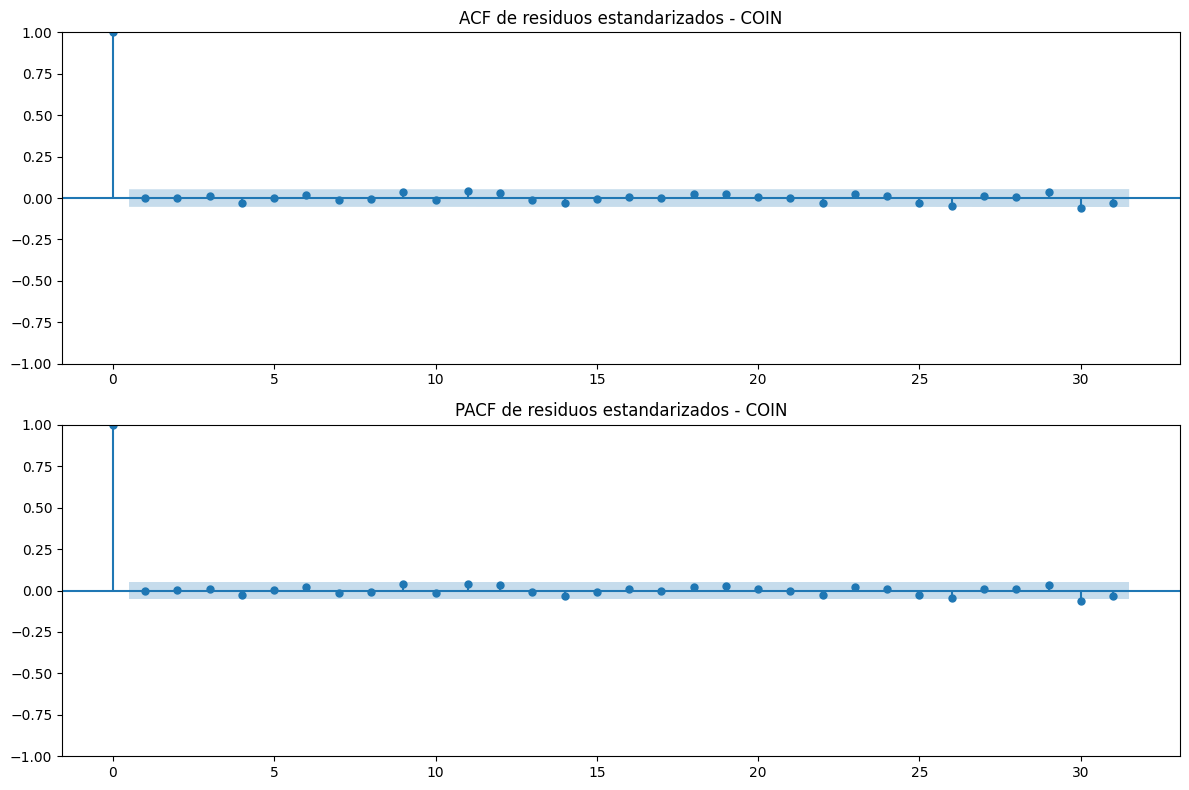


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 30]
Rezagos significativos en PACF: [0, 30]



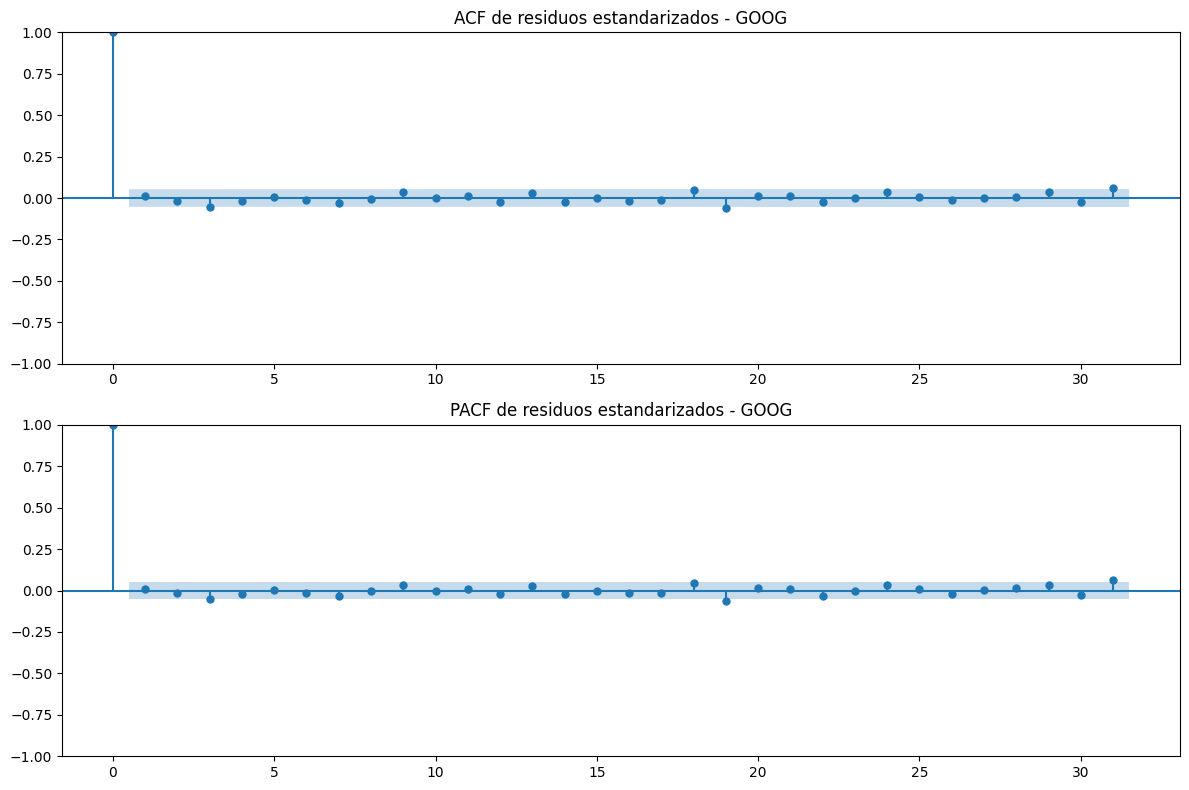


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 19, 31]
Rezagos significativos en PACF: [0, 19, 31]



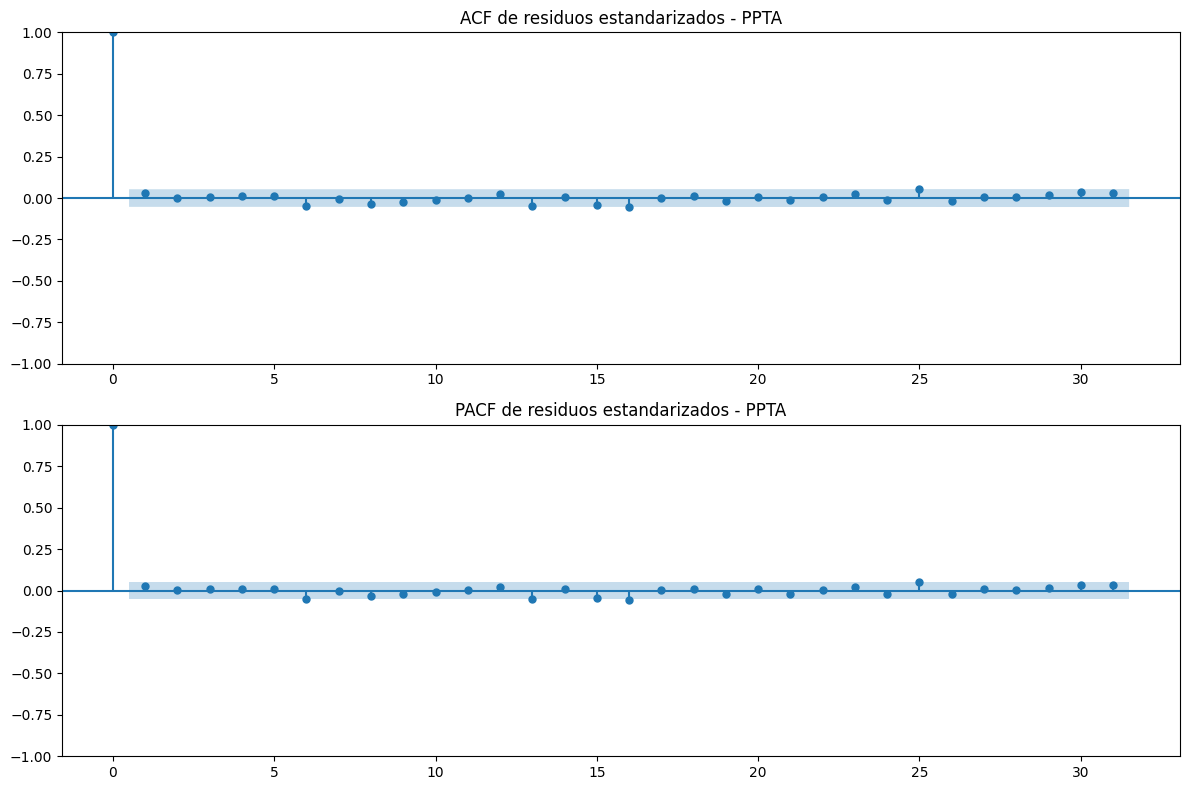


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 16, 25]
Rezagos significativos en PACF: [0, 16]



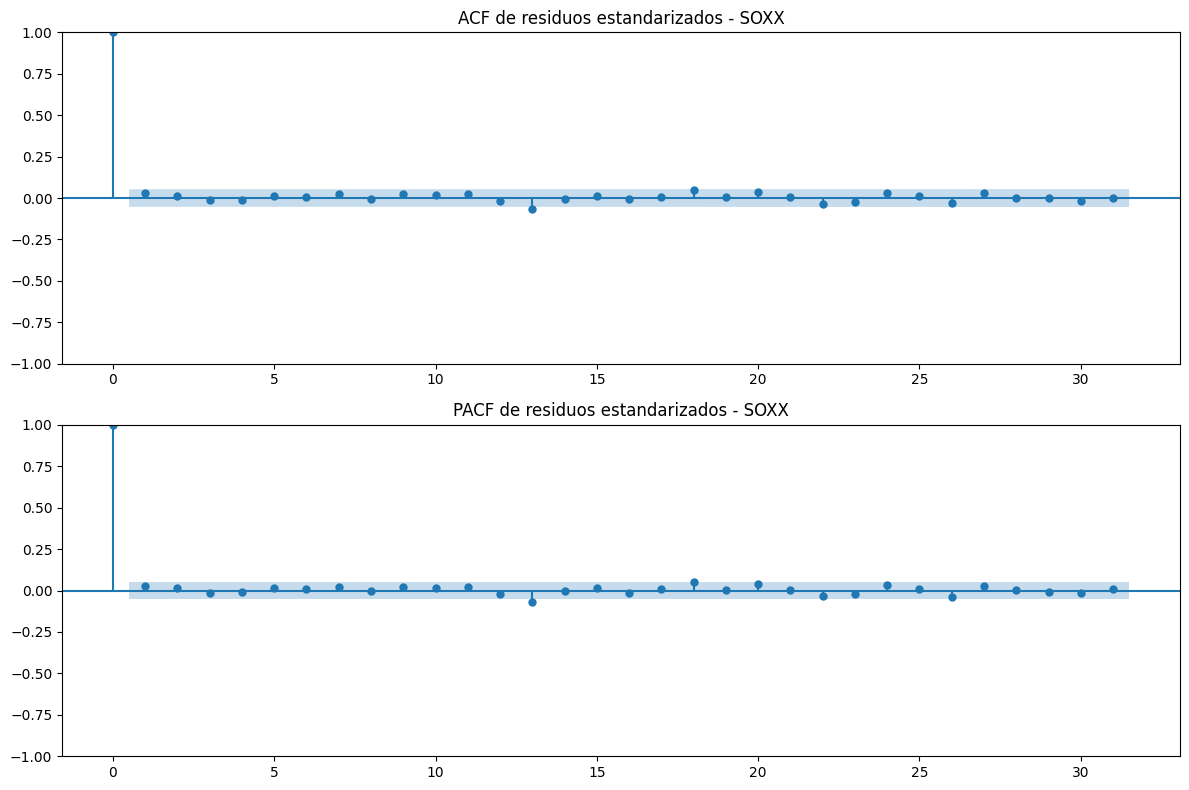


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 13]
Rezagos significativos en PACF: [0, 13]



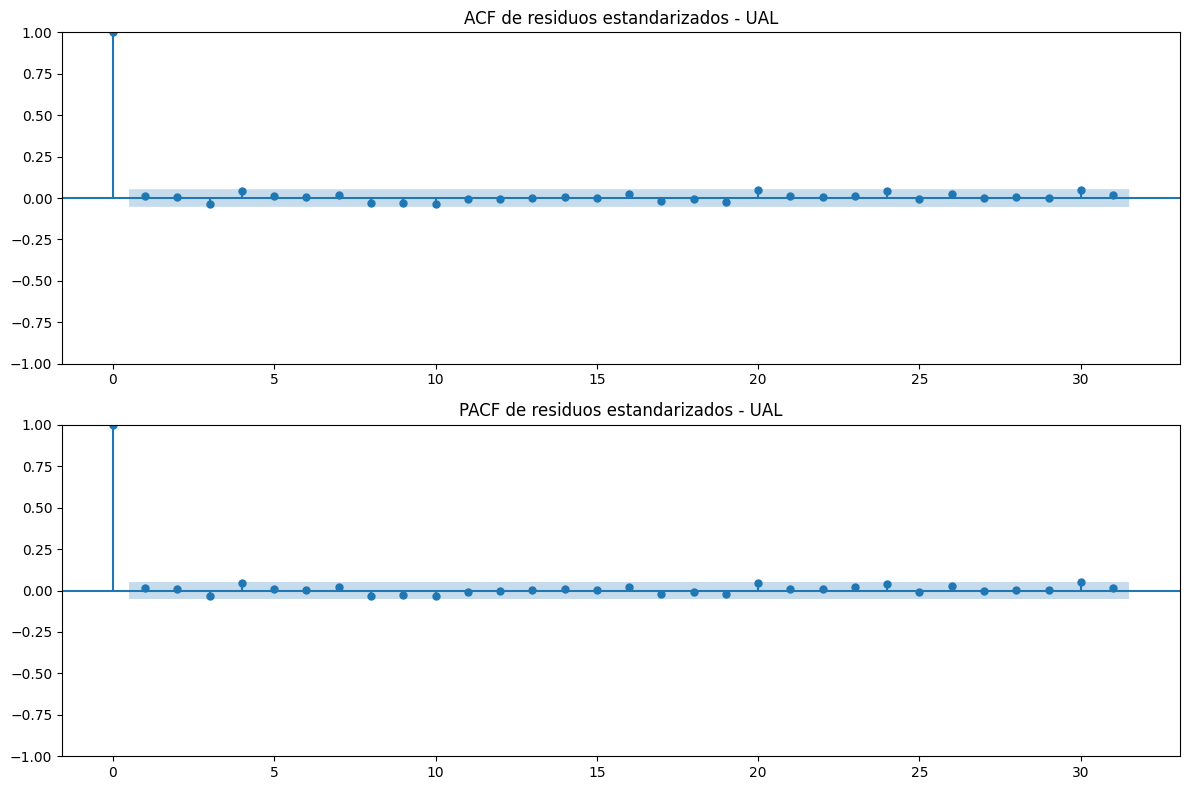


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0]
Rezagos significativos en PACF: [0]



In [62]:
#ACF/PACF de los residuos estandarizados
for ticker, residuos in residuos_garch.items():

    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    plot_acf(
        residuos,
        lags=31,
        ax=ax[0]
    )

    ax[0].set_title(
        f"ACF de residuos estandarizados - {ticker}"
    )

    plot_pacf(
        residuos,
        lags=31,
        ax=ax[1],
        method="ywm"
    )

    ax[1].set_title(
        f"PACF de residuos estandarizados - {ticker}"
    )

    plt.tight_layout()
    plt.show()
    print('')

    #Rezagos por encima del nivel de confianza

    #Número de rezagos (lags) a calcular
    n_lags = 31

    # Calcular ACF
    valores_acf = acf(residuos, nlags=n_lags, fft=True)

    # Calcular PACF
    valores_pacf = pacf(residuos, nlags=n_lags, method='ywm')

    #Organizar los resultados en una tabla
    df_correlograma = pd.DataFrame({
        'Rezago (Lag)': range(0, n_lags + 1),
        'ACF': valores_acf,
        'PACF': valores_pacf
    })

    #Configurar el rezago como el índice del DataFrame
    df_correlograma.set_index('Rezago (Lag)', inplace=True)

    #Identificar límite crítico
    N = len(residuos)
    limite_critico = 1.96 / np.sqrt(N)
    print(f"Límite crítico de significancia (95%): +/- {limite_critico:.4f}")

    #Filtrar rezagos que superan el límite (ignorando el rezago 0)
    rezagos_sig_acf = df_correlograma[df_correlograma['ACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en ACF: {rezagos_sig_acf}")
    rezagos_sig_pacf = df_correlograma[df_correlograma['PACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en PACF: {rezagos_sig_pacf}")
    print('')

De las cinco series, cuatro de ellas cuentan con uno o más rezagos por encima del nivel de confianza crítico, lo cual significa que no lograron capturar por completo la autocorrelación de los residuos.

La única serie cuyo modelo logró captar por completo la autocorrelación fue UAL.

En el caso de SOXX vemos como a pesar de contar con un modelo poco complejo y que resultó poseer parámetros significativos, no logró capturar la autocorrelación del rezago 13.

A pesar de no poseer un coeficiente significativo en α, el modelo (2,1) de COIN se acercó bastante, al capturar la mayoría de la autocorrelación, excepto en el rezago 30. Mientras tanto, los modelos (1,1) de GOOG y PPTA cuentan con dos rezagos por encima del nivel de confianza.

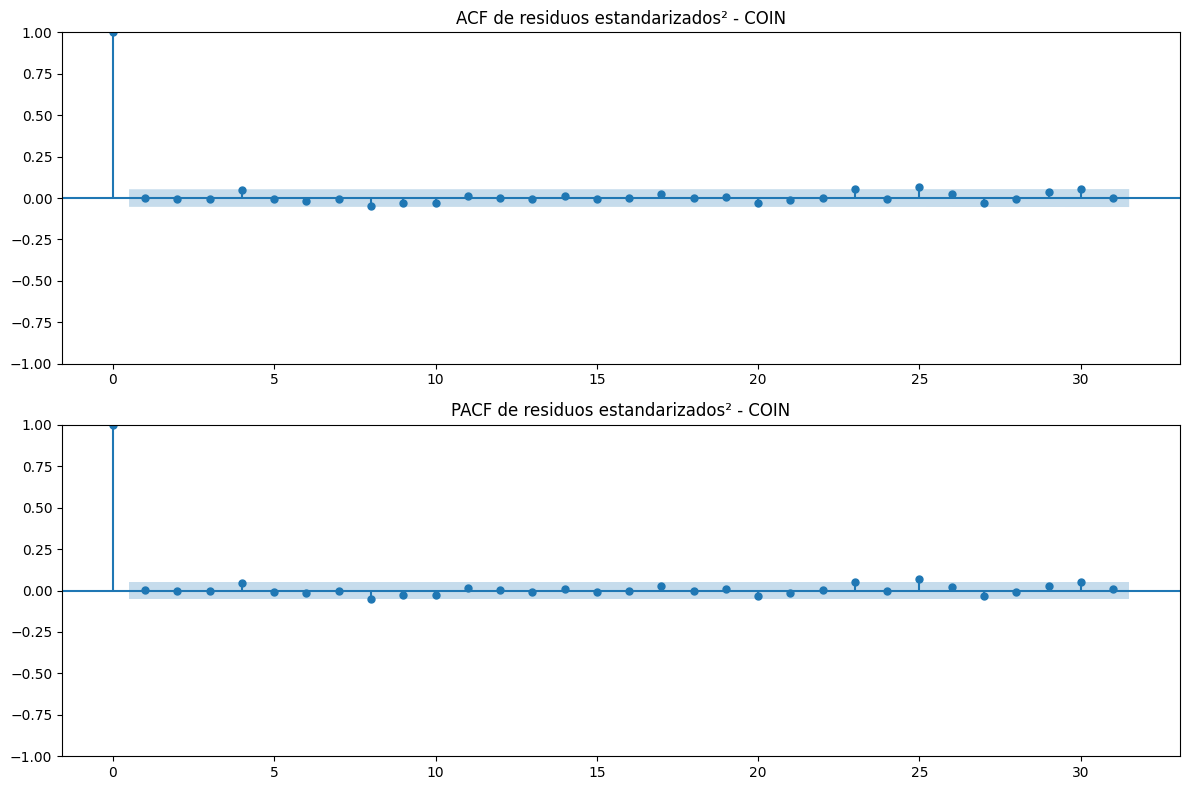


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 23, 25, 30]
Rezagos significativos en PACF: [0, 23, 25]



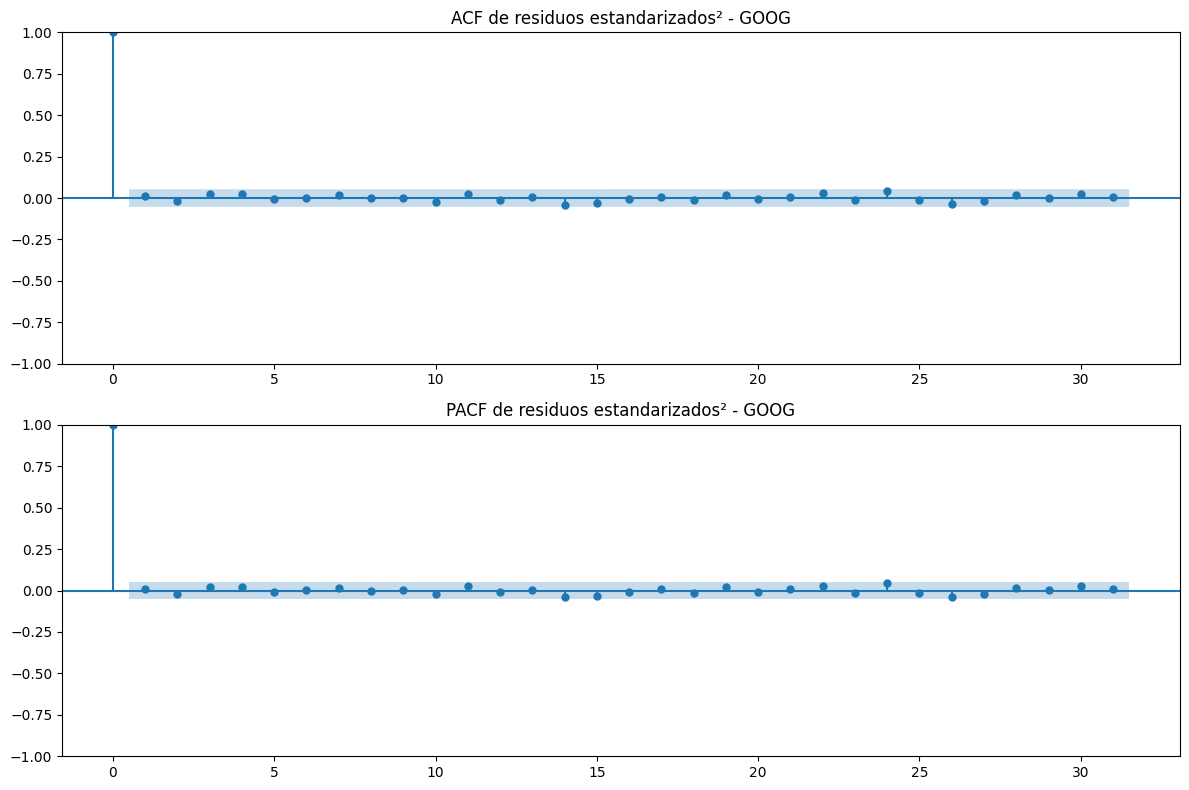


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0]
Rezagos significativos en PACF: [0]



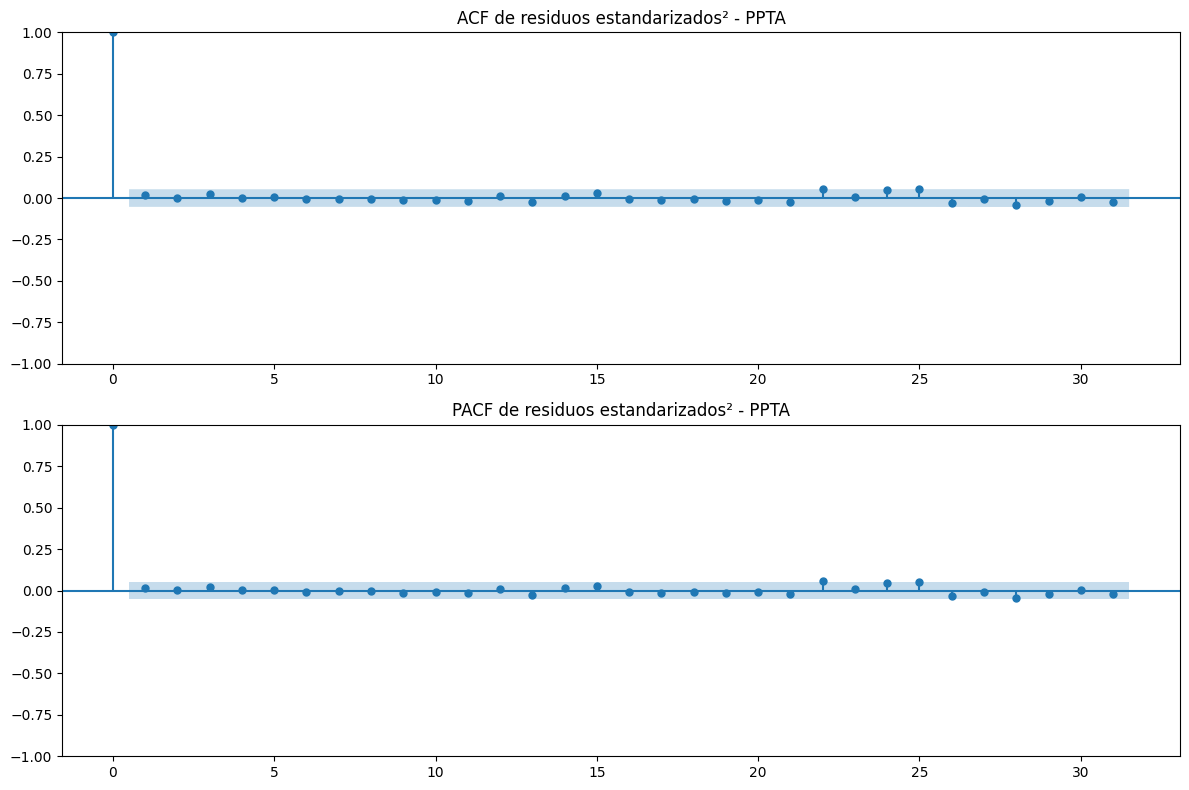


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 22]
Rezagos significativos en PACF: [0, 22]



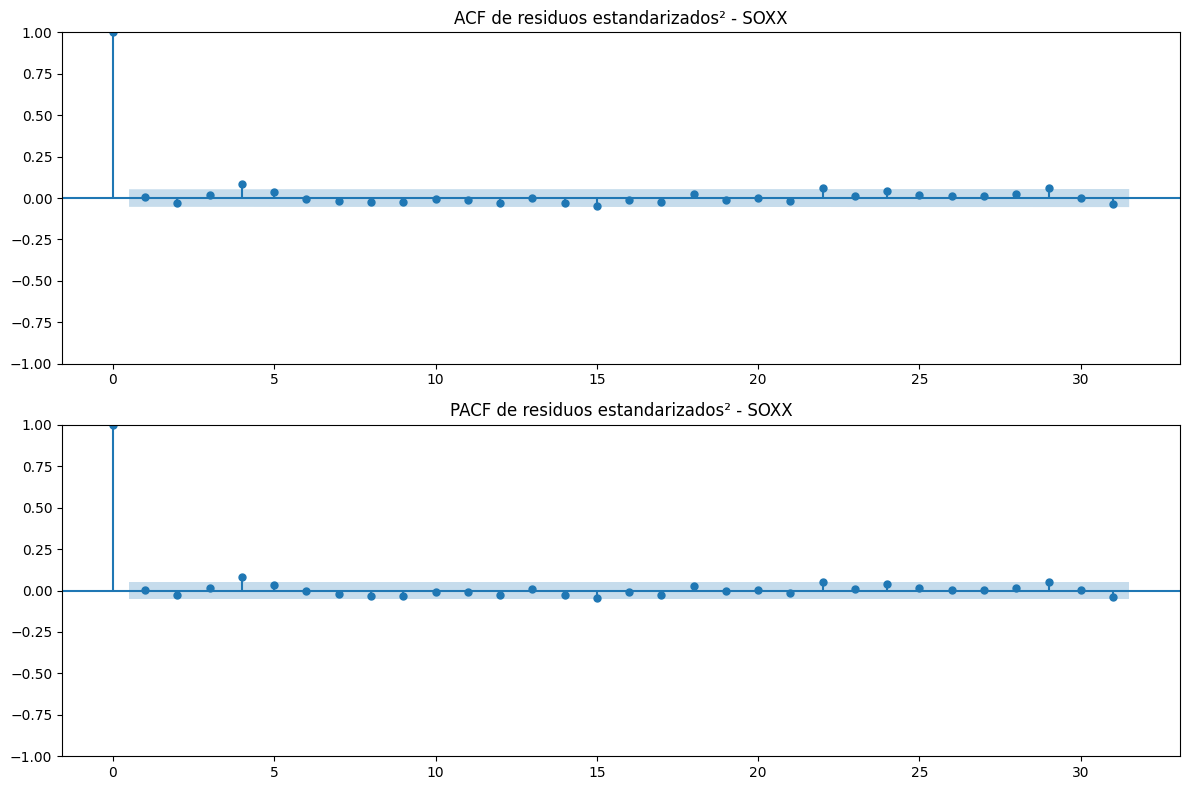


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 4, 22, 29]
Rezagos significativos en PACF: [0, 4, 22, 29]



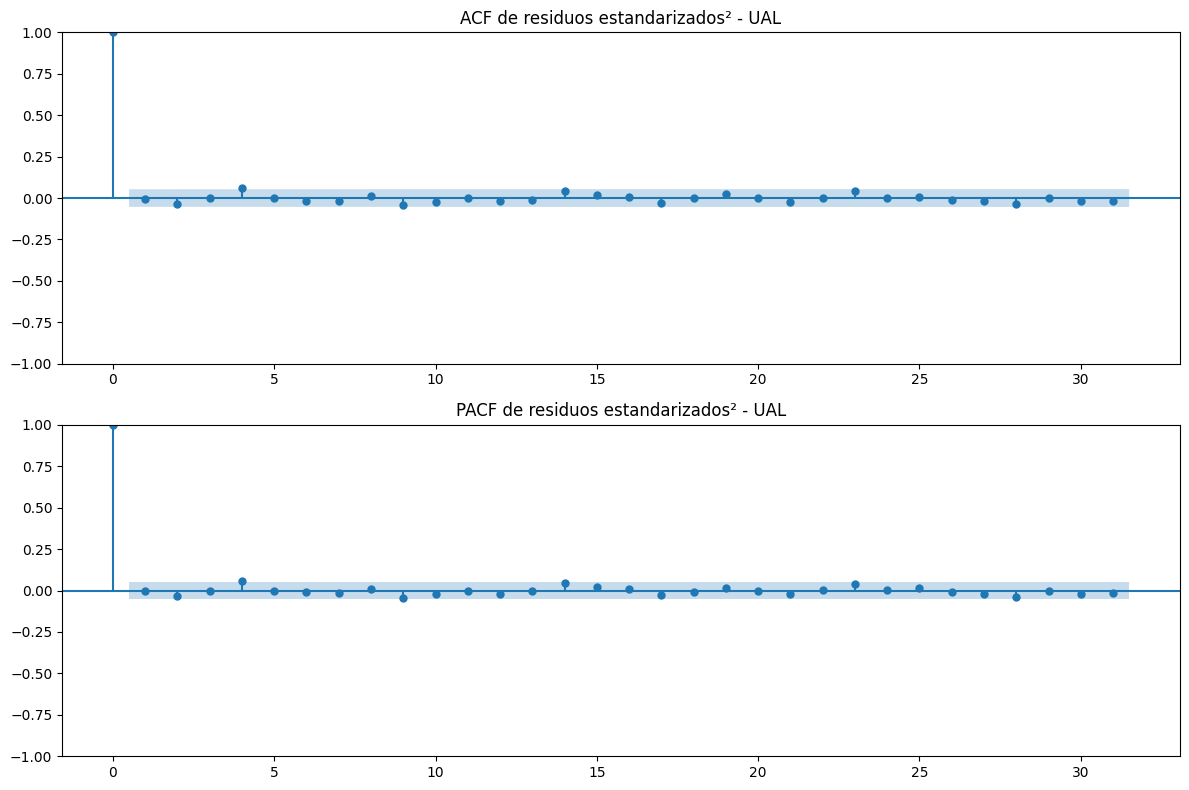


Límite crítico de significancia (95%): +/- 0.0531
Rezagos significativos en ACF: [0, 4]
Rezagos significativos en PACF: [0, 4]



In [63]:
#ACF/PACF de los residuos al cuadrado
for ticker, residuos in residuos_garch.items():

    residuos_cuadrados = residuos ** 2

    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    plot_acf(
        residuos_cuadrados,
        lags=31,
        ax=ax[0]
    )

    ax[0].set_title(
        f"ACF de residuos estandarizados² - {ticker}"
    )

    plot_pacf(
        residuos_cuadrados,
        lags=31,
        ax=ax[1],
        method="ywm"
    )

    ax[1].set_title(
        f"PACF de residuos estandarizados² - {ticker}"
    )

    plt.tight_layout()
    plt.show()
    print('')

    #Rezagos por encima del nivel de confianza

    #Número de rezagos (lags) a calcular
    n_lags = 31

    # Calcular ACF
    valores_acf = acf(residuos_cuadrados, nlags=n_lags, fft=True)

    # Calcular PACF
    valores_pacf = pacf(residuos_cuadrados, nlags=n_lags, method='ywm')

    #Organizar los resultados en una tabla
    df_correlograma = pd.DataFrame({
        'Rezago (Lag)': range(0, n_lags + 1),
        'ACF': valores_acf,
        'PACF': valores_pacf
    })

    #Configurar el rezago como el índice del DataFrame
    df_correlograma.set_index('Rezago (Lag)', inplace=True)

    #Identificar límite crítico
    N = len(residuos_cuadrados)
    limite_critico = 1.96 / np.sqrt(N)
    print(f"Límite crítico de significancia (95%): +/- {limite_critico:.4f}")

    #Filtrar rezagos que superan el límite (ignorando el rezago 0)
    rezagos_sig_acf = df_correlograma[df_correlograma['ACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en ACF: {rezagos_sig_acf}")
    rezagos_sig_pacf = df_correlograma[df_correlograma['PACF'].abs() > limite_critico].index.tolist()
    print(f"Rezagos significativos en PACF: {rezagos_sig_pacf}")
    print('')

Esta vez unicamente el modelo (1,1) de GOOG lográ captar la dependencia de la volatilidad en su totalidad.

PPTA y UAL se muestran cerca de captar la totalidad de esta dependencia, ya que unicamente uno de sus rezagos logra superar el límite crítico de confianza.

COIN y SOXX presentan bastante más problema para capturar todos los rezagos, siendo tres los que presentan correlación aún, lo que significa que aún queda estructura de volatilidad sin capturar.

A pesar de que los resultados de ACF/PACF muestran que ninguno de los modelos captura por completo la autocorrelación o la estrutura de volatilidad, la prueba Ljung-Box puede eliminar dudas al evaluar cada rezago y determinar si efectivamente aún no se capturan estas propiedades en los modelos.

###Ljung-Box de los residuos (modelos finales)

Ahora hacemos la prueba formal para los residuos estandarizados y al cuadrado de loss cinco activos. Utilizaremos nuevamente: 10, 20 y 31 rezagos.

H0: los residuos no presentan autocorrelación conjunta

H1: existe autocorrelación

Nivel de significancia: 0.05

In [64]:
#Prueba Ljung-Box
resultados_ljung = []

for ticker, residuos in residuos_garch.items():

    residuos_cuadrados = residuos ** 2

    lb_residuos = acorr_ljungbox(
        residuos,
        lags=[10, 20, 31],
        return_df=True
    )

    lb_cuadrados = acorr_ljungbox(
        residuos_cuadrados,
        lags=[10, 20, 31],
        return_df=True
    )

    for lag in [10, 20, 31]:

        resultados_ljung.append({
            "Ticker": ticker,
            "Lag": lag,
            "p-value residuos": lb_residuos.loc[
                lag, "lb_pvalue"
            ],
            "p-value residuos²": lb_cuadrados.loc[
                lag, "lb_pvalue"
            ]
        })

tabla_ljung_garch = pd.DataFrame(
    resultados_ljung
)

tabla_ljung_garch

,Ticker,Lag,p-value residuos,p-value residuos²
0,COIN,10,0.926999,0.561634
1,COIN,20,0.914347,0.925511
2,COIN,31,0.687463,0.508242
3,GOOG,10,0.618934,0.970015
4,GOOG,20,0.460494,0.984807
5,GOOG,31,0.429649,0.974124
6,PPTA,10,0.646538,0.997995
7,PPTA,20,0.524684,0.999578
8,PPTA,31,0.589803,0.888696
9,SOXX,10,0.940342,0.122389


Los resultados de la prueba Ljung-Box son muy positivos, ya que confirman que la autocorrelación ha sido capturada completamente tanto para efectos de autocorrelación a la media como efecto ARCH, lo implicaría que los modelos son adecuados para realizar pronósticos en base a un modelo representativo y ajustado.

Para corroborar que se haya capturado por completo el efecto ARCH, se aplicará una prueba adicional.

###Prueba ARCH-LM (modelos finales)

H0: No existe efecto ARCH.

H1: Existe heterocedasticidad condicional.

Nivel de significancia: 0.05

In [65]:
#Prueba ARCH-LM (Engle)
resultados_arch = []

for ticker, residuos in residuos_garch.items():

    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
        residuos
    )

    resultados_arch.append({
        "Ticker": ticker,
        "LM Statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F Statistic": f_stat,
        "F p-value": f_pvalue
    })

tabla_arch_final = pd.DataFrame(
    resultados_arch
)

tabla_arch_final

,Ticker,LM Statistic,LM p-value,F Statistic,F p-value
0,COIN,8.704526,0.560356,0.868967,0.562001
1,GOOG,3.291679,0.973703,0.327289,0.974086
2,PPTA,1.648846,0.998392,0.163744,0.998424
3,SOXX,16.199873,0.094052,1.626284,0.093689
4,UAL,10.298889,0.414674,1.029352,0.415875


Según muestra el valor p de LM, ya no resta ninguna señal de autocorrelación a la media ni de dependencia de la volatilidad en los residuos de los modelos GARCH, por lo que se puede concluir que los cinco GARCH están realmente validados y, sobre todo, COIN y PPTA no requieren pasar a EGARCH/GJR-GARCH, ya que a pesar de que sus parámetros mostraron falta de significancia estadística, estos consiguen capturar adecuadamente la dinámica de volatilidad.

##Volatilidad condicional

La librería `arch` nos proporciona la función `.conditional_volatility` para transformar los datos de varianza que captura el modelo GARCH en desviación estándar condicional.

Estos valores son útiles para poder interpretar las estimaciones del modelo como una medida de volatilidad condicional útil para el manejo de riesgo y para generar poryecciones comparables que posteriormente serán evaluadas al comparse con la volatilidad realizada de cada periódo.

###Cálculo de la volatilidad condicional

In [66]:
#Cálculo de la volatilidad condicional
volatilidad_garch = pd.DataFrame({
    ticker: modelo.conditional_volatility
    for ticker, modelo in modelos_garch_finales.items()
})

volatilidad_garch.head()

,COIN,GOOG,PPTA,SOXX,UAL
Fecha,,,,,
2021-04-16,4.204295,1.310438,3.071584,1.867466,2.880635
2021-04-19,4.353176,1.308560,3.071408,1.819541,2.788257
2021-04-20,4.609327,1.306776,3.079208,1.917524,2.737746
2021-04-21,4.509379,1.305961,3.084226,1.915956,3.577673
2021-04-22,4.495977,1.304202,3.097497,1.959622,3.506565


In [67]:
volatilidad_garch.shape

(1364, 5)

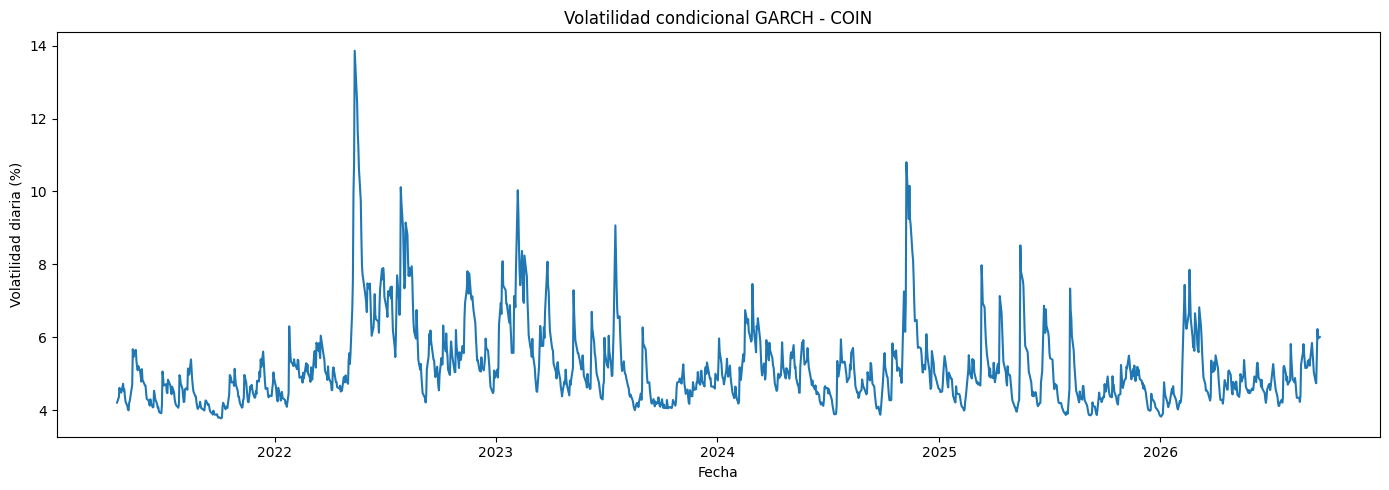

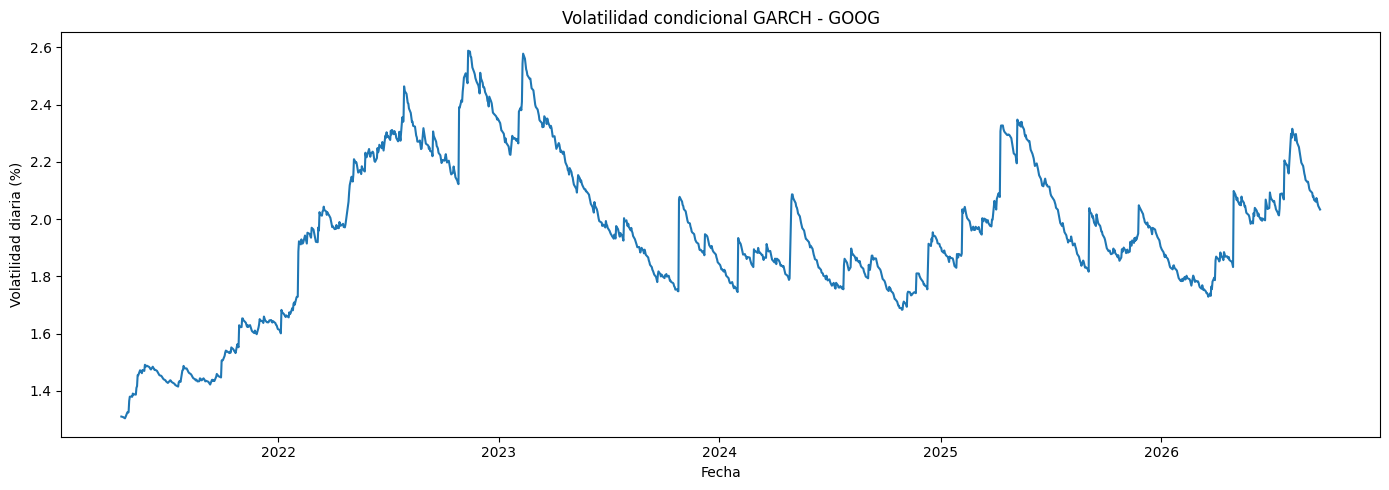

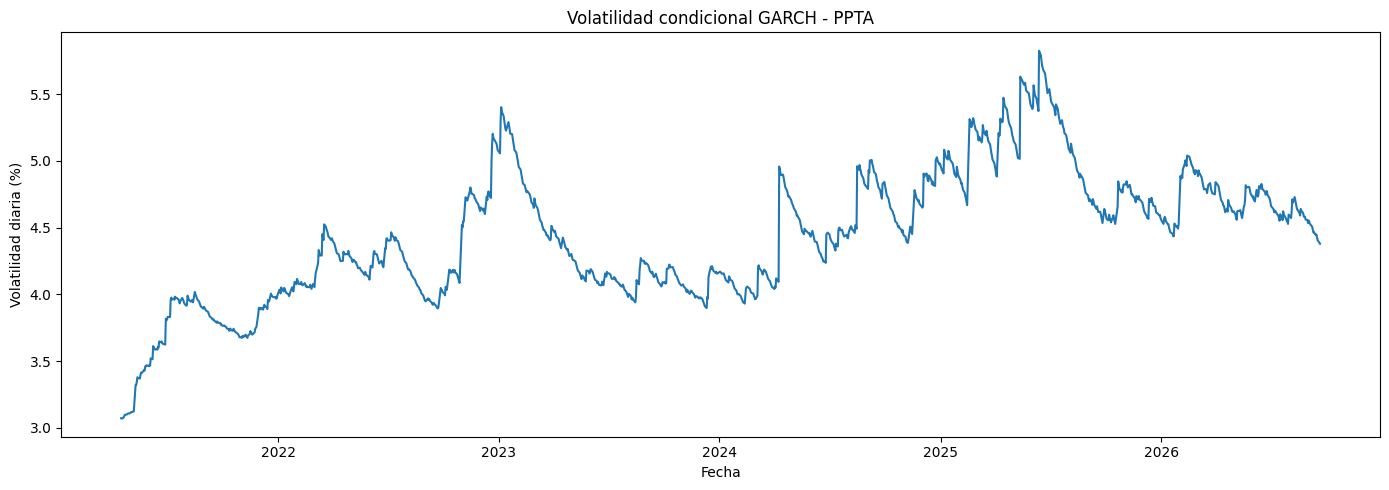

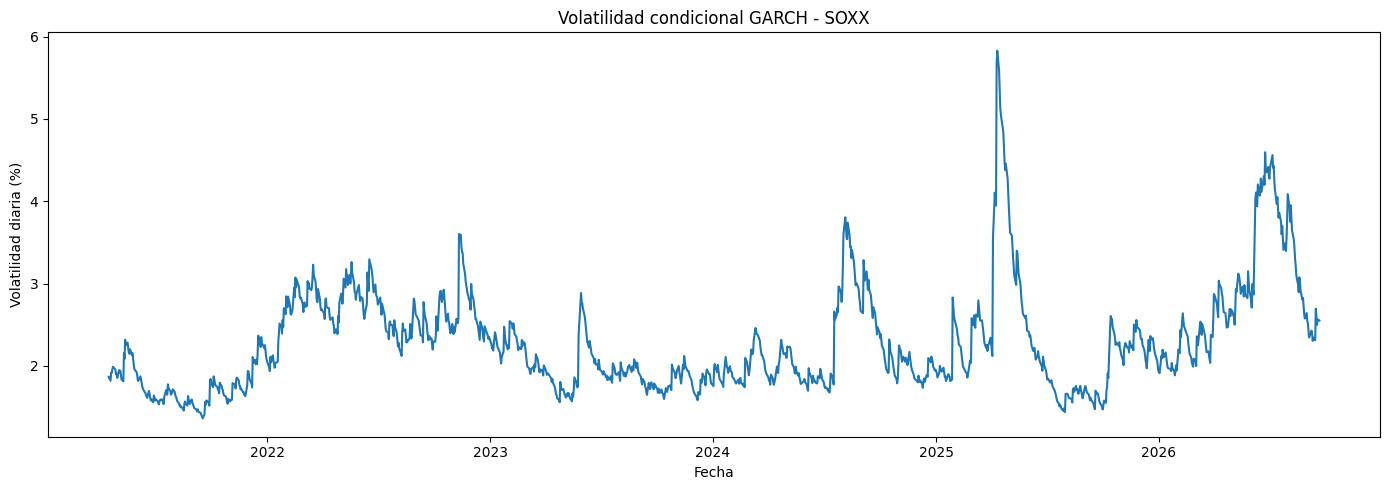

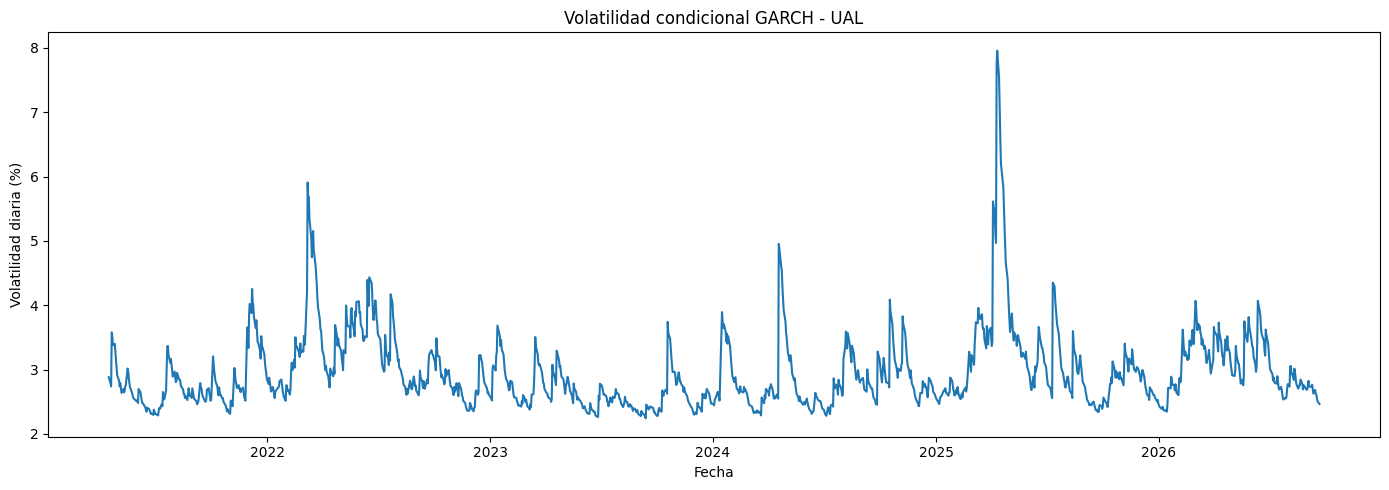

In [68]:
#Visualización de la volatilidad condicional a lo largo del tiempo
for ticker in volatilidad_garch.columns:

    plt.figure(figsize=(14, 5))

    plt.plot(
        volatilidad_garch.index,
        volatilidad_garch[ticker]
    )

    plt.title(
        f"Volatilidad condicional GARCH - {ticker}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad diaria (%)")

    plt.tight_layout()
    plt.show()

Ahora disponiendo de una tabla con los datos de volatilidad condicional de cada serie de tiempo financiera, se puede observar el comportamiento de  est indicador a lo largo del periódo analizado.

En los gráficos podemos encontrarnos con una representación parecida a lo visto en el análisis de volatilidad móvil hecho previamente.

Destaca el hecho de que se pueden apreciar periodos puntuales en los que la volatilidad se elevó muy encima de su tendencia media. Esto es un comportamiento conocido como clustering de volatilidad, y es un fenómeno usual en las series de tiempo financieras debido a la naturales de los mercados bursátiles siendo muy reaccionarios a cambios estructurales en la economía o a shocks en los respectivos sectores a los que pertenecen las empresas que cotizan en bolsa.

###Comparación de volatilidad móvil con la volatilidad condicional

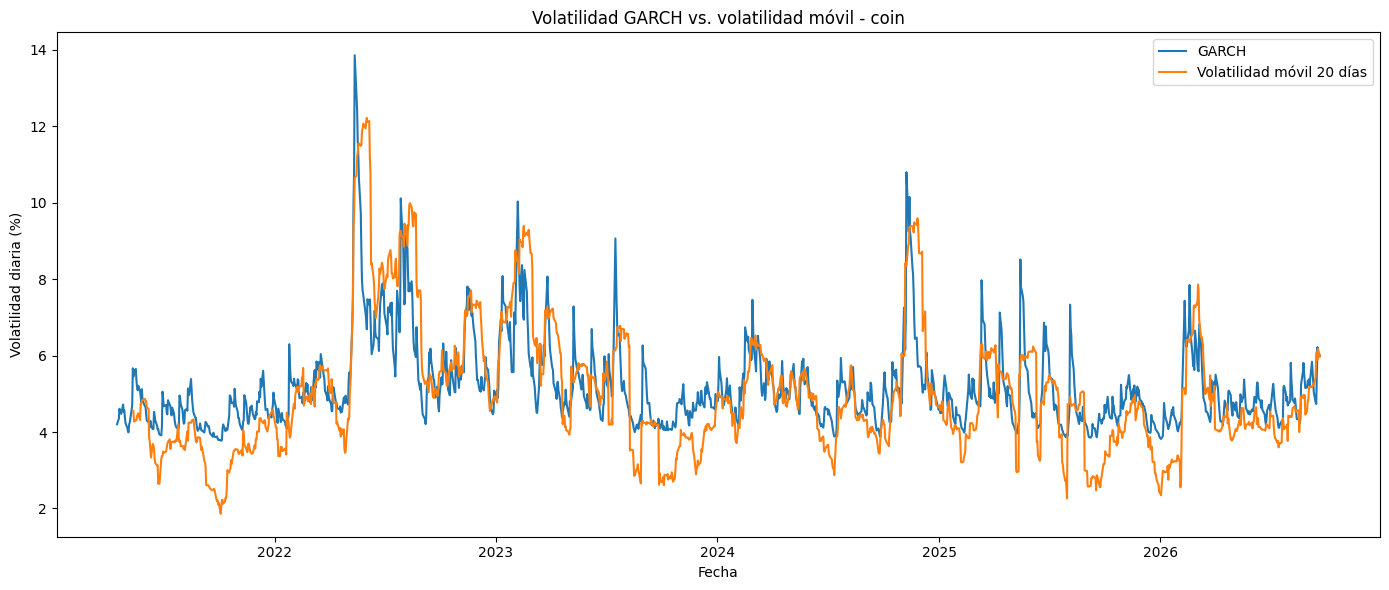

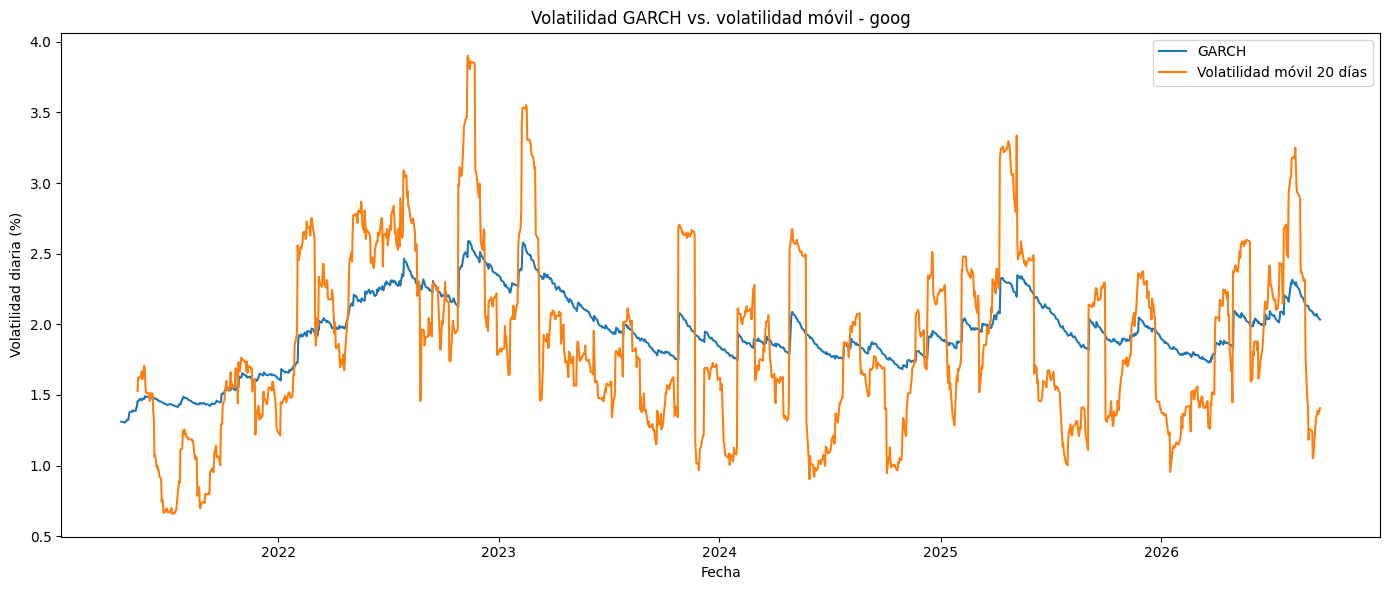

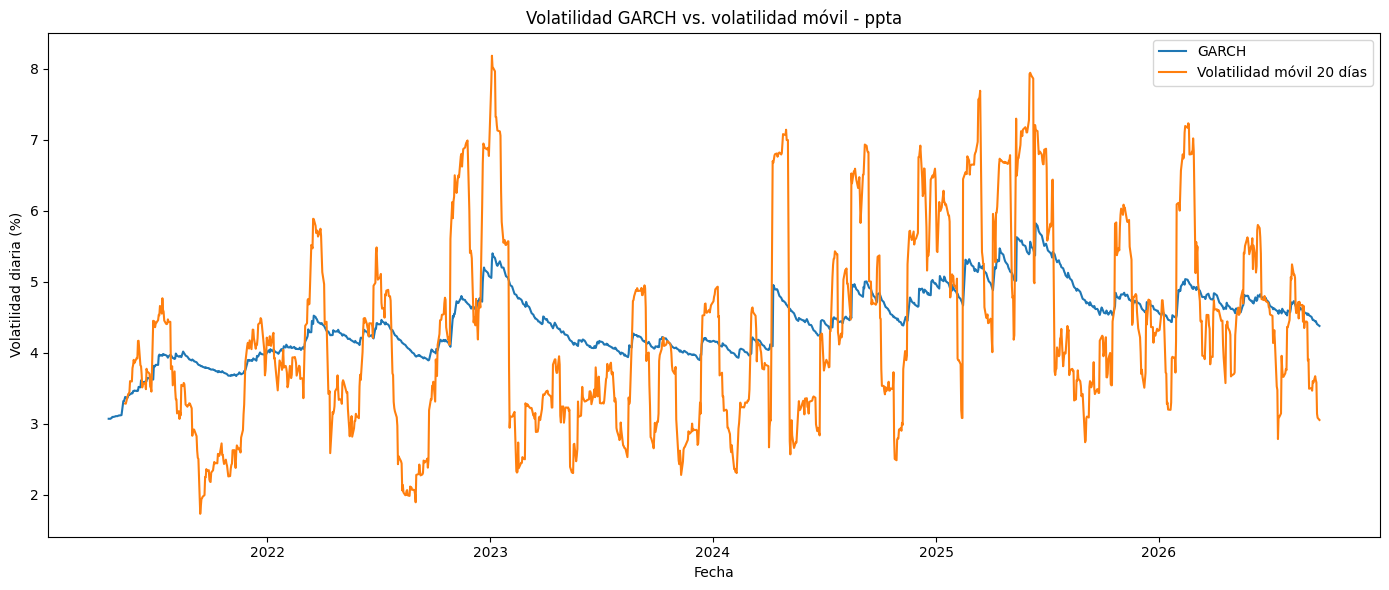

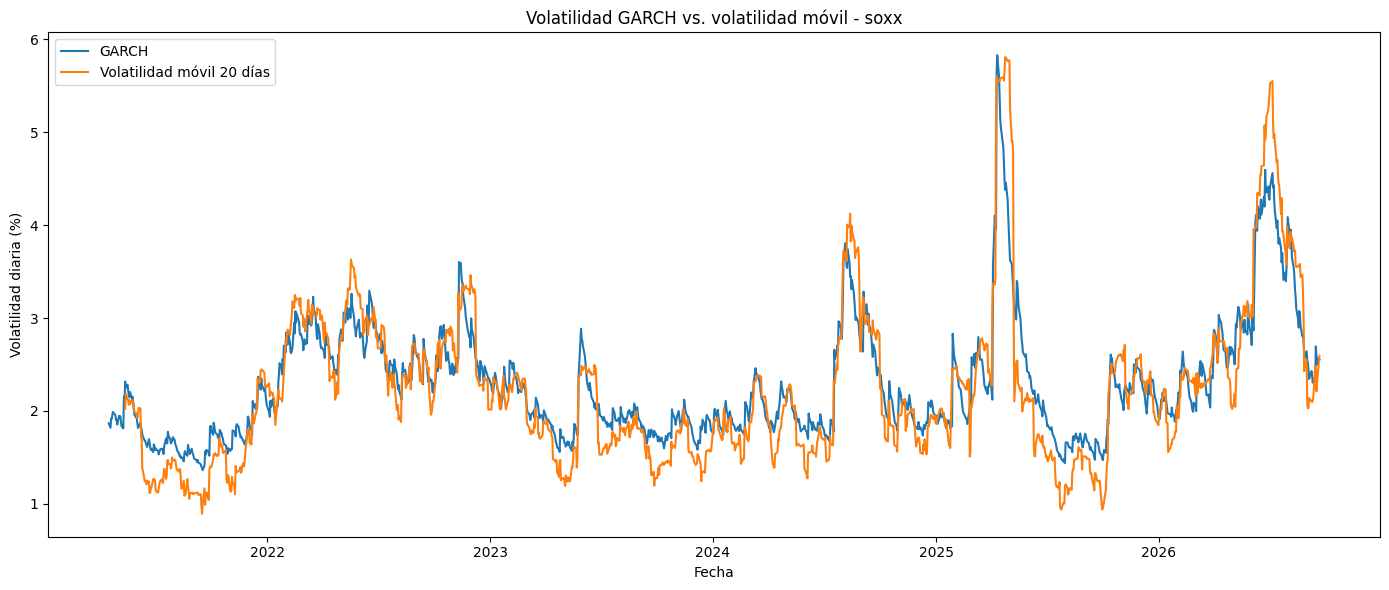

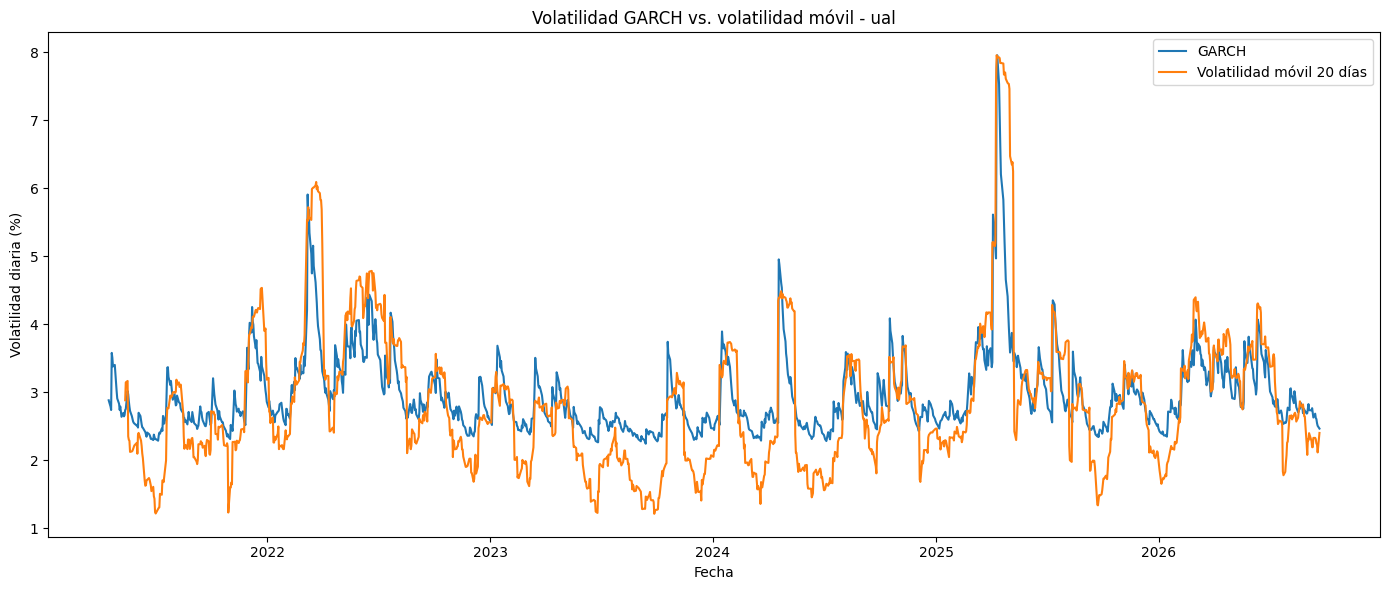

In [69]:
#Comparación entre métricas de volatilidad
for ticker in stocks:

  plt.figure(figsize=(14, 6))

  plt.plot(
      volatilidad_garch.index,
      volatilidad_garch[ticker.upper()],
      label="GARCH"
  )

  plt.plot(
      volatilidad_20.index,
      volatilidad_20[ticker] * 100, #Debido a que la medida de volatilidad móvil esta representada en forma de proporción, se ha decidido multiplicarla por 100 para que sea comparable con nuestra nueva métrica
      label="Volatilidad móvil 20 días"
  )

  plt.title(
      f"Volatilidad GARCH vs. volatilidad móvil - {ticker}"
  )

  plt.xlabel("Fecha")
  plt.ylabel("Volatilidad diaria (%)")
  plt.legend()

  plt.tight_layout()
  plt.show()

In [70]:
#Correlación entre métricas
correlacion_volatilidad = {}

for ticker in volatilidad_garch.columns:

    datos = pd.DataFrame({
        "GARCH": volatilidad_garch[ticker],
        "Volatilidad_20": volatilidad_20[ticker.lower()] * 100
    }).dropna()

    correlacion_volatilidad[ticker] = (datos["GARCH"].corr(datos["Volatilidad_20"]))

correlacion_volatilidad

{'COIN': np.float64(0.7997495798538158),
 'GOOG': np.float64(0.7380870628835501),
 'PPTA': np.float64(0.6986348494343758),
 'SOXX': np.float64(0.9449406230125945),
 'UAL': np.float64(0.8685875877258208)}

La comparación entre la volatilidad móvil de 20 días y la volatilidad condicional estimada mediante GARCH muestra comportamientos similares, lo cual se confirma mediante la fuerte correlación positiva observada entre ambas medidas, particularmente durante episodios en los que la volatilidad experimentó incrementos o disminuciones importantes.

Sin embargo, las diferencias entre ambas metodologías también resultan relevantes. La volatilidad móvil constituye una medida retrospectiva que depende de una ventana fija de observaciones, mientras que la volatilidad condicional estimada mediante GARCH incorpora dinámicamente la información disponible hasta cada periodo, considerando tanto los shocks recientes como la persistencia de la volatilidad.

Estas diferencias son especialmente visibles en activos como GOOG y PPTA, donde la volatilidad móvil presenta reacciones más pronunciadas ante determinados shocks y, en algunos episodios, sobreestima la volatilidad respecto a la estimación condicional del modelo.

Ambas metodologías permiten identificar la dependencia temporal característica de la volatilidad financiera. No obstante, la volatilidad condicional resulta particularmente útil para la gestión y cuantificación del riesgo, debido a que puede emplearse para generar estimaciones dinámicas de volatilidad futura y alimentar modelos como el Value at Risk (VaR). Una sobreestimación del riesgo puede conducir a una posición excesivamente conservadora, pero una subestimación puede resultar más perjudicial al generar niveles de protección insuficientes frente a pérdidas potenciales.

Por ello, los resultados obtenidos respaldan el uso de modelos GARCH como una herramienta más apropiada para transformar la información histórica de volatilidad en una medida dinámica que pueda utilizarse posteriormente en la evaluación y gestión del riesgo financiero.

##Pronósticos de volatilidad fuera de muestra


El propósito de esta sección es averiguar si el GARCH no solo describe adecuadamente la volatilidad pasada, sino si también proporciona pronósticos útiles de la volatilidad futura, lo cual es sumamente importante al gestionar el riesgo en portafolios de inversión o analizar activos potenciales para incorporar a la cartera.

Para generar un modelo de pronóstico y evaluar sus proyecciones fuera de muestra, se ha decidido utilizar la información del dataset actual con 1,364 observaciones de la siguiente manera:

- 80 % entrenamiento: 1,091 observaciones aproximadamente.
- 20 % prueba: 273 observaciones aproximadamente.

Para la prueba se utilizarán los datos de entrenamiento para preparar un modelo que proyecte los datos fuera de esta muestra en base al dato del periodo anterior. Dichos datos serán comparados con los datos del dataset de prueba para evaluar su precisión.

El pronóstico de volatilidad se comparará con la volatilidad realizada estimada por rendimiento cuadrado. Aunque se trata de un proxy ruidoso para el pronóstico de un día adelante se usará esta medida de primera mano, ya que nos permite construir y validar correctamente todo el procedimiento (posteriormente se utilizará otra forma de medición para evaluar ventanas de días más amplias).

Para medir la precisión se utilizará Quasi-likelihood (Q-Like), Error Absoluto Medio (MAE), Raíz del Error Cuadrático Medio (RMSE) (para ambas métricas se considera que un valor cercano a 0 representa una mayor precisión).

###Preparación de muestras

In [71]:
#Preparación de las dos muestras
train_data = {}
test_data = {}

for ticker in stocks:

    n_train = int(len(retornos_l[ticker]) * 0.80)

    train_data[ticker] = retornos_l[ticker].iloc[:n_train]
    test_data[ticker] = retornos_l[ticker].iloc[n_train:]

In [72]:
#Validación de muestras
for ticker in stocks:
    print(
        ticker,
        "Train:", len(train_data[ticker]),
        "Test:", len(test_data[ticker])
    )

coin Train: 1091 Test: 273
goog Train: 1091 Test: 273
ppta Train: 1091 Test: 273
soxx Train: 1091 Test: 273
ual Train: 1091 Test: 273


###Pronóstico fuera de muestra

Para evitar un problema metodológico, en vez de estimar un modelo una sola vez y después pronosticar todo el conjunto de prueba, se utilizará un esquema expanding window.

**Entrenamiento inicial
        ->
pronóstico t+1
        ->
incorporar t+1
        ->
pronóstico t+2
        ->
incorporar t+2
        ->
        ...**

De esta forma se parte del supuesto de que cada pronóstico utiliza únicamente información que habría estado disponible en ese momento.

In [73]:
#Entrenamiento de modelos
especificaciones = {"coin": (2, 1),"goog": (1, 1),"ppta": (1, 1),
                    "soxx": (1, 1),"ual": (1, 1)}

pronosticos_vol = {}

for ticker, (p, q) in especificaciones.items():

    serie = retornos_l[ticker].dropna() * 100

    n_train = int(len(serie) * 0.80)

    forecasts = []

    for i in range(n_train, len(serie)):

        #Información disponible hasta t
        train_window = serie.iloc[:i]

        modelo = arch_model(
            train_window,
            mean="Zero",
            vol="GARCH",
            p=p,
            q=q,
            dist="normal"
        )

        resultado = modelo.fit(disp="off")

        #Pronóstico de un día adelante
        forecast = resultado.forecast(
            horizon=1,
            reindex=False
        )

        varianza_forecast = forecast.variance.iloc[-1, 0]

        volatilidad_forecast = np.sqrt(varianza_forecast)

        forecasts.append(volatilidad_forecast)

    pronosticos_vol[ticker] = pd.Series(forecasts,index=serie.index[n_train:])

    pronosticos_vol_df = pd.DataFrame(pronosticos_vol)

pronosticos_vol_df.head()

,coin,goog,ppta,soxx,ual
Fecha,,,,,
2025-08-20,4.199448,1.805297,4.921449,1.707025,2.986047
2025-08-21,4.642448,1.795971,4.886196,1.666290,2.945483
2025-08-22,4.432212,1.779341,4.878438,1.628073,2.933754
2025-08-25,4.317810,1.813885,4.784580,1.750434,3.237104
2025-08-26,4.793083,1.805244,4.711285,1.700838,3.107035


In [74]:
pronosticos_vol_df.shape

(273, 5)

Una vez que contamos con los datos de pronóstico y se ha determinado que las unidades y dimensiones son correctas,  ahora se pueden visualizar las series pronosticadas para observar su comportamiento de forma preliminar.

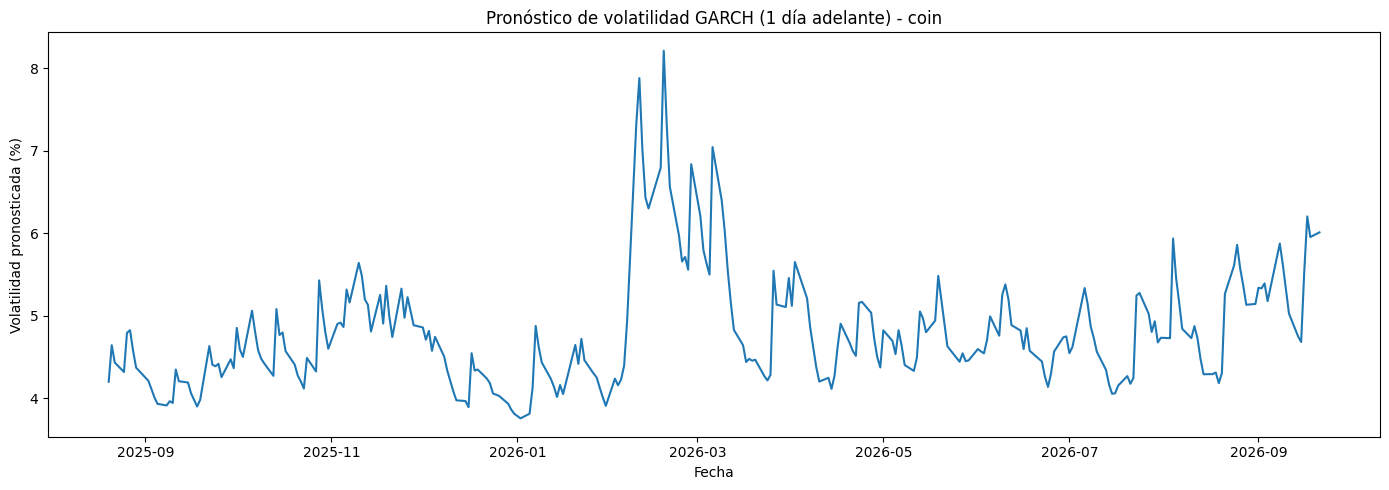

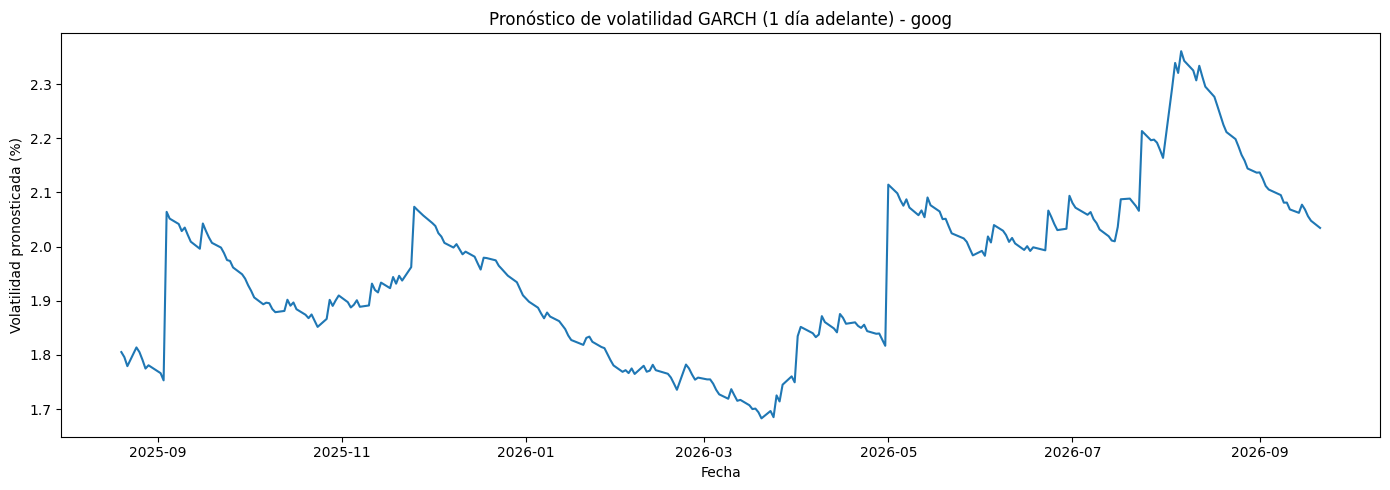

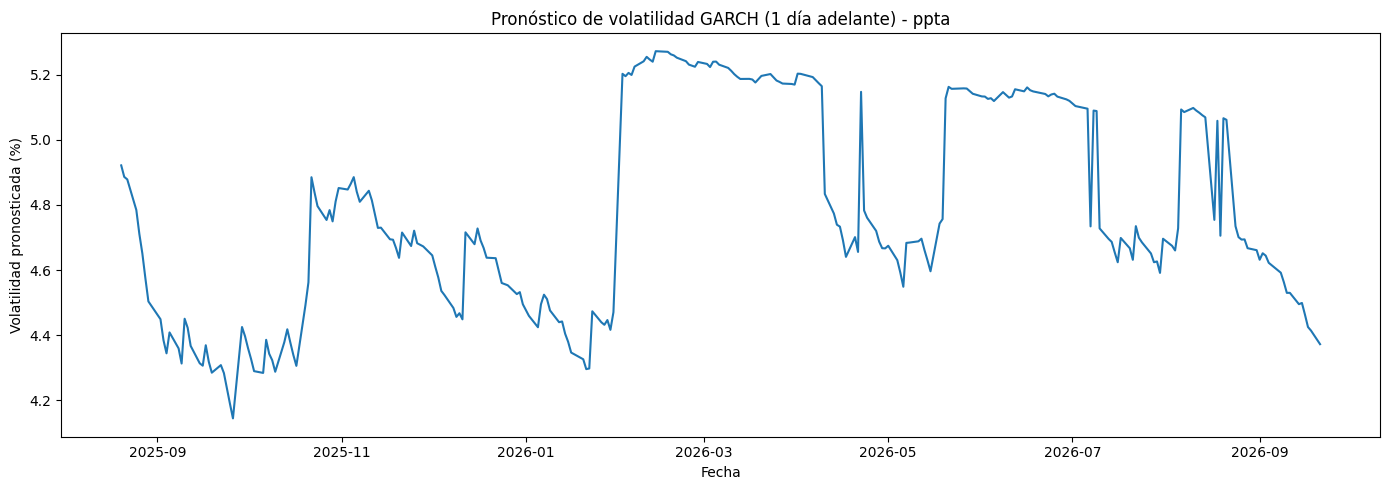

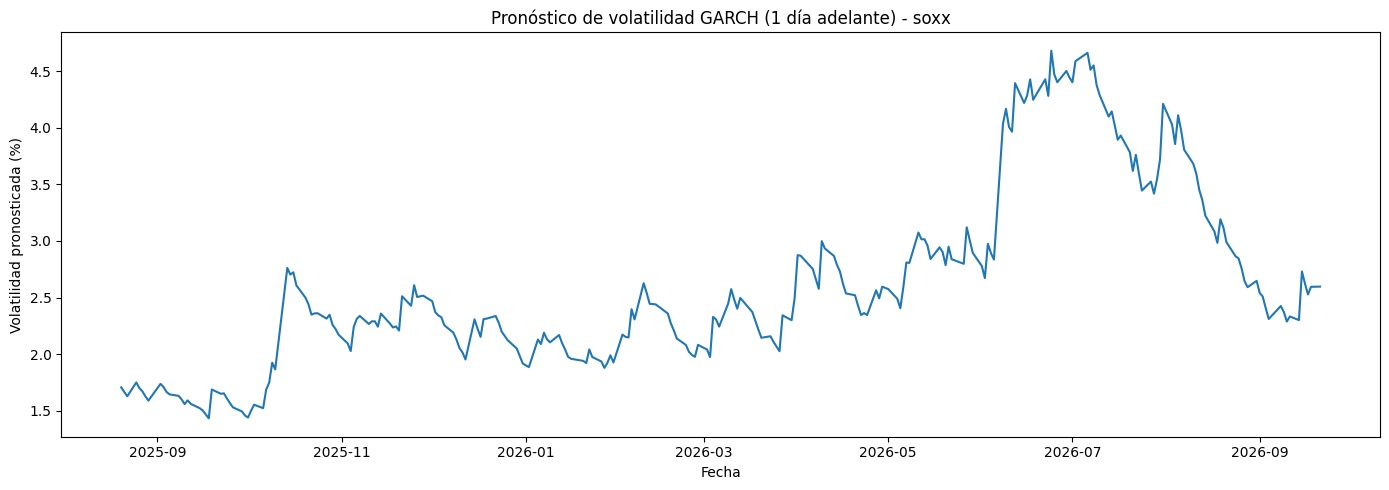

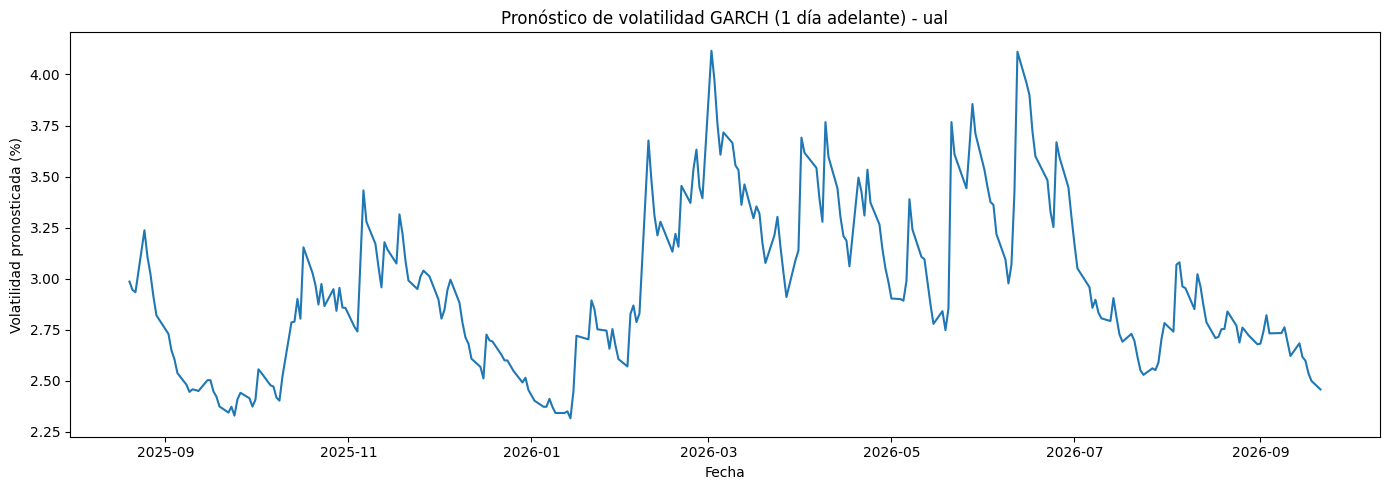

In [75]:
#Visualización de los pronósticos
for ticker in pronosticos_vol_df.columns:

    plt.figure(figsize=(14, 5))

    plt.plot(
        pronosticos_vol_df.index,
        pronosticos_vol_df[ticker]
    )

    plt.title(
        f"Pronóstico de volatilidad GARCH (1 día adelante) - {ticker}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad pronosticada (%)")

    plt.tight_layout()
    plt.show()

En estas visualizaciones se observa que la volatilidad pronosticada no es constante, sino que se adapta a los cambios en el régimen de volatilidad, lo cual alude a la propiedad condicional derivada del modelo GARCH utilizado para pronosticar el modelo.

###Comparación de pronósticos con volatilidad realizada

In [76]:
#Cálculo de la volatilidad realizada
rendimientos_test = pd.DataFrame({ticker: test_data[ticker] for ticker in stocks})

#Asegurarse de que rendimientos_test solo contiene las fechas presentes en pronosticos_vol_df
rendimientos_test = rendimientos_test.loc[pronosticos_vol_df.index]

rendimientos_test_pct = rendimientos_test * 100

varianza_realizada = rendimientos_test_pct ** 2

#Definir varianza_pronosticada (no estaba definida en el contexto)
varianza_pronosticada = pronosticos_vol_df ** 2

print(varianza_pronosticada.shape)
print(varianza_realizada.shape)

print(varianza_pronosticada.index.equals(varianza_realizada.index))

(273, 5)
(273, 5)
True


Con este paso se contruyeron dos dataframes con los mismos campos y con coincidencia en fechas, por lo cual están listos para comparación.

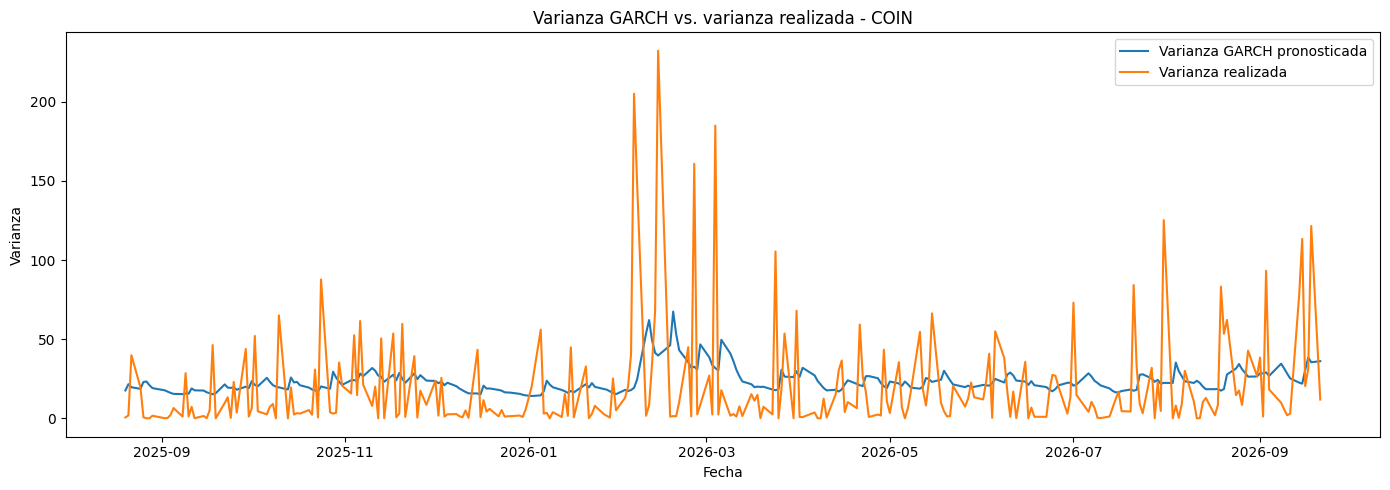

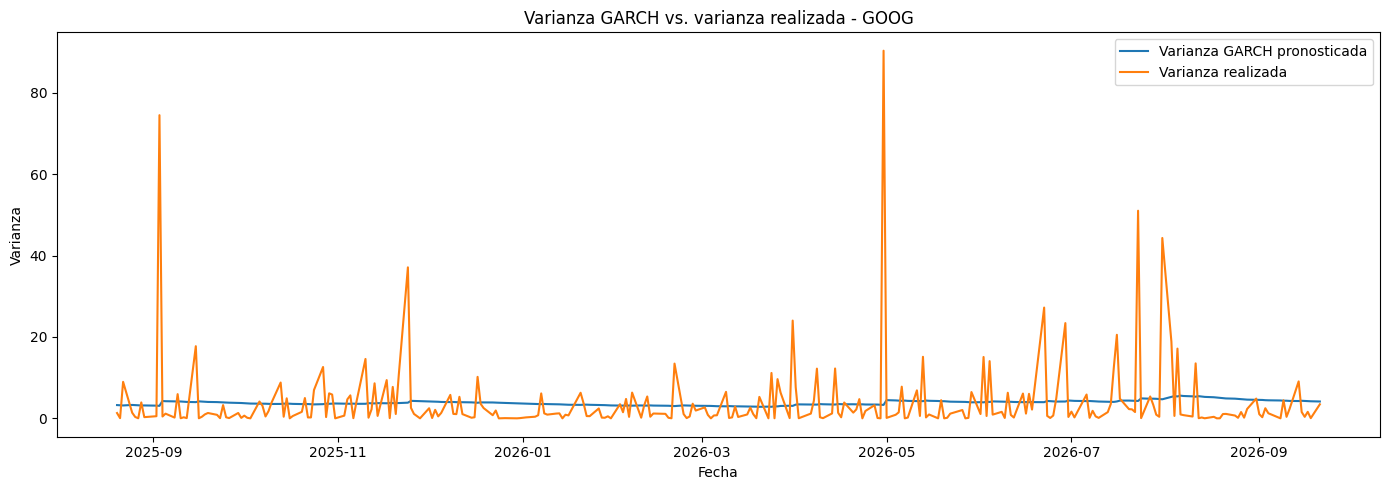

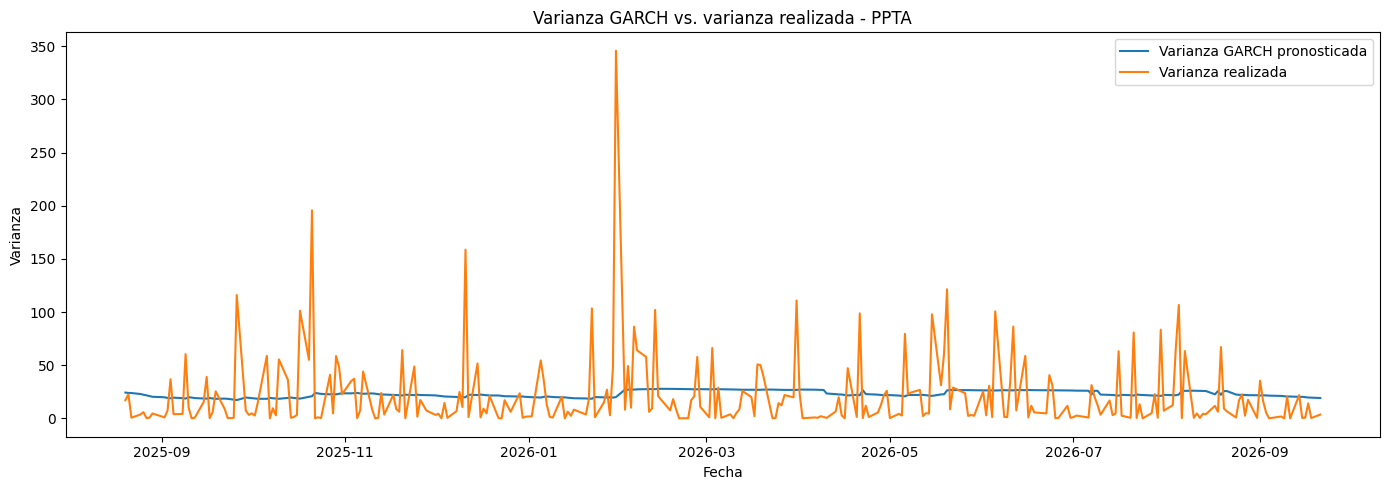

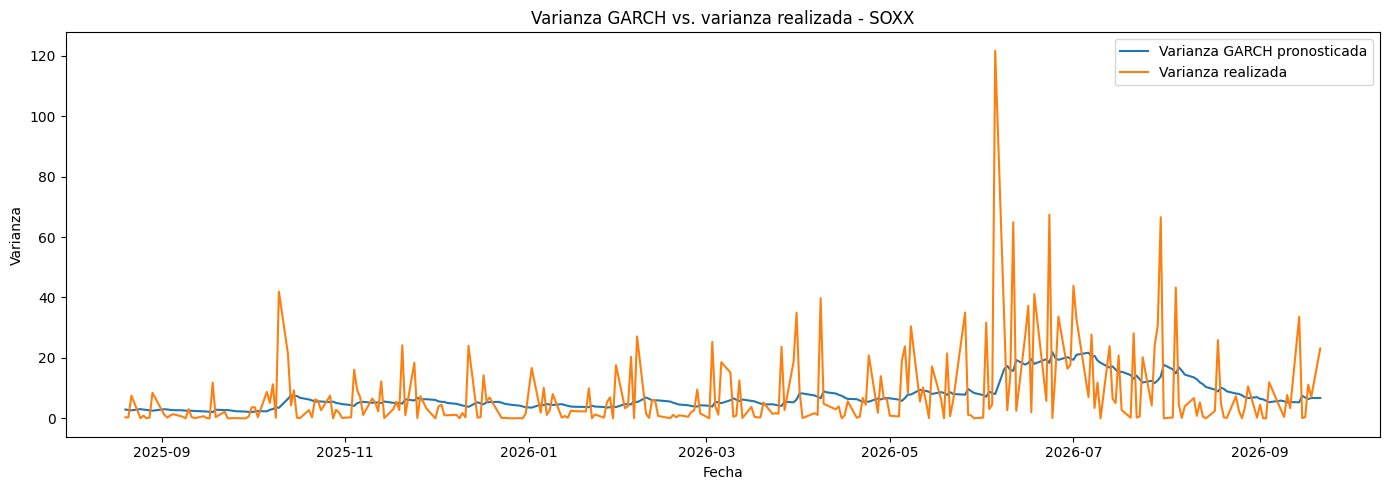

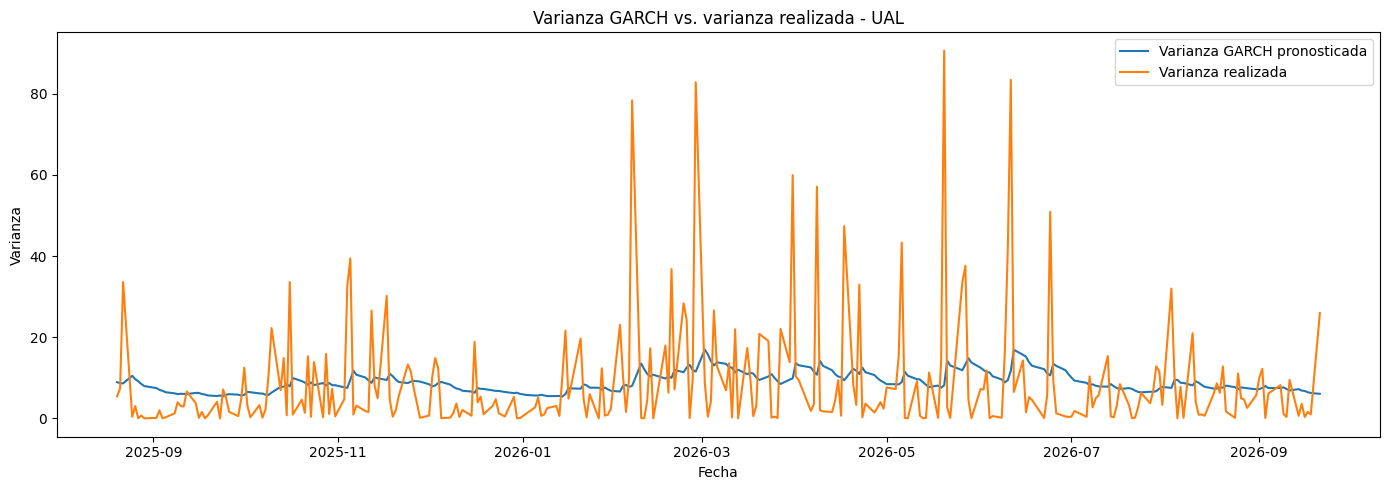

In [77]:
#Visualización de pronósticos vs volatilidad realizada
for ticker in stocks:

    plt.figure(figsize=(14, 5))

    plt.plot(
        varianza_pronosticada.index,
        varianza_pronosticada[ticker],
        label="Varianza GARCH pronosticada"
    )

    plt.plot(
        varianza_realizada.index,
        varianza_realizada[ticker],
        label="Varianza realizada"
    )

    plt.title(
        f"Varianza GARCH vs. varianza realizada - {ticker.upper()}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Varianza")

    plt.legend()

    plt.tight_layout()
    plt.show()

La varianza realizada es muchísimo más irregular que la pronosticada por el modelo GARCH. Por eso posteriormente se usarán métricas agregadas y no juzgaremos el modelo por observaciones individuales.



###Evaluación de pronósticos

Por medio de esta información no es posible declarar cuál modelo "gana", ya que las magnitudes de MAE/RMSE dependen mucho de la escala de volatilidad de cada activo, por lo que comparar directamente COIN contra GOOG, por ejemplo, no sería apropiado.

Lo que realmente interesante es saber qué tan bueno es el pronóstico de cada modelo para su propio activo.

Y posteriormente se evaluará específicamente cómo se comportaron los pronósticos durante los episodios de alta volatilidad que identificaste anteriormente.

In [78]:
#MAE y RMSE
resultados_error = []

#Q-Like
resultados_qlike = []
eps = 1e-10

for ticker in stocks:

    real = varianza_realizada[ticker]

    pred = varianza_pronosticada[ticker]

    mae = mean_absolute_error(real, pred)

    rmse = np.sqrt(mean_squared_error(real, pred))

    qlike = ((real + eps) / (pred + eps) -
             np.log((real + eps) / (pred + eps)) - 1)

    resultados_error.append({
        "Ticker": ticker.upper(),
        "QLIKE": qlike.mean(),
        "MAE": mae,
        "RMSE": rmse
    })



tabla_errores = pd.DataFrame(resultados_error)

tabla_errores

,Ticker,QLIKE,MAE,RMSE
0,COIN,1.443143,22.460918,32.797705
1,GOOG,1.853857,4.503211,9.223387
2,PPTA,1.728848,22.823980,35.484607
3,SOXX,1.456705,7.745759,12.771159
4,UAL,1.328669,8.795191,13.804827


**Conclusiones:**
- UAL
  Es el caso más sólido.

  - GARCH(1,1) seleccionado.
  - α y β significativos.
  - Residuos correctamente diagnosticados.
  - Mejor QLIKE out-of-sample.

- COIN

  Resultado razonablemente sólido.

  - Requirió una especificación más compleja.
  - Persistían algunas dudas sobre la significancia de los componentes.
  - Sin embargo, presenta un QLIKE bastante bueno.

- SOXX

  También muy sólido.

  - GARCH(1,1) parsimonioso.
  - α y β significativos.
  - Residuos validados.
  - QLIKE bajo.

- PPTA

  Modelo funcional pero con debilidades.

  - α no significativa.
  - Mayor dificultad para encontrar una especificación satisfactoria.
  - QLIKE relativamente elevado.

- GOOG

  Caso interesante para discutir.

  - Mejoras importantes en el ajuste dentro de muestra.
  - Pero desempeño predictivo out-of-sample relativamente débil.
  - Es un buen ejemplo de por qué selección del modelo ≠ capacidad predictiva.

###Backtesting

Con el objetivo de evaluar como el modelo captó los episodios de alta volatilidad, ahora se generará una comparativa entre la volatilidad realizada y la volatilidad estimada por el modelo GARCH.

Esto se hace con la finalidad de evaluar que tan acertada es la reacción del modelo, y si en esencia logra capturar los shocks y ajustar su estimación del riesgo para periódos posteriores a un shock.

Para este análisis el criterio para determinar periódos de alta volatilidad será sobre los días durante los cuales la volatilidad superó el percentil 90 en cada activo.

En base a este criterio se seleccionaron episodios específicos en los que se realizará un comparación entre la volatilidad realizada y la volatilidad estimada por el modelo.

In [79]:
#Umbrales de alta volatilidad
umbrales_hv = {}

for ticker in stocks:

    umbral = (
        train_data[ticker].abs()
        .quantile(0.90)
    )

    umbrales_hv[ticker] = umbral

umbrales_hv

{'coin': np.float64(0.08484270054910431),
 'goog': np.float64(0.0294165893268323),
 'ppta': np.float64(0.06602110109779398),
 'soxx': np.float64(0.035900404064678815),
 'ual': np.float64(0.045604839440106994)}

In [80]:
#Identificar días de alta volatilidad
dias_hv = {}

for ticker in stocks:

    umbral = umbrales_hv[ticker]

    dias_hv[ticker] = (test_data[ticker].abs() > umbral)

#Identificar episodios de extrema volatilidad
for ticker in stocks:

    print(ticker,"Días HV:",dias_hv[ticker].sum())

coin Días HV: 15
goog Días HV: 30
ppta Días HV: 44
soxx Días HV: 53
ual Días HV: 32


Al contabilizar los días que superan el umbral de alta volatilidad, se muestra como SOXX y PPTA son los dos activos, que más tiempo se mantuvieron en regimen de alta volatilidad (53 y 44 respectivamente), demostrando que dichos activos no solo destacan por tener una volatilidad histórica alta, sino por la persistencia de sus shocks.

UAL y GOOG mantuvieron un duración de 32 y 30 días respectivamente, mientras que COIN fue el activo que permaneció menos días en regimen de alta volatilidad.

Este último caso es curioso, ya que según la desviación estándar histórica de COIN (5.31%), dicho activo fue el más volátil entre los cinco. Sin embargo, fue el que menos días se mantuvo en el regimen establecido.

In [81]:
#Comparación de GARCH contra volatilidad realizada
resultados_hv = []

for ticker in stocks:

    mask = dias_hv[ticker]

    real = varianza_realizada.loc[mask, ticker]

    pred = varianza_pronosticada.loc[mask, ticker]

    mae = np.mean(np.abs(real - pred))

    rmse = np.sqrt(
        np.mean((real - pred) ** 2)
    )

    eps = 1e-10

    qlike = np.mean(
        (real + eps) / (pred + eps)
        - np.log(
            (real + eps) / (pred + eps)
        )
        - 1
    )

    resultados_hv.append({
        "Ticker": ticker,
        "N_dias_HV": len(real),
        "MAE": mae,
        "RMSE": rmse,
        "QLIKE": qlike
    })

evaluacion_hv = pd.DataFrame(resultados_hv)

evaluacion_hv

,Ticker,N_dias_HV,MAE,RMSE,QLIKE
0,coin,15,101.694476,110.921032,2.578943
1,goog,30,18.134249,26.421845,3.406445
2,ppta,44,60.024187,78.957198,1.570928
3,soxx,53,19.653509,26.029420,1.534328
4,ual,32,29.984934,35.673045,1.900154


Por medio de esta tabla es posible comparar el desempeño normal del modelo con su comportamiento específicamente durante episodios extremos.

Durante los periódos de alta volatilidad los shocks hicieron más difícil el mantener precisión en las estimaciones del modelo GARCH, cosa que se demuestra en la magnitud de los errores en comparación a los errores promedio vistos previamente.

Si comparamos el valor de Q-Like del desempeño global del modelo y el Q-Like en periódos de alta volatilidad se logra apreciar como se ve afectada la precisión de las estimaciones ante eventos repentinos que elevan la volatilidad de los rendimientos.

La evaluación fuera de muestra mostró que la capacidad predictiva de los modelos GARCH varía entre activos y depende de las condiciones del mercado. SOXX presentó el comportamiento más robusto, manteniendo un desempeño similar durante periodos de alta volatilidad. PPTA, a pesar de las limitaciones identificadas en la significancia de sus parámetros, mostró un desempeño relativamente favorable durante episodios de elevada volatilidad.

En contraste, COIN y especialmente GOOG presentaron un deterioro considerable de su capacidad predictiva ante shocks extremos. Estos resultados muestran que un buen ajuste dentro de muestra no garantiza un desempeño equivalente bajo condiciones de estrés y justifican la evaluación del modelo tanto en condiciones normales como durante episodios de alta volatilidad.

UAL muestra un desempeño excelente globalmente, pero con deterioro durante shocks, ya que su valor de Q-Like pasa de 1.329 a 1.900 al presentarse un periodo de volatilidad alta. De igual forma, considerando que ya hay evidencia favorable de sus parámetros y diagnósticos, sigue siendo un modelo bastante sólido.

##VaR

Ahora que los modelos han sido probados tanto de manera global como en episodios extremos, el siguiente paso es convertir los modelos GARCH generados en este proyecto en una herramienta con aplicaciones reales para la gestión de riesgo.

El Valor en Riesgo (VaR) es una métrica estadística utilizada en finanzas para cuantificar la pérdida máxima esperada de una cartera de inversión o activo dentro de un período específico y bajo un nivel de confianza determinado en condiciones normales de mercado.

Para este apartado la idea será construir un VaR dinámico basado en la volatilidad condicional GARCH y posteriormente hacer backtesting.

Por cada día en la serie de tiempo se espera calcular la pérdida máxima esperada para el día siguiente, bajo un determinado nivel de confianza, utilizando únicamente la información disponible hasta ese día.

El valor del VaR se calculará en base a los valores pronosticados en la evaluación del GARCH para estimaciones. Este VaR se comparará de con los datos de la muestra de rendimientos de prueba para evaluar su eficacia.

Como los modelos utilizan media cero, podemos calcular:

$$ VaR_{t+1} = -z_{\alpha}\hat{\sigma}_{t+1} $$

Donde $z_{\alpha}$ es el cuantil de la distribución de los rendimientos.

Para el nivel de confianza se iniciará con un 95%, por lo que α=0.05.
	​
  
Para la distribución se utilizará una distrbución normal, por lo que
$z_{0.05}≈−1.645$.

Entonces $VaR_{95}=1.645\hat{\sigma}_{t+1}$




###Cálculo del VaR

In [82]:
#Cálculo del VaR
confianza = 0.95

z = norm.ppf(1 - confianza)

VaR_95 = -z * pronosticos_vol_df

VaR_95.head()

,coin,goog,ppta,soxx,ual
Fecha,,,,,
2025-08-20,6.907478,2.969449,8.095063,2.807806,4.911611
2025-08-21,7.636148,2.954110,8.037078,2.740802,4.844889
2025-08-22,7.290340,2.926756,8.024316,2.677942,4.825595
2025-08-25,7.102166,2.983576,7.869935,2.879207,5.324562
2025-08-26,7.883919,2.969362,7.749375,2.797630,5.110618


Cada valor que se muestra en la tabla representa el porcentaje de pérdida diaria que el modelo considera como límite de riesgo al 95%.

###Tasa de excedencias

Cuando un rendimiento es menor al máximo valor de pérdida esperado en base al VaR ($-VaR_{t}$), se considera que existe una excedencia.

Este valor ayudará a determinar si efectivamente los rendimientos de la muestra de prueba caen dentro de el nivel esperado por el VaR al 95% de confianza.

Teniendo en cuenta que la muestra utilizada para la evaluación consta de 273 observaciones, y el nivel de confianza de 95%, se espera que como máximo se detecten cerca de 14 excendencias ($273(0.05)≈13.65$).


In [83]:
rendimientos_test_pct = rendimientos_test * 100

#Número de excedencias
excedencias_95 = {}
for ticker in stocks:
    excedencias_95[ticker] = (rendimientos_test_pct[ticker] < -VaR_95[ticker])

# Tasa de excedencias
tasa_excedencias = pd.Series({ticker: serie.mean() for ticker,
                              serie in excedencias_95.items()})

tasa_excedencias_pct = (tasa_excedencias * 100)

tasa_excedencias_pct

,0
coin,2.930403
goog,2.564103
ppta,4.029304
soxx,5.860806
ual,2.930403


Según los resultados, los modelos GARCH logran pronosticar el VaR a un 95% de confianza en cuatro de cinco series de tiempo financieras.

El caso de SOXX es el único en el cual, las pérdidas han llegado a superar el VaR en más de 14 ocasiones. Con una tasa de excedencia del 5.86%, el 0.86% de los casos de excedencias no están contemplados por el VaR al nivel de confianza establecido.

###Backtesting

####Tasa de excedencia

In [84]:
#Backtest del VaR durante periódo de prueba
excedencias_sum = pd.Series({ticker: serie.sum() for ticker, serie in excedencias_95.items()})
observaciones_count = pd.Series({ticker: len(serie) for ticker, serie in excedencias_95.items()})

backtest_var = pd.DataFrame({
    "Excedencias": excedencias_sum,
    "Observaciones": observaciones_count,
    "Tasa_excedencias": tasa_excedencias * 100,
    "Tasa_esperada": 5.0
})

backtest_var

,Excedencias,Observaciones,Tasa_excedencias,Tasa_esperada
coin,8,273,2.930403,5.0
goog,7,273,2.564103,5.0
ppta,11,273,4.029304,5.0
soxx,16,273,5.860806,5.0
ual,8,273,2.930403,5.0


Aunque según los resultados la mayoría de los modelos pronostican el VaR dentro del nivel de confianza esperado y con algo de margen, no podemos concluir que exista sobreprotección

Podríamos sospechar que el VaR está siendo demasiado amplio en el caso de GOOG, pero con solamente 273 observaciones, una diferencia de ese tamaño podría perfectamente ser compatible con un VaR correctamente calibrado.

Aún con los datos anteriores, no se puede declarar que el cálculo del VaR está validado, ya que la tasa de excedencias no demuestra por sí misma que el modelo sea correcto, ya que el VaR tiene dos propiedades que se deben evaluar.

La primera es la cobertura incondicional, la cual evalúa si la cantidad de excedencias es consistente con el nivel de confianza (este dato ya esta calculado).

La segunda propiedad es la independencia, la cual evalúa si las excedencias aparecen aproximadamente de manera independiente. Esto es importantísimo en mercados financieros, debido a que se debe de considerar si las pérdidas extremas están agrupadas.

####Kupiec Proportion of Failures test

Como complemento de la tasa de excedencias, se aplicará el Kupiec Proportion of Failures test, el cual evalúa si la proporción observada de excedencias es igual al nivel de significancia establecido.

- $H_{0}$: La proporción observada de excedencias es consistente con el nivel de VaR especificado.
- $H_{1}$: La proporción observada de excedencias no es consistente con el nivel de VaR especificado.
- Nivel de significancia: 0.05.

In [85]:
resultados_kupiec = []

alpha = 0.05

for ticker in stocks:

    x = excedencias_95[ticker].sum()
    T = len(excedencias_95[ticker])

    p_hat = x / T

    #Log-verosimilitud bajo H0
    logL_null = ((T - x) * np.log(1 - alpha)+ x * np.log(alpha)
)

    #Log-verosimilitud bajo H1
    logL_alt = ((T - x) * np.log(1 - p_hat)+ x * np.log(p_hat))

    LR = -2 * (logL_null - logL_alt)

    p_value = 1 - chi2.cdf(LR, df=1)

    resultados_kupiec.append({
        "Ticker": ticker.upper(),
        "Excedencias": x,
        "Observaciones": T,
        "Tasa_observada": p_hat,
        "LR_Kupiec": LR,
        "p_value": p_value
    })

kupiec = pd.DataFrame(resultados_kupiec)

kupiec

,Ticker,Excedencias,Observaciones,Tasa_observada,LR_Kupiec,p_value
0,COIN,8,273,0.029304,2.873435,0.090052
1,GOOG,7,273,0.025641,4.119463,0.042393
2,PPTA,11,273,0.040293,0.578412,0.446935
3,SOXX,16,273,0.058608,0.404533,0.524758
4,UAL,8,273,0.029304,2.873435,0.090052


Con esta métrica a la mano los resultados cambian algo, y es que SOXX previamente mostró una tasa de excedencias fuera del nivel de confianza de 95%, esta vez muestra que la proporción observada de excedencias es consistente dicho nivel especificado.

Esta vez el modelo que muestra inconsistencia es el modelo de GOOG, ya que aunque la tasa observada aparece dentro de los parámetros establecidos, el valor p de la prueba arroja otra conclusión, declarando que existe evidencia estadística de que la proporción de frecuencia de las excedencias no es la esperada.

Esta prueba demuestra que aunque la tasa de excedencias aplicada a la pequeña muestra de 273 haya arrojado resultados que validen o invaliden un modelo, no se debe interpretar una tasa como evidencia automática de que el VaR esta validado.

####Christoffersen test

El Christoffersen test verifica si las excepciones (cuando la pérdida real supera el VaR) ocurren de manera independiente a lo largo del tiempo, detectando así el fenómeno de agrupamiento de volatilidad (clustering), donde un fallo tiende a ser seguido por otro en días consecutivos.

Con esta prueba esencial finalmente se obtendrá un backtesting formal del VaR, no simplemente una comparación visual de pérdidas contra el límite, ya que si un modelo pasa Kupiec pero falla Christoffersen, entonces existe evidencia de que el número total de excepciones parece correcto, pero el modelo no está reaccionando correctamente a los cambios de régimen de volatilidad.

- $H_{0}$: Las excedencias ocurren de forma independiente y con la frecuencia esperada.
- $H_{1}$: Las excedencias presentan dependencia y se presentan en una frecuencia superior a la esperada.
- Nivel de significancia: 0.05.

In [86]:
#Contando el tipo de transiciones
resultados_christoffersen = []

for ticker in stocks:

    serie = excedencias_95[ticker].astype(int).values

    n00 = 0
    n01 = 0
    n10 = 0
    n11 = 0

    for i in range(1, len(serie)):

        if serie[i-1] == 0 and serie[i] == 0:
            n00 += 1

        elif serie[i-1] == 0 and serie[i] == 1:
            n01 += 1

        elif serie[i-1] == 1 and serie[i] == 0:
            n10 += 1

        elif serie[i-1] == 1 and serie[i] == 1:
            n11 += 1

    resultados_christoffersen.append({
        "Ticker": ticker.upper(),
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11
    })

transiciones = pd.DataFrame(resultados_christoffersen)

transiciones

,Ticker,n00,n01,n10,n11
0,COIN,256,8,8,0
1,GOOG,258,7,7,0
2,PPTA,250,11,11,0
3,SOXX,240,16,16,0
4,UAL,256,8,8,0


In [87]:
#Probabilidad de una excedencia después de un día que no fue excedencia
transiciones["pi_0"] = (transiciones["n01"] /
 (transiciones["n00"] + transiciones["n01"]))
#Probabilidad de una excedencia después de otra excedencia.
transiciones["pi_1"] = (transiciones["n11"] /
 (transiciones["n10"] + transiciones["n11"]))

transiciones

,Ticker,n00,n01,n10,n11,pi_0,pi_1
0,COIN,256,8,8,0,0.030303,0.0
1,GOOG,258,7,7,0,0.026415,0.0
2,PPTA,250,11,11,0,0.042146,0.0
3,SOXX,240,16,16,0,0.062500,0.0
4,UAL,256,8,8,0,0.030303,0.0


In [88]:
#Prueba Christoffersen
resultados = []

for _, row in transiciones.iterrows():

    n00 = row["n00"]
    n01 = row["n01"]
    n10 = row["n10"]
    n11 = row["n11"]

    pi0 = row["pi_0"]
    pi1 = row["pi_1"]

    #Probabilidad global de excedencia
    pi = ((n01 + n11) /(n00 + n01 + n10 + n11))

    #Evitar log(0)
    eps = 1e-10

    pi = np.clip(pi, eps, 1-eps)
    pi0 = np.clip(pi0, eps, 1-eps)
    pi1 = np.clip(pi1, eps, 1-eps)

    #Log-verosimilitud bajo independencia
    logL0 = ((n00 + n10) * np.log(1 - pi) + (n01 + n11) * np.log(pi))

    #Log-verosimilitud bajo dependencia
    logL1 = (n00 * np.log(1 - pi0) + n01 * np.log(pi0)
     + n10 * np.log(1 - pi1) + n11 * np.log(pi1))

    LR_ind = -2 * (logL0 - logL1)

    p_value = 1 - chi2.cdf(LR_ind,df=1)

    resultados.append({
        "Ticker": row["Ticker"],
        "pi_0": pi0,
        "pi_1": pi1,
        "LR_Independencia": LR_ind,
        "p_value": p_value
    })

christoffersen = pd.DataFrame(resultados)

christoffersen

,Ticker,pi_0,pi_1,LR_Independencia,p_value
0,COIN,0.030303,1.000000e-10,0.484923,0.486201
1,GOOG,0.026415,1.000000e-10,0.369854,0.543084
2,PPTA,0.042146,1.000000e-10,0.927478,0.335519
3,SOXX,0.062500,1.000000e-10,2.001304,0.157164
4,UAL,0.030303,1.000000e-10,0.484923,0.486201


Según los resultados de la prueba no se rechaza independencia para las excedencias de pérdidas y de igual forma están dentro de la frecuencia esperada según el nivel de confianza al 95% establecido.

####Prueba conjunta

Una vez teniendo los resultados de ambas pruebas se puede llevar a cabo una prueba conjunta, laa consiste en combinar Christoffersen con Kupiec de la siguiente forma:

$$LR_{CC}​=LR_{POF}​+LR_{IND}$$

donde:

- $LR_{POF}$ = Kupiec;

- $LR_{IND}$ = Christoffersen.

- Y sigue una distribución: $χ^2(2)$


La prueba conjunta cálcula un nuevo valor p condicional, el cual se utiliza para evaluar:
- $H_{0}$: El VaR pasa conjuntamente las pruebas de cobertura e independencia.
- $H_{1}$: El VaR presenta problemas de especificación.

In [89]:
#Prueba conjunta
resultado_final = kupiec.merge(christoffersen,on="Ticker")

resultado_final["LR_Christoffersen"] = (resultado_final["LR_Independencia"])

resultado_final["LR_Condicional"] = (resultado_final["LR_Kupiec"]
    + resultado_final["LR_Christoffersen"])

resultado_final["p_value_condicional"] = (1 - chi2.cdf(
        resultado_final["LR_Condicional"],df=2))

resultado_final

,Ticker,Excedencias,Observaciones,Tasa_observada,LR_Kupiec,p_value_x,pi_0,pi_1,LR_Independencia,p_value_y,LR_Christoffersen,LR_Condicional,p_value_condicional
0,COIN,8,273,0.029304,2.873435,0.090052,0.030303,1.000000e-10,0.484923,0.486201,0.484923,3.358357,0.186527
1,GOOG,7,273,0.025641,4.119463,0.042393,0.026415,1.000000e-10,0.369854,0.543084,0.369854,4.489317,0.105964
2,PPTA,11,273,0.040293,0.578412,0.446935,0.042146,1.000000e-10,0.927478,0.335519,0.927478,1.505890,0.470978
3,SOXX,16,273,0.058608,0.404533,0.524758,0.062500,1.000000e-10,2.001304,0.157164,2.001304,2.405837,0.300316
4,UAL,8,273,0.029304,2.873435,0.090052,0.030303,1.000000e-10,0.484923,0.486201,0.484923,3.358357,0.186527


Al aplicar las dos pruebas en conjunto para de esta forma evaluar la proporción de la frecuencia de valores excedentes al VaR calculado y la independencia de dichos valores, se han encontrado resultados favorables que no rechazan la hipótesis, y por ende encuentran a los cinco modelos complacientes en tema de cobertura e independencia.

###Conclusiones

| Criterio                                 | COIN                       | GOOG                   | PPTA           | SOXX                            | UAL            |
| ---------------------------------------- | -------------------------- | ---------------------- | -------------- | ------------------------------- | -------------- |
| **Modelo seleccionado**                  | GARCH(2,1)                 | GARCH(1,1)            | GARCH(1,1)     | GARCH(1,1)                      | GARCH(1,1)     |
| **Parámetros plenamente significativos** | ⚠️ No                      | ⚠️ No                  | ⚠️ No          | ✅ Sí                            | ✅ Sí           |
| **Autocorrelación en residuos**          | ✅ No detectada             | ✅ No detectada         | ✅ No detectada | ✅ No detectada                  | ✅ No detectada |
| **ARCH residual**                        | ✅ No detectado             | ✅ No detectado         | ✅ No detectado | ⚠️ Débil/no significativo al 5% | ✅ No detectado |
| **Desempeño OOS**                        | ⚠️                         | ❌                      | ⚠️             | ✅                               | ✅              |
| **Alta volatilidad**                     | ❌                          | ❌                      | ✅              | ✅                               | ⚠️             |
| **Kupiec 95%**                           | ✅                          | ❌                      | ✅              | ✅                               | ✅              |
| **Independencia**                        | ✅                          | ✅                      | ✅              | ✅                               | ✅              |
| **Christoffersen 95%**                   | ✅                          | ✅                      | ✅              | ✅                               | ✅              |
| **Evaluación final**                     | Aceptable con limitaciones | Aceptable con reservas | Aceptable      | **Sólido**                      | **Sólido**     |


En el proyecto se demuestra que los rendimientos de los cinco activos presentan características compatibles con la modelación GARCH, tales como estacionariedad en los rendimientos, ausencia de tendencia persistente y presencia de dependencia en la varianza, manifestada mediante clustering de volatilidad y efectos ARCH.

La incorporación de GARCH permitió pasar de una medida retrospectiva de volatilidad (volatilidad móvil) a una estimación condicional, dependiente de la información disponible hasta cada momento.

La evaluación fuera de muestra mostró que la capacidad predictiva no es homogénea entre activos. SOXX y UAL presentaron los resultados más consistentes, mientras que COIN y GOOG mostraron mayores dificultades para representar episodios extremos. PPTA presentó un comportamiento particular, ya que a pesar de las limitaciones en la significancia de sus parámetros, produjo resultados razonables en la predicción de riesgo.

Finalmente, el backtesting del VaR al 95% mostró que ninguno de los cinco modelos presentó evidencia suficiente para rechazar conjuntamente las condiciones de cobertura e independencia. Esto proporciona evidencia favorable sobre su utilidad para la medición del riesgo, aunque con distintos grados de confianza según el activo.